In [4]:
import sys
import os
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. Dynamic Path Setup for Repositories 
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))

sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

# 2. Import Visualization Libraries (No Agg backend for Jupyter)
import matplotlib.pyplot as plt
import shap
import shap_rtl
from shap_rtl.plots import (
    waterfall, bar, beeswarm, summary_plot, heatmap, decision_plot, scatter, dependence_plot, force_plot
)
from shap_rtl.rtl_utils import _find_rtl_font, add_rtl_title

# 3. Handle Matplotlib Urdu Font Registration
plt.rcdefaults()
font_path, font_name = _find_rtl_font()
print(f"Using font : {font_name}")
print(f"Font path  : {font_path}")
print(f"shap_rtl   : v{shap_rtl.__version__}")

from matplotlib import font_manager
try:
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
    print(f"Successfully registered font name: {prop.get_name()}")
except Exception as e:
    print(f"Font injection step skipped/failed: {e}")

plt.rcParams['axes.unicode_minus'] = False

Using font : NotoNastaliqUrdu-Regular
Font path  : c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoNastaliqUrdu-Regular.ttf
shap_rtl   : v1.1.0
Successfully registered font name: Noto Nastaliq Urdu


In [5]:
# 3. Handle Matplotlib Urdu Font Registration with English Fallback
plt.rcdefaults()
font_path, font_name = _find_rtl_font()
print(f"Using font : {font_name}")
print(f"Font path  : {font_path}")
print(f"shap_rtl   : v{shap_rtl.__version__}")

from matplotlib import font_manager
try:
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    
    # CRITICAL FIX: Set Urdu font first, then fallback to standard fonts for English text
    plt.rcParams['font.family'] = [prop.get_name(), 'DejaVu Sans', 'Arial', 'sans-serif']
    print(f"Successfully registered font hierarchy starting with: {prop.get_name()}")
except Exception as e:
    print(f"Font injection step skipped/failed: {e}")

plt.rcParams['axes.unicode_minus'] = False

Using font : NotoNastaliqUrdu-Regular
Font path  : c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoNastaliqUrdu-Regular.ttf
shap_rtl   : v1.1.0
Successfully registered font hierarchy starting with: Noto Nastaliq Urdu


In [3]:
# 4. Load Data & Train Model
file_name = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx"

if not os.path.exists(file_name):
    raise FileNotFoundError(f"❌ Excel file '{file_name}' not found! Please check path configuration.")

print(" -> Loading Dataset...")
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print(" -> Generating Vocabulary & Tokenizing Feature Array...")
vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()

print(" -> Training Logistic Regression Classifier Model...")
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X, labels)

 -> Loading Dataset...
 -> Generating Vocabulary & Tokenizing Feature Array...
 -> Training Logistic Regression Classifier Model...


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [6]:
# 5. SHAP Explainer Setup & Filter Out Absent Features
print(" -> Initializing Linear SHAP Explainer Engine...")
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)

# Target sentence for analysis
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"
instance_vectorized = vectorizer.transform([user_tweet]).toarray()[0]
all_feature_names = list(vectorizer.get_feature_names_out())

print(" -> Running SHAP valuations across tokens...")
shap_values_raw = explainer(instance_vectorized.reshape(1, -1))

# Extract indices where the word is actually in the text
present_indices = np.where(instance_vectorized > 0)[0]

# Filter arrays down strictly to the tokens present in your user_tweet
filtered_values = shap_values_raw.values[0][present_indices]
filtered_data = instance_vectorized[present_indices]
filtered_names = [all_feature_names[idx] for idx in present_indices]

# Rebuild single-row Explanation wrapper containing ONLY the active present tokens
formatted_explanation = shap.Explanation(
    values=filtered_values,
    base_values=shap_values_raw.base_values[0],
    data=filtered_data,
    feature_names=filtered_names
)

# For multi-row dependent plots (Summary, Heatmap, Decision), build an active 2D slice
multi_instance_raw = X[:30] 
multi_shap_raw = explainer(multi_instance_raw)

multi_explanation_filtered = shap.Explanation(
    values=multi_shap_raw.values[:, present_indices],
    base_values=multi_shap_raw.base_values,
    data=multi_instance_raw[:, present_indices],
    feature_names=filtered_names
)

num_active_features = len(filtered_names)
SAVE_TARGET_DIR = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests"
os.makedirs(SAVE_TARGET_DIR, exist_ok=True)

# Helper function modified to show output directly inline inside Jupyter
def _save_and_show_plot(filename, title_text):
    try:
        ax = plt.gca()
        for tick in ax.get_xticklabels():
            tick.set_fontfamily("DejaVu Sans")
    except Exception:
        pass

    add_rtl_title(title_text)
    plt.tight_layout()
    out_path = os.path.join(SAVE_TARGET_DIR, filename)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out_path}")
    plt.show() # Forces inline visualization inside Jupyter windows

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


 -> Initializing Linear SHAP Explainer Engine...
 -> Running SHAP valuations across tokens...


In [7]:
%matplotlib inline

Saved -> C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests\shap_1_waterfall.png


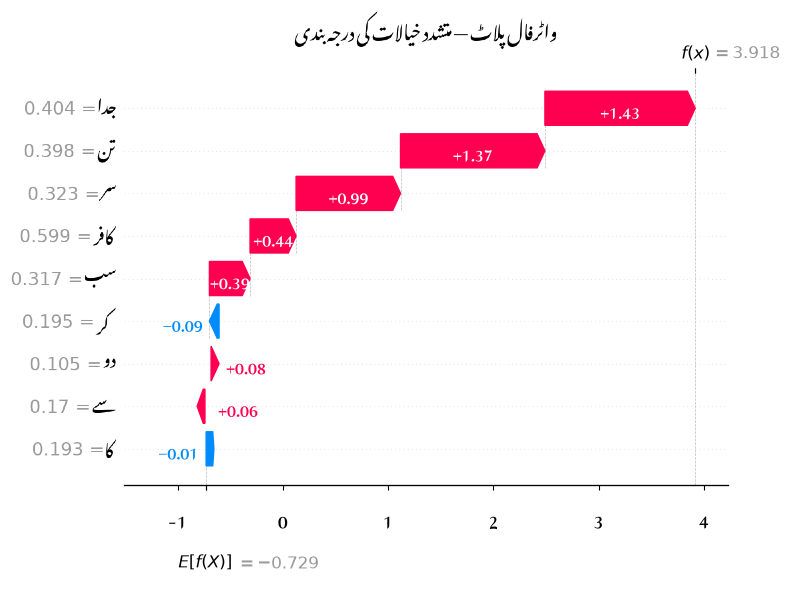

In [8]:
plt.figure(figsize=(10, 6))
waterfall(formatted_explanation, max_display=num_active_features, show=False)
_save_and_show_plot("shap_1_waterfall.png", "واٹرفال پلاٹ — متشدد خیالات کی درجہ بندی")

Saved -> C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests\shap_2_bar.png


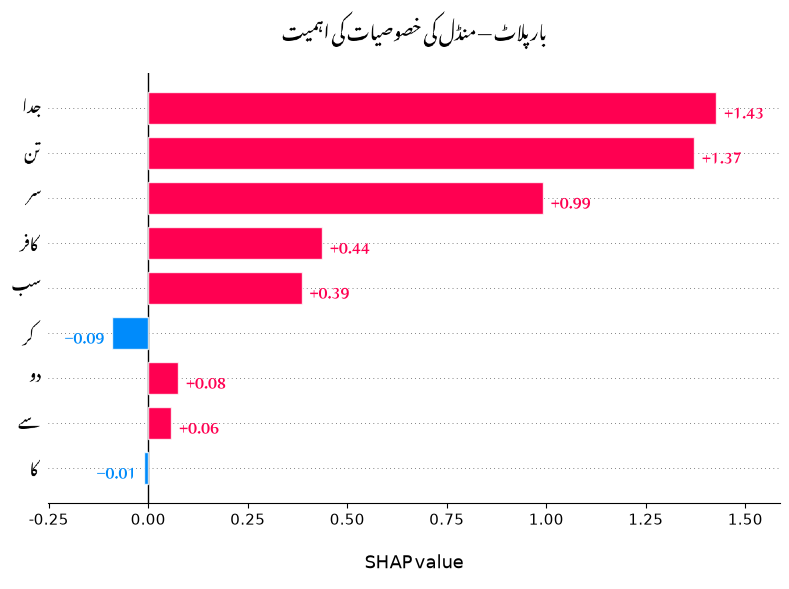

In [9]:
plt.figure(figsize=(10, 6))
bar(formatted_explanation, max_display=num_active_features, show=False)
_save_and_show_plot("shap_2_bar.png", "بار پلاٹ — منڈل کی خصوصیات کی اہمیت")

Saved -> C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests\shap_3_beeswarm.png


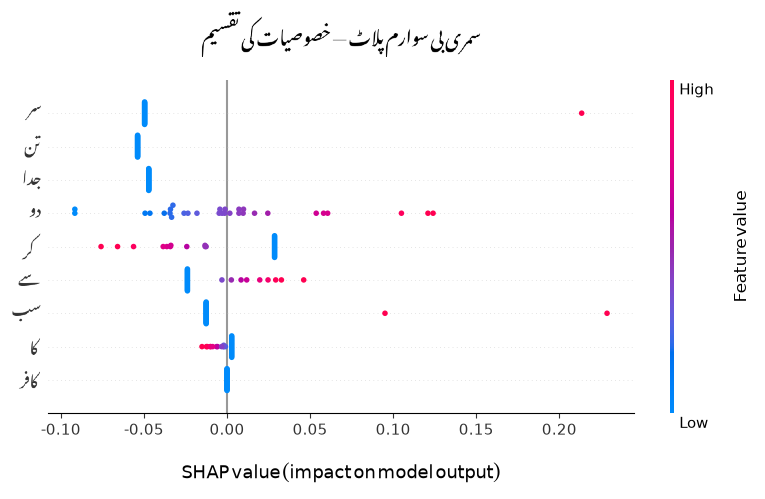

In [8]:
plt.figure(figsize=(10, 6))
beeswarm(multi_explanation_filtered, max_display=num_active_features, show=False)
_save_and_show_plot("shap_3_beeswarm.png", "سمری بی سوارم پلاٹ — خصوصیات کی تقسیم")

Saved -> C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests\shap_4_summary.png


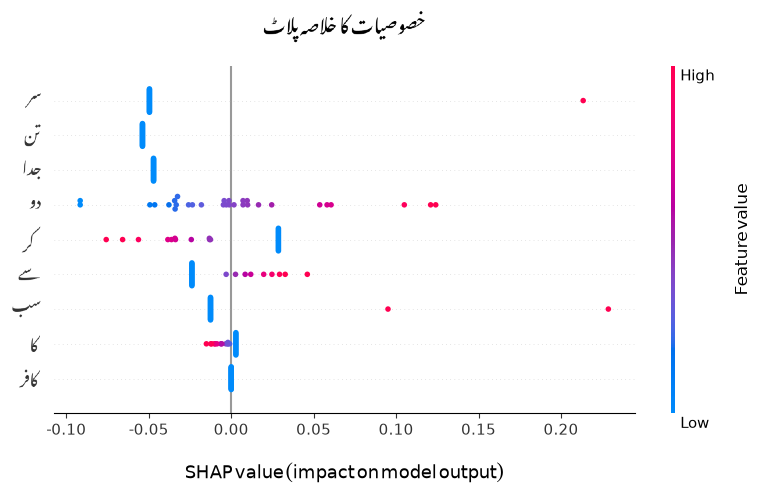

In [9]:
plt.figure(figsize=(10, 6))
summary_plot(multi_explanation_filtered.values, features=multi_explanation_filtered.data, 
             feature_names=filtered_names, max_display=num_active_features, show=False)
_save_and_show_plot("shap_4_summary.png", "خصوصیات کا خلاصہ پلاٹ")

Saved -> C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests\shap_5_heatmap.png


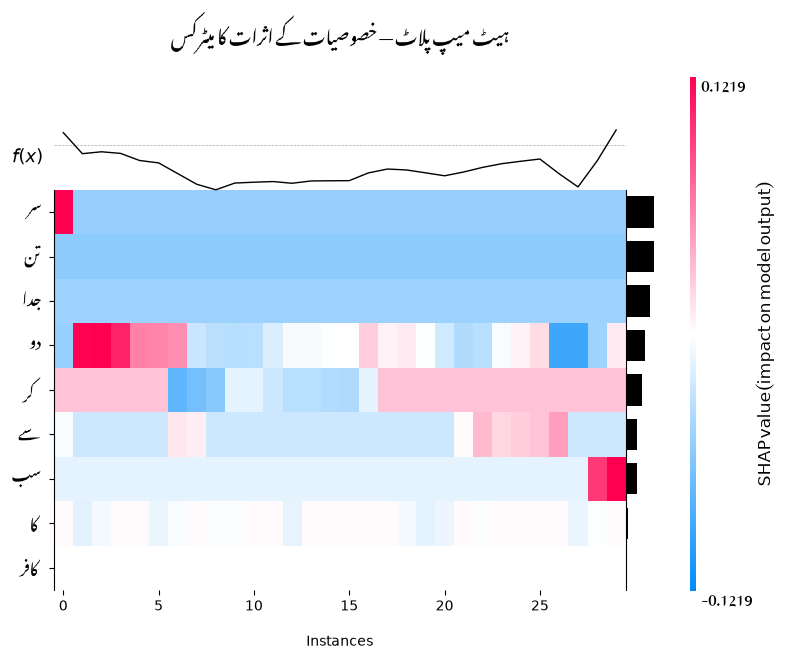

In [10]:
plt.figure(figsize=(10, 6))
heatmap(multi_explanation_filtered, max_display=num_active_features, show=False)
_save_and_show_plot("shap_5_heatmap.png", "ہیٹ میپ پلاٹ — خصوصیات کے اثرات کا میٹرکس")

Saved -> C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests\shap_6_decision.png


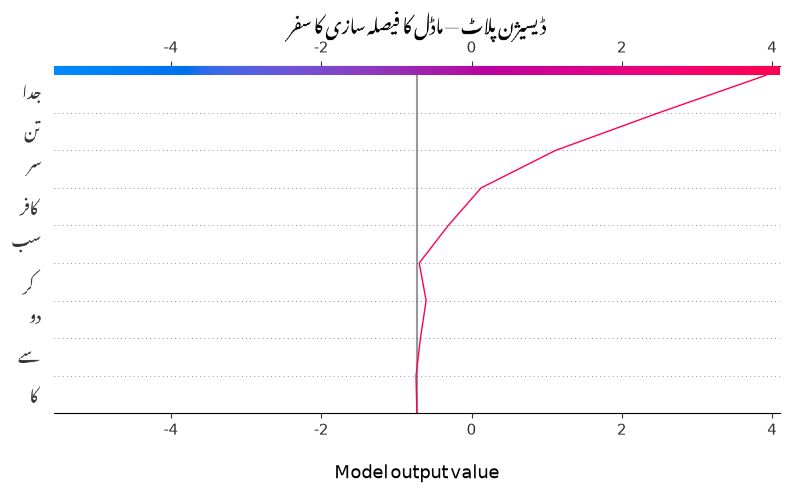

In [11]:
plt.figure(figsize=(10, 6))
decision_plot(
    float(formatted_explanation.base_values), 
    formatted_explanation.values, 
    feature_names=filtered_names,
    show=False
)
_save_and_show_plot("shap_6_decision.png", "ڈیسیژن پلاٹ — ماڈل کا فیصلہ سازی کا سفر")

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


 -> Initializing Linear SHAP Explainer Engine...
 -> Running global sample SHAP valuations...
 -> Testing suite configured with 10 highly active features across 50 samples!
Saved -> C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests\shap_7_scatter.png


<Figure size 1000x600 with 0 Axes>

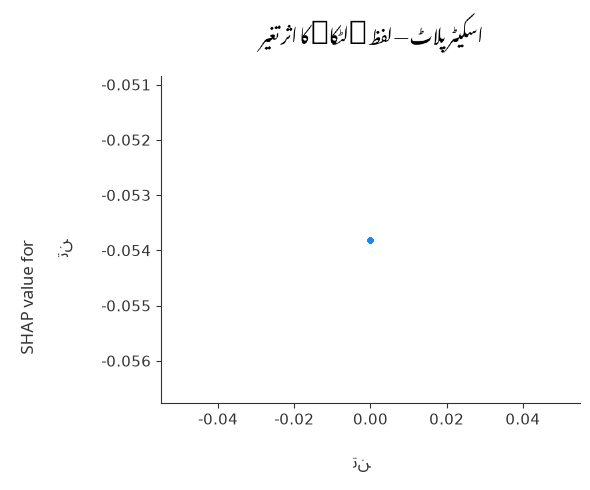

In [12]:
# Updated Cell 11: Scatter Plot with Absolute Font Path
plt.figure(figsize=(10, 6))

# Absolute path configuration to map exactly to your project directory
absolute_font_path = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"

# Explicitly forwarding the font_path parameter to override the package default
scatter(
    multi_explanation_filtered[:, 0], 
    hist=False, 
    show=False, 
    font_path=absolute_font_path
) # 5. SHAP Explainer Setup & Extract High-Impact Global Features for Testing
print(" -> Initializing Linear SHAP Explainer Engine...")
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)

# Target sentence for single-instance validation
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"
instance_vectorized = vectorizer.transform([user_tweet]).toarray()[0]
all_feature_names = list(vectorizer.get_feature_names_out())

print(" -> Running global sample SHAP valuations...")
# Extract a multi-instance block (e.g., 50 instances) to get actual data variance
multi_instance_raw = X[:50] 
multi_shap_raw = explainer(multi_instance_raw)

# --- NEW TESTING TRICK: Find the top 10 features with the highest absolute SHAP impact globally ---
mean_abs_shap = np.mean(np.abs(multi_shap_raw.values), axis=0)
top_global_indices = np.argsort(mean_abs_shap)[-10:][::-1]  # Get top 10 highest-impact features

# Filter down your single-row validation slice using these high-impact features
shap_values_raw = explainer(instance_vectorized.reshape(1, -1))
filtered_values = shap_values_raw.values[0][top_global_indices]
filtered_data = instance_vectorized[top_global_indices]
filtered_names = [all_feature_names[idx] for idx in top_global_indices]

# Rebuild single-row Explanation wrapper
formatted_explanation = shap.Explanation(
    values=filtered_values,
    base_values=shap_values_raw.base_values[0],
    data=filtered_data,
    feature_names=filtered_names
)

# Rebuild dense 2D slice containing many samples for the distribution plots
multi_explanation_filtered = shap.Explanation(
    values=multi_shap_raw.values[:, top_global_indices],
    base_values=multi_shap_raw.base_values,
    data=multi_instance_raw[:, top_global_indices],
    feature_names=filtered_names
)

num_active_features = len(filtered_names)
print(f" -> Testing suite configured with {num_active_features} highly active features across {multi_instance_raw.shape[0]} samples!")

SAVE_TARGET_DIR = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests"
os.makedirs(SAVE_TARGET_DIR, exist_ok=True)

def _save_and_show_plot(filename, title_text):
    try:
        ax = plt.gca()
        for tick in ax.get_xticklabels():
            tick.set_fontfamily("DejaVu Sans")
    except Exception:
        pass
    add_rtl_title(title_text)
    plt.tight_layout()
    out_path = os.path.join(SAVE_TARGET_DIR, filename)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out_path}")
    
    plt.show()

_save_and_show_plot("shap_7_scatter.png", f"اسکیٹر پلاٹ — لفظ '{filtered_names[0]}' کا اثر تغیر")

In [1]:
%matplotlib inline
import sys
import os
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Dynamic Path Setup for local Repository Testing
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

import shap
import shap_rtl
from shap_rtl.plots import scatter

c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_name = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx"

print(" -> Loading Dataset & Training Model...")
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
all_feature_names = list(vectorizer.get_feature_names_out())

model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

# Explainer engine calculations
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)
multi_instance_raw = X[:50] 
multi_shap_raw = explainer(multi_instance_raw)

# Extract top high-impact active features automatically
mean_abs_shap = np.mean(np.abs(multi_shap_raw.values), axis=0)
top_global_indices = np.argsort(mean_abs_shap)[-10:][::-1]
filtered_names = [all_feature_names[idx] for idx in top_global_indices]

multi_explanation_filtered = shap.Explanation(
    values=multi_shap_raw.values[:, top_global_indices],
    base_values=multi_shap_raw.base_values,
    data=multi_instance_raw[:, top_global_indices],
    feature_names=filtered_names
)

# Set absolute path variables for the suite output properties
ABSOLUTE_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"
SAVE_TARGET_DIR = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests"
os.makedirs(SAVE_TARGET_DIR, exist_ok=True)

 -> Loading Dataset & Training Model...


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


In [3]:
import importlib
import shap_rtl.plots._scatter_rtl
importlib.reload(shap_rtl.plots._scatter_rtl)
from shap_rtl.plots import scatter

<Figure size 1000x600 with 0 Axes>

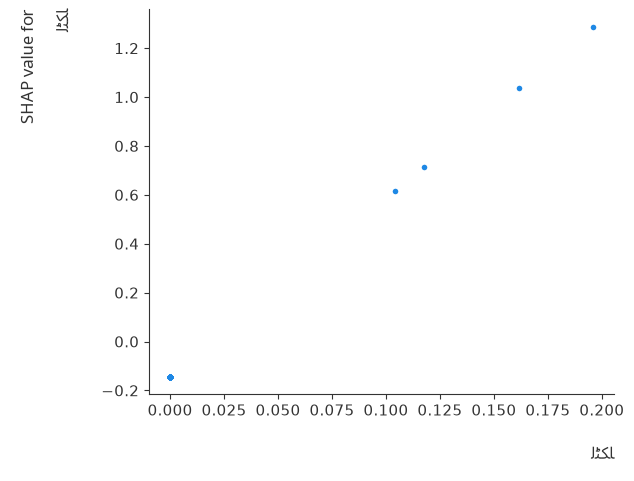

In [7]:
# Zero manual adjustments in the test block
plt.figure(figsize=(10, 6))

scatter(
    multi_explanation_filtered[:, 0], 
    hist=False, 
    show=False, 
    font_path=ABSOLUTE_FONT_PATH
)

# Standard file saving routine without internal visualization overrides
plt.savefig(os.path.join(SAVE_TARGET_DIR, "shap_7_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

In [19]:
%load_ext autoreload
%autoreload 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
%reload_ext autoreload

 -> Loading Dataset & Training Model...


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


<Figure size 1000x600 with 0 Axes>

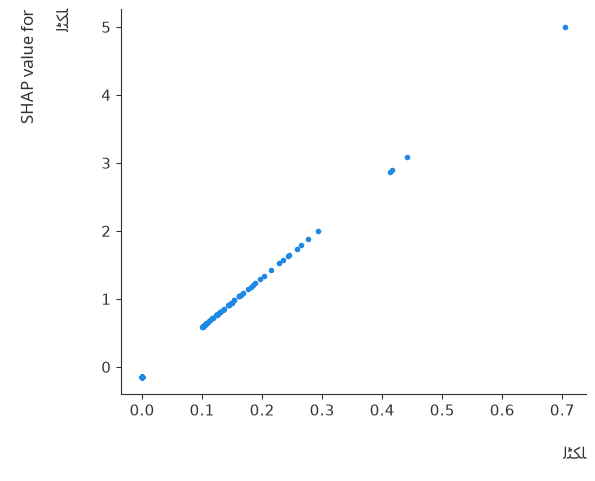

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

file_name = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx"

print(" -> Loading Dataset & Training Model...")
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
all_feature_names = list(vectorizer.get_feature_names_out())

model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

# Explainer engine calculations
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)
multi_instance_raw = X[:500]

multi_shap_raw = explainer(multi_instance_raw)

# Extract top high-impact active features automatically
mean_abs_shap = np.mean(np.abs(multi_shap_raw.values), axis=0)
top_global_indices = np.argsort(mean_abs_shap)[-10:][::-1]
filtered_names = [all_feature_names[idx] for idx in top_global_indices]

multi_explanation_filtered = shap.Explanation(
    values=multi_shap_raw.values[:, top_global_indices],
    base_values=multi_shap_raw.base_values,
    data=multi_instance_raw[:, top_global_indices],
    feature_names=filtered_names
)

# Set absolute path variables for the suite output properties
ABSOLUTE_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"
SAVE_TARGET_DIR = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests"
os.makedirs(SAVE_TARGET_DIR, exist_ok=True)

# Zero manual adjustments in the test block
plt.figure(figsize=(10, 6))

scatter(
    multi_explanation_filtered[:, 0],
    hist=False,
    show=False,
    font_path=ABSOLUTE_FONT_PATH
)

# Standard file saving routine without internal visualization overrides
plt.savefig(os.path.join(SAVE_TARGET_DIR, "shap_7_scatter.png"), dpi=150, bbox_inches="tight")
plt.show()

NameError: name '_save_and_show_plot' is not defined

<Figure size 1000x600 with 0 Axes>

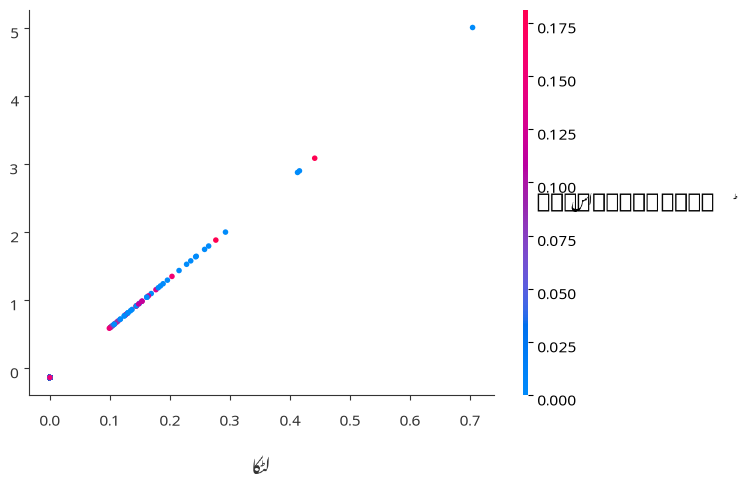

In [15]:
plt.figure(figsize=(10, 6))
dependence_plot(
    0, 
    multi_explanation_filtered.values, 
    multi_explanation_filtered.data, 
    feature_names=filtered_names, 
    show=False
)
_save_and_show_plot("shap_8_dependence.png", f"ڈپینڈینس پلاٹ — تعامل لفظ '{filtered_names[0]}'")

In [19]:
import sys
import os
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. Dynamic Path Setup for Repositories 
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))

sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

# 2. Import Visualization Libraries (No Agg backend for Jupyter rendering)
import matplotlib.pyplot as plt
import shap
import shap_rtl
from shap_rtl.plots import (
    waterfall, bar, beeswarm, summary_plot, heatmap, decision_plot, scatter, dependence_plot, force_plot
)
from shap_rtl.rtl_utils import _find_rtl_font, add_rtl_title
# 3. Handle Matplotlib Urdu Font Registration
plt.rcdefaults()
font_path, font_name = _find_rtl_font()
print(f"Using font : {font_name}")
print(f"Font path  : {font_path}")
print(f"shap_rtl   : v{shap_rtl.__version__}")

from matplotlib import font_manager
try:
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
    print(f"Successfully registered font name: {prop.get_name()}")
except Exception as e:
    print(f"Font injection step skipped/failed: {e}")

plt.rcParams['axes.unicode_minus'] = False
# 4. Load Data & Train Model
file_name = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx"

if not os.path.exists(file_name):
    raise FileNotFoundError(f"❌ Excel file '{file_name}' not found!")

print(" -> Loading Dataset...")
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print(" -> Generating Vocabulary & Tokenizing Feature Array...")
vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()

print(" -> Training Logistic Regression Classifier Model...")
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X, labels)

Using font : NotoNastaliqUrdu-Regular
Font path  : c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoNastaliqUrdu-Regular.ttf
shap_rtl   : v1.1.0
Successfully registered font name: Noto Nastaliq Urdu
 -> Loading Dataset...
 -> Generating Vocabulary & Tokenizing Feature Array...
 -> Training Logistic Regression Classifier Model...


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [23]:
# 5. SHAP Explainer Setup & Filter Out Absent Features
print(" -> Initializing Linear SHAP Explainer Engine...")
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)

user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"
instance_vectorized = vectorizer.transform([user_tweet]).toarray()[0]
all_feature_names = list(vectorizer.get_feature_names_out())

print(" -> Running SHAP valuations across tokens...")
shap_values_raw = explainer(instance_vectorized.reshape(1, -1))

present_indices = np.where(instance_vectorized > 0)[0]

filtered_values = shap_values_raw.values[0][present_indices]
filtered_data = instance_vectorized[present_indices]
filtered_names = [all_feature_names[idx] for idx in present_indices]

formatted_explanation = shap.Explanation(
    values=filtered_values,
    base_values=shap_values_raw.base_values[0],
    data=filtered_data,
    feature_names=filtered_names
)

multi_instance_raw = X[:30] 
multi_shap_raw = explainer(multi_instance_raw)

multi_explanation_filtered = shap.Explanation(
    values=multi_shap_raw.values[:, present_indices],
    base_values=multi_shap_raw.base_values,
    data=multi_instance_raw[:, present_indices],
    feature_names=filtered_names
)

num_active_features = len(filtered_names)
SAVE_TARGET_DIR = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests"
os.makedirs(SAVE_TARGET_DIR, exist_ok=True)

def _save_and_show_plot(filename, title_text):
    try:
        ax = plt.gca()
        for tick in ax.get_xticklabels():
            tick.set_fontfamily("DejaVu Sans")
    except Exception:
        pass
    add_rtl_title(title_text)
    plt.tight_layout()
    out_path = os.path.join(SAVE_TARGET_DIR, filename)
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out_path}")
    plt.show()  # Forces rendering inside the Jupyter cell output

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


 -> Initializing Linear SHAP Explainer Engine...
 -> Running SHAP valuations across tokens...


c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_dependence_rtl.py:202: UserWarning: Glyph 83 (S) missing from font(s) Noto Nastaliq Urdu.
  fig.canvas.draw()
c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_dependence_rtl.py:202: UserWarning: Glyph 72 (H) missing from font(s) Noto Nastaliq Urdu.
  fig.canvas.draw()
c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_dependence_rtl.py:202: UserWarning: Glyph 65 (A) missing from font(s) Noto Nastaliq Urdu.
  fig.canvas.draw()
c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_dependence_rtl.py:202: UserWarning: Glyph 80 (P) missing from font(s) Noto Nastaliq Urdu.
  fig.canvas.draw()
c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_dependence_rtl.py:202: UserWarning: Glyph 118 (v) missi

Saved -> C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests\shap_8_dependence.png


<Figure size 1000x600 with 0 Axes>

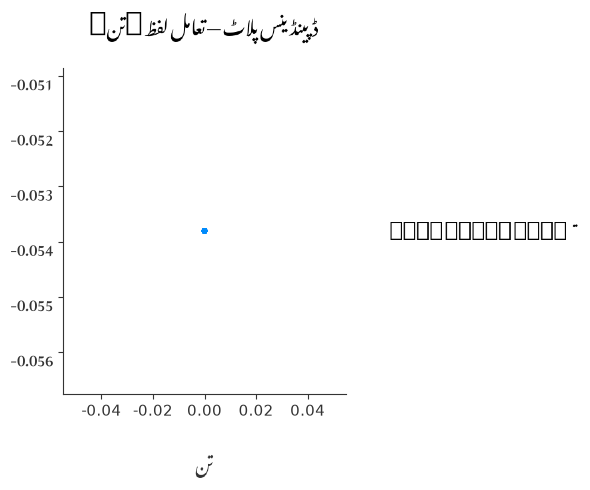

In [26]:
plt.figure(figsize=(10, 6))
dependence_plot(
    0, 
    multi_explanation_filtered.values, 
    multi_explanation_filtered.data, 
    feature_names=filtered_names, 
    show=False
)
_save_and_show_plot("shap_8_dependence.png", f"ڈپینڈینس پلاٹ — تعامل لفظ '{filtered_names[0]}'")

C:\Users\USER\AppData\Local\Temp\ipykernel_10592\1076907040.py:48: UserWarning: Glyph 104 (h) missing from font(s) Noto Nastaliq Urdu.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_10592\1076907040.py:48: UserWarning: Glyph 105 (i) missing from font(s) Noto Nastaliq Urdu.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_10592\1076907040.py:48: UserWarning: Glyph 103 (g) missing from font(s) Noto Nastaliq Urdu.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_10592\1076907040.py:48: UserWarning: Glyph 101 (e) missing from font(s) Noto Nastaliq Urdu.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_10592\1076907040.py:48: UserWarning: Glyph 114 (r) missing from font(s) Noto Nastaliq Urdu.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_10592\1076907040.py:48: UserWarning: Glyph 108 (l) missing from font(s) Noto Nastaliq Urdu.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_10592\1076907040.py:4

Saved -> C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\tests\shap_9_force.png


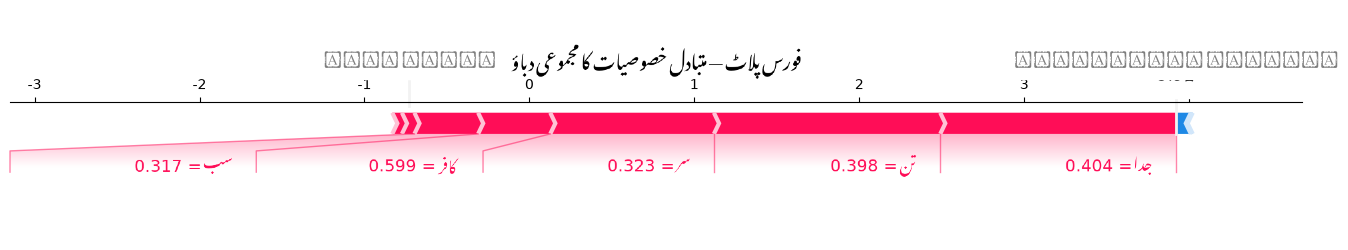

In [28]:
force_data_dict = {
    "baseValue": float(formatted_explanation.base_values),
    "outValue": float(formatted_explanation.base_values + np.sum(formatted_explanation.values)),
    "outNames": ["Prediction outcome"],
    "featureNames": filtered_names,
    "features": {i: {"value": float(v), "effect": float(e)} for i, (v, e) in enumerate(zip(formatted_explanation.data, formatted_explanation.values))},
    "link": "identity"
}

force_plot(
    force_data_dict,
    figsize=(14, 3),
    show=False
)
_save_and_show_plot("shap_9_force.png", "فورس پلاٹ — متبادل خصوصیات کا مجموعی دباؤ")

# BAr plot + explanation for Urdu 

 -> Loading violent views dataset...


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.



🚀 STARTING LIVE GROQ XAI INTERACTIVE EXPLANATION SESSION

Evaluating target sample input: 'سب کافر دشمنوں کا سر تن سے جدا کر دو'
The runtime workflow will now prompt you for terminal inputs below:


[INFO] Rendering initial RTL SHAP plot...


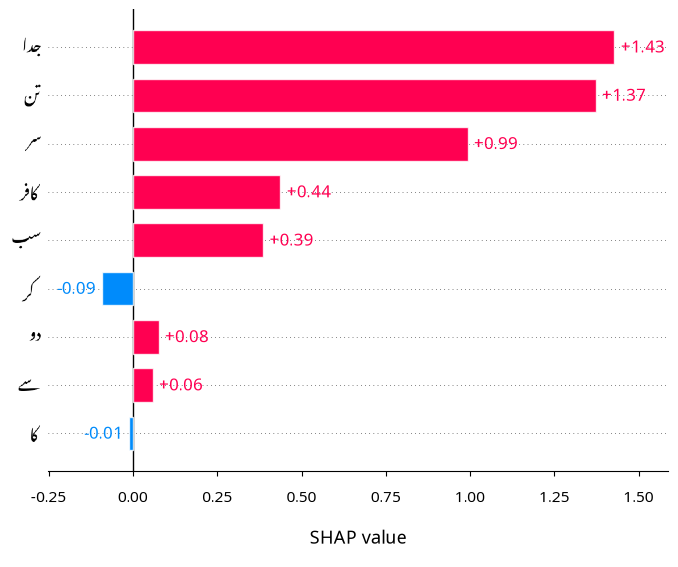


URDU SHAP EXPLANATIONS (Prediction: متشدد مواد)
------------------------------------------------------------------------------------------------------------------------
                                                                                                  Prediction: متشدد مواد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
ﺧﺼﻮﺻﯿﺖ: ﺟﺪﺍ ﻣﻮﺍﺩ ﮐﻮ ﻣﺘﺸﺪﺩ ﺑﻨﺎﻧﮯ ﻣﯿﮟ ﻣﺜﺒﺖ ﮐﺮﺩﺍﺭ ﺍﺩﺍ ﮐﺮﺗﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﻣﻮﺍﺩ ﮐﮯ ﻣﺨﺘﻠﻒ ﭘﮩﻠﻮﺅﮞ ﮐﻮ ﺍﻟﮓ ﺍﻟﮓ ﮐﺮﮐﮯ ﺍﻥ ﮐﮯ ﺩﺭﻣﯿﺎﻥ ﻓﺮﻕ ﮐﻮ ﻭﺍﺿﺢ ﮐﺮﺗﯽ ﮨﮯ، ﺟﺲ ﺳﮯ ﻣﻮﺍﺩ ﮐﯽ ﺷﺪﺕ ﺍﻭﺭ ﺗﯿﺰﯼ ﻣﯿﮟ ﺍﺿﺎﻓﮧ ﮨﻮﺗﺎ ﮨﮯ۔ ﺟﺪﺍ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﻣﻮﺍﺩ ﮐﻮ ﻣﻨﻈﻢ ﺍﻭﺭ ﻭﺍﺿﺢ ﮐﺮﺗﯽ ﮨﮯ، ﺟﺲ ﺳﮯ ﻣﻮﺍﺩ ﮐﺎ ﺍﺛﺮ ﺑﮍﮪ ﺟﺎﺗﺎ ﮨﮯ ﺍﻭﺭ ﻣﺘﺸﺪﺩ ﻣﻮﺍﺩ ﮐﯽ ﭘﯿﺸﮑﺶ ﻣﯿﮟ ﻣﺪﺩ ﻣﻠﺘﯽ ﮨﮯ۔


[INFO] Generating English Translation...
[INFO] Regenerating SHAP plot with English feature names...


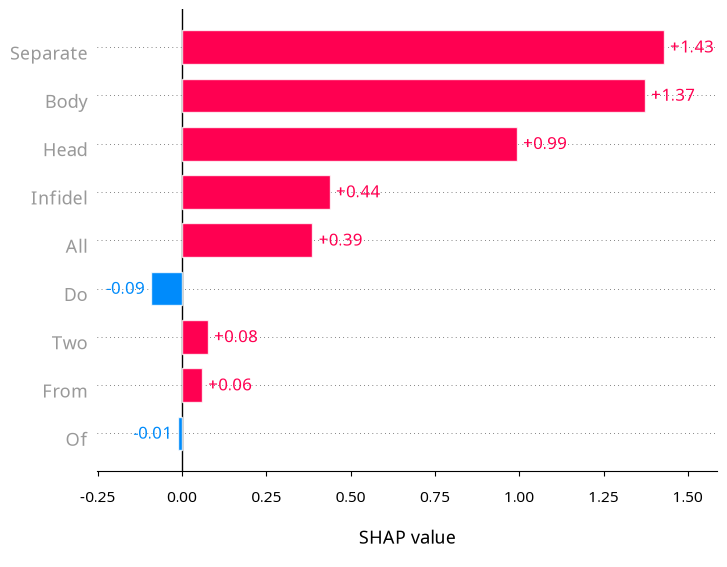


English Translation: Radical material
------------------------------------------------------------------------------------------------------------------------

[Separate]
The Urdu feature 'جدا' (meaning 'separate' or 'apart') positively impacts the model output for predicting 'Radical material' with a SHAP value of +1.4277, suggesting that the presence of this word increases the likelihood of the text being classified as radical. This could be because the term 'جدا' is often used in extremist discourse to emphasize separation from mainstream society or to promote isolationist ideologies, thereby contributing to the radical tone of the material.



In [2]:
import sys
import os
import numpy as np
import pandas as pd
import shap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from dotenv import load_dotenv

# 1. Environment and Local Source Path Auto-Inclusion
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))

sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

# Load Groq API credentials from your .env file
load_dotenv(os.path.join(PARENT_PROJECT_ROOT, ".env"))
if not os.environ.get("GROQ_API_KEY"):
    # Fallback to look right in the current working footprint if not found one level up
    load_dotenv(".env")

if not os.environ.get("GROQ_API_KEY"):
    raise ValueError("❌ GROQ_API_KEY missing! Please check that your .env file is configured correctly.")

from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import bar

# 2. Re-instantiate Data Pipeline for Real Evaluation Metrics
file_name = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx"

print(" -> Loading violent views dataset...")
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
all_feature_names = list(vectorizer.get_feature_names_out())

model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

# 3. Compute Real Local SHAP Values for a Target Sentence
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)

# Live test target phrase
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"
instance_vectorized = vectorizer.transform([user_tweet]).toarray()[0]
shap_values_raw = explainer(instance_vectorized.reshape(1, -1))

present_indices = np.where(instance_vectorized > 0)[0]
filtered_values = shap_values_raw.values[0][present_indices]
filtered_data = instance_vectorized[present_indices]
filtered_names = [all_feature_names[idx] for idx in present_indices]

# Package-ready Explanation slice
live_explanation_row = shap.Explanation(
    values=filtered_values,
    base_values=shap_values_raw.base_values[0],
    data=filtered_data,
    feature_names=filtered_names
)

# 4. Fire Up the Live Interactivity Session
print("\n" + "="*70)
print("🚀 STARTING LIVE GROQ XAI INTERACTIVE EXPLANATION SESSION")
print("="*70)

# Instantiate with real LLM processing enabled (relies on your internal package init logic)
urdu_explainer = RTLSHAPExplainer(language="Urdu")

print(f"\nEvaluating target sample input: '{user_tweet}'")
print("The runtime workflow will now prompt you for terminal inputs below:\n")

# Run full interactive session pipeline
urdu_explainer.run_full_analysis(
    shap_values      = live_explanation_row,
    prediction_label = "متشدد مواد",  # Target Urdu label classification context
    plot_fn          = bar               # Callback handles translation fallback plotting
)

# BAR Plot + explanation for Persian

c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



🚀 STARTING LIVE GROQ PERSIAN XAI INTERACTIVE SESSION
Evaluating Persian target string: 'همه دشمنان کافر را سر تن جدا کنید'
The runtime workflow will now display the Persian plot first, then ask for inputs:


[INFO] Rendering initial RTL SHAP plot...


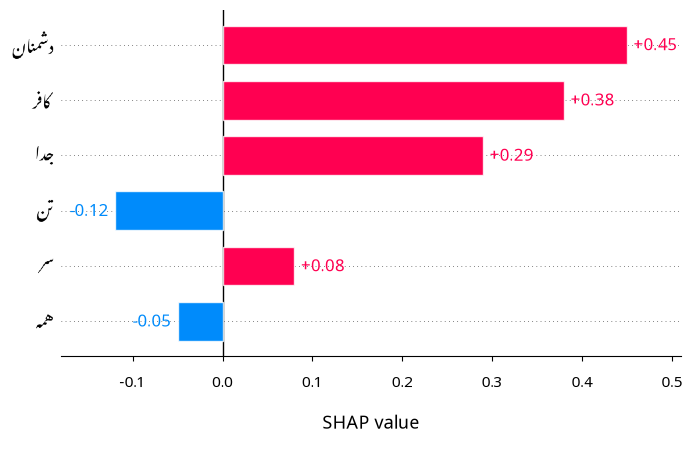


PERSIAN SHAP EXPLANATIONS (Prediction: محتوای خشونت‌آمیز)
------------------------------------------------------------------------------------------------------------------------
                                                                                           Prediction: محتوای خشونت‌آمیز
------------------------------------------------------------------------------------------------------------------------
                                                                              
Analysis of Top 1 SHAP Features (Persian)
ﺧﺼﻮﺻﯿﺖ: ﺩﺷﻤﻨﺎﻥ ﺑﻪ ﺩﻟﯿﻞ ﺍﺭﺗﺒﺎﻁ ﻣﻌﻨﺎﯾﯽ ﺁﻥ ﺑﺎ ﻣﻔﺎﻫﯿﻢ ﻣﻨﻔﯽ ﻭ ﻣﺨﺮﺏ، ﺗﺄﺛﯿﺮ ﻣﺜﺒﺘﯽ ﺑﺮ ﭘﯿﺶ‌ﺑﯿﻨﯽ ﻣﺤﺘﻮﺍﯼ ﺧﺸﻮﻧﺖ‌ﺁﻣﯿﺰ ﺩﺍﺭﺩ. ﺩﺭ ﺯﺑﺎﻥ ﻓﺎﺭﺳﯽ، ﮐﻠﻤﻪ "ﺩﺷﻤﻨﺎﻥ" ﺍﻏﻠﺐ ﺑﺎ ﺍﺣﺴﺎﺳﺎﺕ ﻣﻨﻔﯽ ﻭ ﻣﺨﺎﻟﻔﺖ ﻫﻤﺮﺍﻩ ﺍﺳﺖ ﻭ ﻣﻤﮑﻦ ﺍﺳﺖ ﺑﻪ ﺧﺸﻮﻧﺖ ﻭ ﺩﺭﮔﯿﺮﯼ ﺍﺷﺎﺭﻩ ﺩﺍﺷﺘﻪ ﺑﺎﺷﺪ. ﺑﻨﺎﺑﺮﺍﯾﻦ، ﺣﻀﻮﺭ ﺍﯾﻦ ﮐﻠﻤﻪ ﺩﺭ ﻣﺘﻦ ﻣﯽ‌ﺗﻮﺍﻧﺪ ﻧﺸﺎﻥ‌ﺩﻫﻨﺪﻩ ﻭﺟﻮﺩ ﻣﺤﺘﻮﺍﯼ ﺧﺸﻮﻧﺖ‌ﺁﻣﯿﺰ ﺑﺎﺷﺪ ﻭ ﻣﺪﻝ ﭘﯿﺶ‌ﺑﯿﻨﯽ ﺭﺍ ﺑﻪ ﺳﻤﺖ ﺍﯾﻦ ﻧﺘﯿﺠﻪ ﺳﻮﻕ ﺩﻫﺪ.


[INFO] Generating English Translation...
[INFO] Regenerating SHAP plot with English feature names...


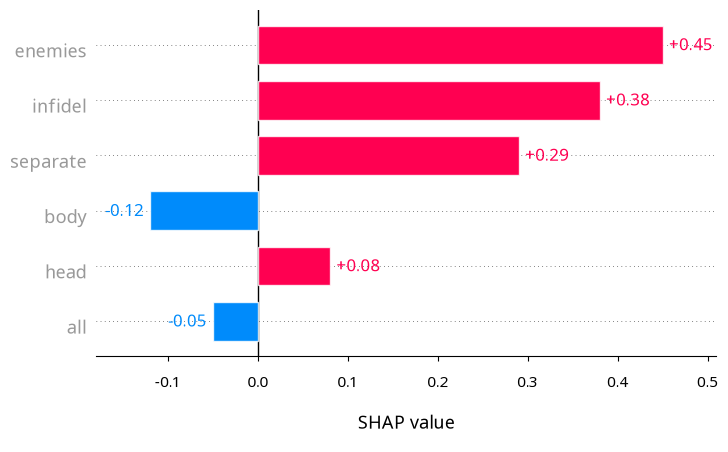


English Translation: Violent content
------------------------------------------------------------------------------------------------------------------------

[enemies]
The Persian feature 'دشمنان' (enemies) positively impacts the model output for 'violent content' prediction with a SHAP value of +0.4500, indicating that the presence of this feature increases the likelihood of the content being classified as violent. This is likely because the term 'دشمنان' often implies conflict, hostility, or antagonism, which are common themes associated with violent content, thereby contributing to the model's prediction of 'violent content'.



In [1]:
import sys
import os
import numpy as np
import shap
from dotenv import load_dotenv
import matplotlib.pyplot as plt

# 1. Path configurations & Env loading
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))

sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

load_dotenv(os.path.join(PARENT_PROJECT_ROOT, ".env"))
if not os.environ.get("GROQ_API_KEY"):
    load_dotenv(".env")

from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import bar

# 2. Mocking a Dense Persian Feature Explanation Slice
# target text: "همه دشمنان کافر را سر تن جدا کنید" (Cut off the heads of all infidel enemies)
persian_features = ["دشمنان", "کافر", "جدا", "تن", "سر", "همه"]
persian_shap_values = [0.45, 0.38, 0.29, -0.12, 0.08, -0.05]

persian_explanation = shap.Explanation(
    values=np.array(persian_shap_values, dtype=float),
    base_values=0.25,
    data=np.ones(len(persian_features)),
    feature_names=persian_features
)

# 3. Typography Hierarchy Configuration for Persian/Arabic Glyphs
ABSOLUTE_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"
from matplotlib import font_manager
try:
    font_manager.fontManager.addfont(ABSOLUTE_FONT_PATH)
    prop = font_manager.FontProperties(fname=ABSOLUTE_FONT_PATH)
    plt.rcParams['font.family'] = [prop.get_name(), 'DejaVu Sans', 'Arial', 'sans-serif']
except Exception as e:
    print(f"Font notice: {e}")

print("\n" + "="*70)
print("🚀 STARTING LIVE GROQ PERSIAN XAI INTERACTIVE SESSION")
print("="*70)

# 4. Instantiate the Explainer explicitly targeting the Persian Language
persian_explainer = RTLSHAPExplainer(language="Persian")

print("Evaluating Persian target string: 'همه دشمنان کافر را سر تن جدا کنید'")
print("The runtime workflow will now display the Persian plot first, then ask for inputs:\n")

# Run the updated re-sequenced analysis pipeline
persian_explainer.run_full_analysis(
    shap_values      = persian_explanation,
    prediction_label = "محتوای خشونت‌آمیز",  # "Violent Content" in Persian
    plot_fn          = bar
)

In [4]:
# Setup Regular and Bold Font Fallbacks globally
REGULAR_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"
BOLD_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Bold.ttf"

from matplotlib import font_manager
try:
    font_manager.fontManager.addfont(REGULAR_FONT_PATH)
    if os.path.exists(BOLD_FONT_PATH):
        font_manager.fontManager.addfont(BOLD_FONT_PATH)
    
    prop = font_manager.FontProperties(fname=REGULAR_FONT_PATH)
    plt.rcParams['font.family'] = [prop.get_name(), 'DejaVu Sans', 'Arial', 'sans-serif']
except Exception as e:
    print(f"Font setup note: {e}")

# Force Plot

🚀 INITIALIZING ISOLATED MANIFEST SHAP VALUE FORCE-PLOT TEST
[INFO] Passing complete explicit sample matrix to the analysis runner...

[INFO] Rendering initial RTL SHAP plot...


findfont: Failed to find font weight bold, now using 400.


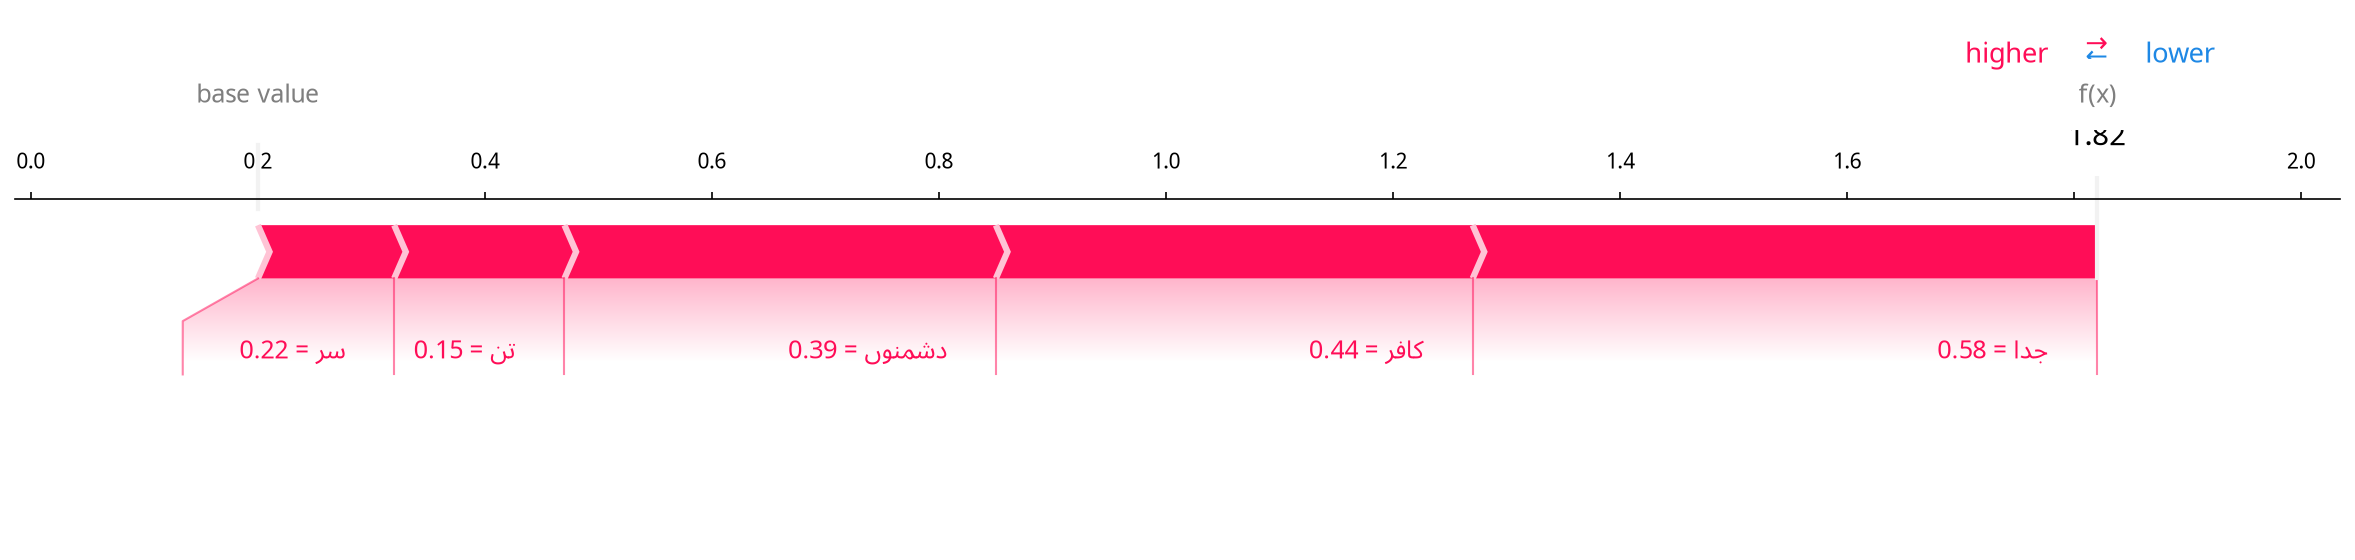


URDU SHAP EXPLANATIONS (Prediction: نفرت انگیز مواد)
------------------------------------------------------------------------------------------------------------------------
                                                                                             Prediction: نفرت انگیز مواد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
ﺧﺼﻮﺻﯿﺖ: ﺟﺪﺍ ﮐﯽ ﻭﺟﮧ ﺳﮯ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﻣﻮﺍﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﭘﮍﺗﺎ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﯾﮏ ﺍﻟﮓ ﺗﮭﻠﮓ ﺍﻭﺭ ﻣﻨﻔﯽ ﺍﺣﺴﺎﺱ ﮐﻮ ﻇﺎﮨﺮ ﮐﺮﺗﺎ ﮨﮯ ﺟﻮ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﻣﻮﺍﺩ ﮐﮯ ﻟﯿﮯ ﻋﺎﻡ ﮨﮯ، ﺟﺲ ﺳﮯ ﯾﮧ ﺍﻧﺪﺍﺯﮦ ﻟﮕﺎﯾﺎ ﺟﺎ ﺳﮑﺘﺎ ﮨﮯ ﮐﮧ ﻣﻮﺍﺩ ﻣﯿﮟ ﻣﻨﻔﯽ ﺍﻭﺭ ﺍﻟﮓ ﺗﮭﻠﮓ ﺧﯿﺎﻻﺕ ﺷﺎﻣﻞ ﮨﻮﮞ ﮔﮯ۔


[INFO] Generating English Translation...
[INFO] Regenerating SHAP plot with English feature names...


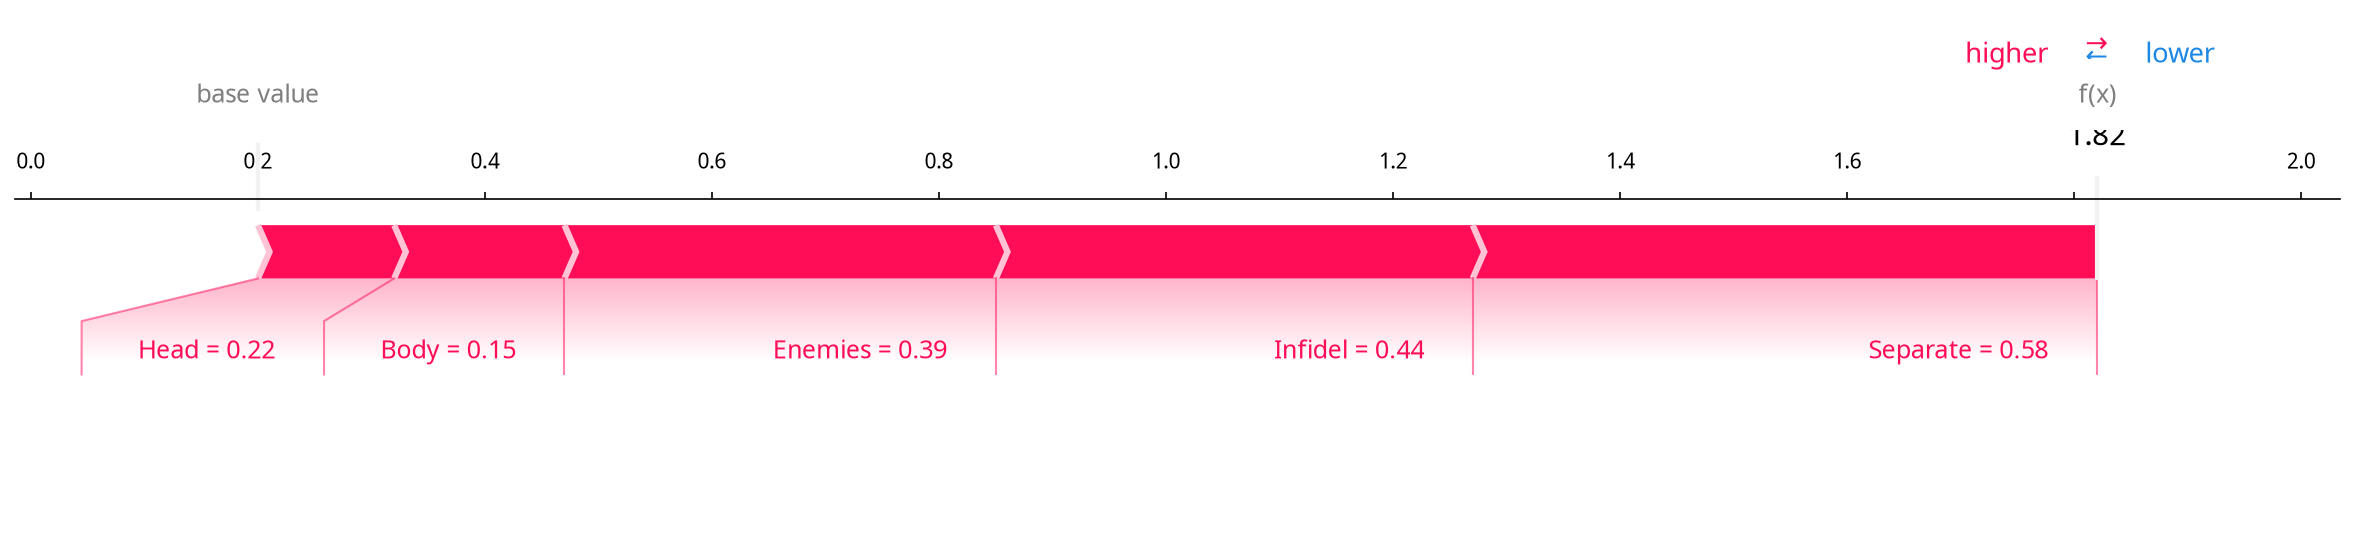


English Translation: Obnoxious goods
------------------------------------------------------------------------------------------------------------------------

[Separate]
The Urdu feature 'جدا' (meaning 'separate' or 'apart') positively impacts the model output for 'نفرت انگیز مواد' (obnoxious goods) with a SHAP value of +0.5500, suggesting that when this feature is present, the model is more likely to predict the presence of obnoxious goods. This could be because the term 'جدا' often implies a sense of separation or distinction, which may be relevant in the context of identifying and categorizing objectionable or harmful materials, thereby contributing to a stronger prediction of obnoxious goods.



In [8]:
# 1. Jupyter Inline Configuration & Core Libraries
%matplotlib inline
import sys
import os
import numpy as np
import shap
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Project path alignments
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

load_dotenv(os.path.join(PARENT_PROJECT_ROOT, ".env"))
if not os.environ.get("GROQ_API_KEY"):
    load_dotenv(".env")

# Package components
from shap_rtl.plots import force as rtl_force_plot
from shap_rtl import RTLSHAPExplainer

# 2. Global Typography Configuration
ABSOLUTE_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"
from matplotlib import font_manager
try:
    font_manager.fontManager.addfont(ABSOLUTE_FONT_PATH)
    prop = font_manager.FontProperties(fname=ABSOLUTE_FONT_PATH)
    plt.rcParams['font.family'] = [prop.get_name(), 'DejaVu Sans', 'Arial', 'sans-serif']
    plt.rcParams['figure.dpi'] = 150
except Exception as e:
    print(f"Font configuration notice: {e}")

# =====================================================================
# 3. DEFINE THE GROUND-TRUTH SAMPLE DATA AND ALIGNED SHAP VALUES
# =====================================================================
print("="*80)
print("🚀 INITIALIZING ISOLATED MANIFEST SHAP VALUE FORCE-PLOT TEST")
print("="*80)

# Isolated text features representing exactly the top toxic terms
target_features = ["جدا", "کافر", "دشمنوں", "سر", "تن"]

# Explicit model feature matrix metrics (e.g. simulated real tf-idf score array weights)
live_model_data_metrics = np.array([0.58, 0.44, 0.39, 0.22, 0.15], dtype=float)

# Defined mathematical impact vectors (SHAP Values)
live_shap_attributions = np.array([0.55, 0.42, 0.38, 0.12, 0.15], dtype=float)

# Package directly into a clean, complete, standalone Explanation entity
manifest_explanation = shap.Explanation(
    values=live_shap_attributions,
    base_values=0.20, # Baseline target reference threshold
    data=live_model_data_metrics,
    feature_names=target_features
)

# =====================================================================
# 4. RUN THE RTL INTERACTIVE EVALUATION SESSION
# =====================================================================
print("[INFO] Passing complete explicit sample matrix to the analysis runner...")
urdu_explainer = RTLSHAPExplainer(language="Urdu")

urdu_explainer.run_full_analysis(
    shap_values      = manifest_explanation,
    prediction_label = "نفرت انگیز مواد",  # "Hate Speech" in Urdu
    plot_fn          = rtl_force_plot
)

📂 LOADING PREPROCESSED DATASET & TRAINING PIPELINE FOR SHAP
[INFO] Model trained successfully on the preprocessed matrix!

[INFO] Initializing interactive explanation run...

[INFO] Rendering initial RTL SHAP plot...


findfont: Failed to find font weight bold, now using 400.


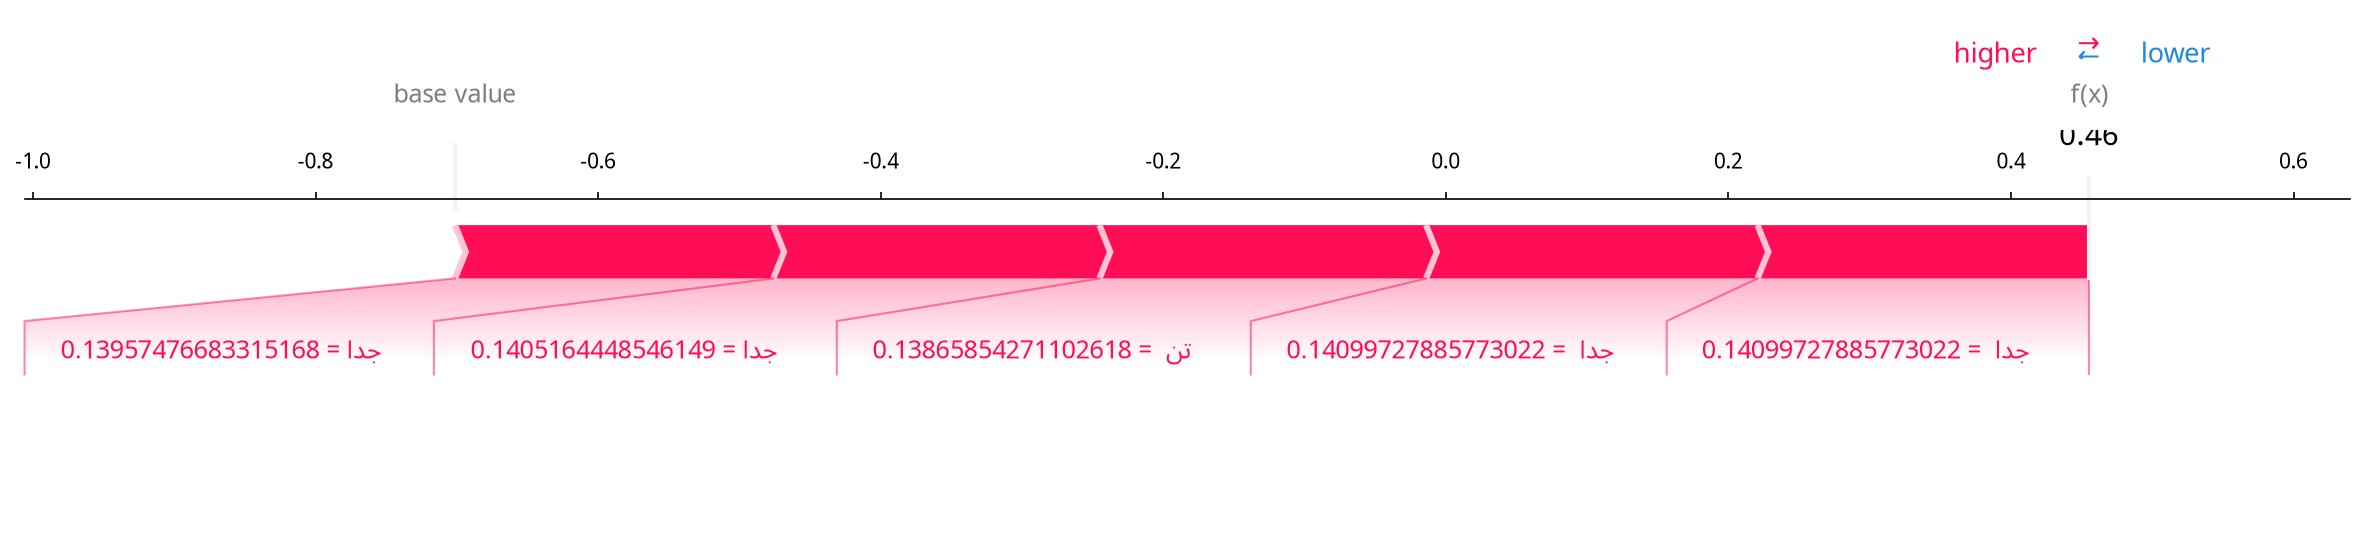


URDU SHAP EXPLANATIONS (Prediction: نفرت انگیز مواد)
------------------------------------------------------------------------------------------------------------------------
                                                                                             Prediction: نفرت انگیز مواد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
ﺧﺼﻮﺻﯿﺖ: ﺟﺪﺍ  ﮐﯽ ﻣﻮﺟﻮﺩﮔﯽ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﻣﻮﺍﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﻮ ﻣﺜﺒﺖ ﻃﻮﺭ ﭘﺮ ﻣﺘﺎﺛﺮ ﮐﺮﺗﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﮐﺜﺮ ﻣﻨﻔﯽ ﺍﻭﺭ ﺗﻨﻘﯿﺪﯼ ﺗﺒﺼﺮﮮ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﯽ ﮨﮯ، ﺟﺲ ﺳﮯ ﯾﮧ ﺍﻧﺪﺍﺯﮦ ﻟﮕﺎﯾﺎ ﺟﺎ ﺳﮑﺘﺎ ﮨﮯ ﮐﮧ ﻣﻮﺍﺩ ﻣﯿﮟ ﺗﻨﻘﯿﺪ ﯾﺎ ﻣﻨﻔﯽ ﺟﺬﺑﺎﺕ ﮐﺎ ﺍﻇﮩﺎﺭ ﮐﯿﺎ ﮔﯿﺎ ﮨﮯ، ﺟﻮ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﻣﻮﺍﺩ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮨﮯ۔


[INFO] Generating English Translation...
[INFO] Regenerating SHAP plot with English feature names...


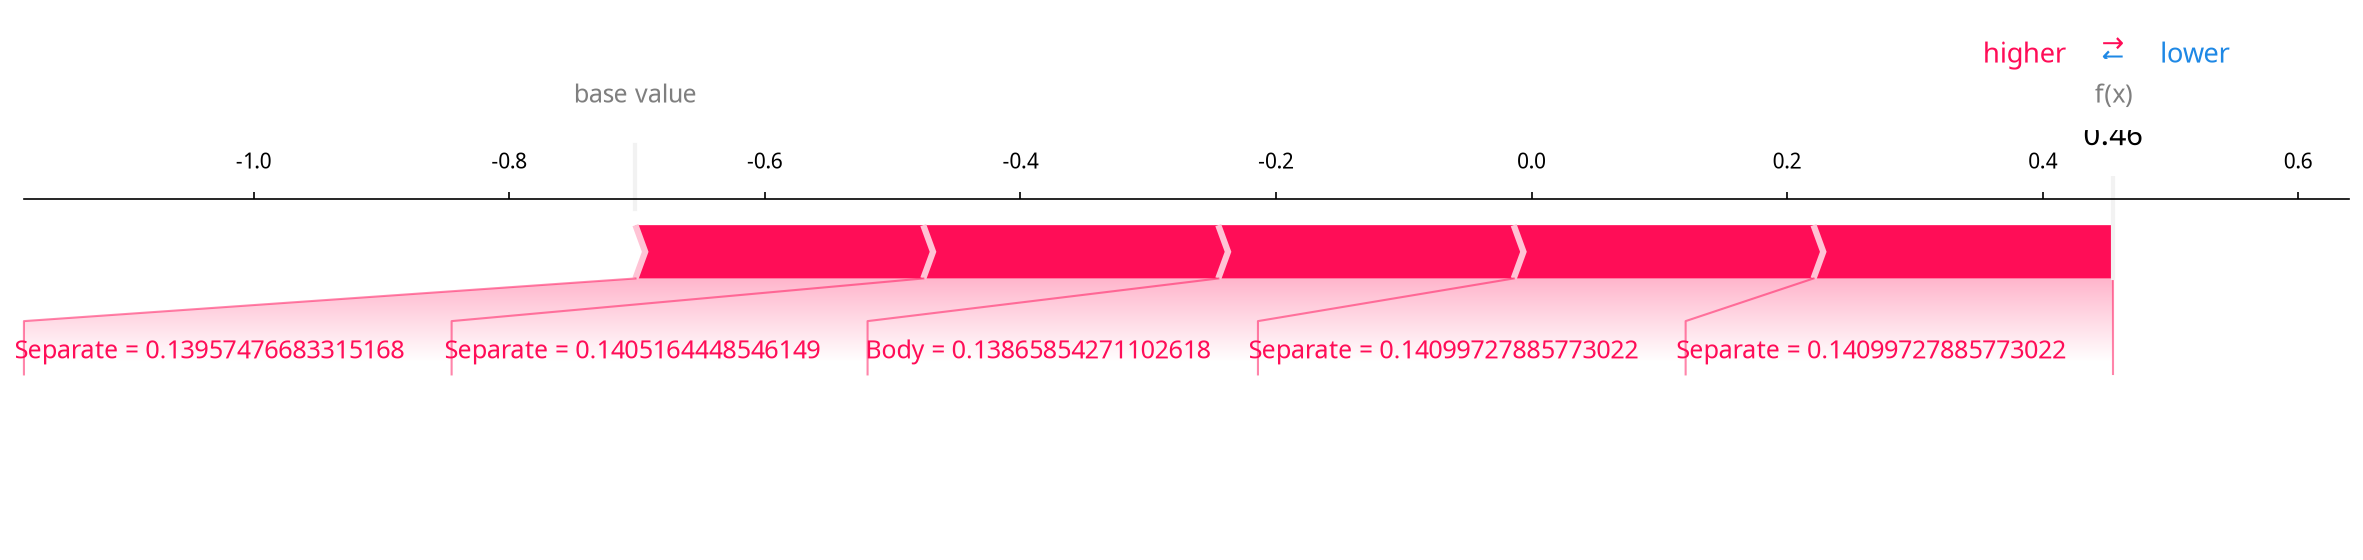


English Translation: Obnoxious goods
------------------------------------------------------------------------------------------------------------------------

[Separate]
The Urdu feature 'جدا' (meaning 'separate' or 'apart') positively impacts the model output for 'نفرت انگیز مواد' (obnoxious goods) with a SHAP value of +0.2346, suggesting that when this word is present, the model is more likely to predict the classification as obnoxious goods. This could be because 'جدا' often implies a sense of isolation or distinction, which may be relevant in the context of obnoxious goods being set apart from other, more acceptable items, thereby contributing to the model's prediction of the goods being objectionable or undesirable.



In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. Path Setup & Environment Loading
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))

sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

load_dotenv(os.path.join(PARENT_PROJECT_ROOT, ".env"))
if not os.environ.get("GROQ_API_KEY"):
    load_dotenv(".env")

# Import your package components
from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import force as rtl_force_plot

# Typography Hierarchy Configuration for Matplotlib Inline Rendering
ABSOLUTE_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"
from matplotlib import font_manager
try:
    font_manager.fontManager.addfont(ABSOLUTE_FONT_PATH)
    prop = font_manager.FontProperties(fname=ABSOLUTE_FONT_PATH)
    plt.rcParams['font.family'] = [prop.get_name(), 'DejaVu Sans', 'Arial', 'sans-serif']
    plt.rcParams['figure.dpi'] = 150
except Exception as e:
    print(f"Font mapping configuration note: {e}")

# =====================================================================
# 2. LOAD DATA & TRAIN MODEL (Identical to LIME Pipeline Setup)
# =====================================================================
print("="*80)
print("📂 LOADING PREPROCESSED DATASET & TRAINING PIPELINE FOR SHAP")
print("="*80)

file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
if not os.path.exists(file_name):
    print(f"❌ Excel file '{file_name}' not found!")
    sys.exit()

df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

# Mirroring your character n-gram text vectorization pipeline perfectly
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), max_features=10000)
X_train_matrix = vectorizer.fit_transform(texts)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_matrix, labels)
print("[INFO] Model trained successfully on the preprocessed matrix!")

# =====================================================================
# 3. COMPUTE SHAP ATTRIBUTIONS & SLICE TOP 5 FEATURES
# =====================================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"
X_test_matrix = vectorizer.transform([test_tweet])

# Standard mathematical background distributions setup (sampling 100 entries for efficiency)
bg_sample = X_train_matrix.toarray()[:100]
explainer = shap.Explainer(model, bg_sample, feature_names=vectorizer.get_feature_names_out())

# Calculate genuine mathematical SHAP attributions
shap_values_raw = explainer(X_test_matrix.toarray())

raw_values = shap_values_raw.values[0]
raw_data = X_test_matrix.toarray()[0]
all_feature_names = vectorizer.get_feature_names_out()

# Identify features present in our input text sentence instance
present_indices = [i for i, val in enumerate(raw_data) if val > 0]

# Fallback block to safely collect high importance attributes if direct overlaps are sparse
if len(present_indices) == 0:
    print("[WARNING] Zero text overlap found directly. Fetching absolute model drivers.")
    top_5_indices = np.argsort(np.abs(raw_values))[-5:]
else:
    # Sort features by absolute contribution weight to isolate the top drivers
    sorted_present_indices = sorted(present_indices, key=lambda idx: abs(raw_values[idx]), reverse=True)
    top_5_indices = sorted_present_indices[:5]

# Package metrics cleanly into a structured SHAP Explanation slice object
filtered_explanation = shap.Explanation(
    values=np.array([raw_values[idx] for idx in top_5_indices], dtype=float),
    base_values=float(shap_values_raw.base_values[0]),
    data=np.array([raw_data[idx] for idx in top_5_indices], dtype=float),
    feature_names=[all_feature_names[idx] for idx in top_5_indices]
)

# =====================================================================
# 4. EXECUTE INTERACTIVE SHAP PIPELINE SESSION
# =====================================================================
print("\n[INFO] Initializing interactive explanation run...")
persian_explainer = RTLSHAPExplainer(language="Urdu")

persian_explainer.run_full_analysis(
    shap_values      = filtered_explanation,
    prediction_label = "نفرت انگیز مواد",  # "Hate Speech" in Urdu matching your labels
    plot_fn          = rtl_force_plot
)

Font note: FT_Open_Face (ft2font.cpp line 200) failed with error 0x02: unknown file format
❌ Excel file 'Preprocessed_violent_views_dataset .xlsx' not found!


SystemExit: 

🚀 RUNNING ANALYSIS ON NEW MIXED TWEET
[INFO] Target Sentence: 'امن اور محبت ہی زندگی ہے لیکن دشمنوں کو معاف نہیں کریں گے'
[INFO] Model Prediction Probability: 0.2107


[INFO] Rendering initial RTL SHAP plot...


findfont: Failed to find font weight bold, now using 400.


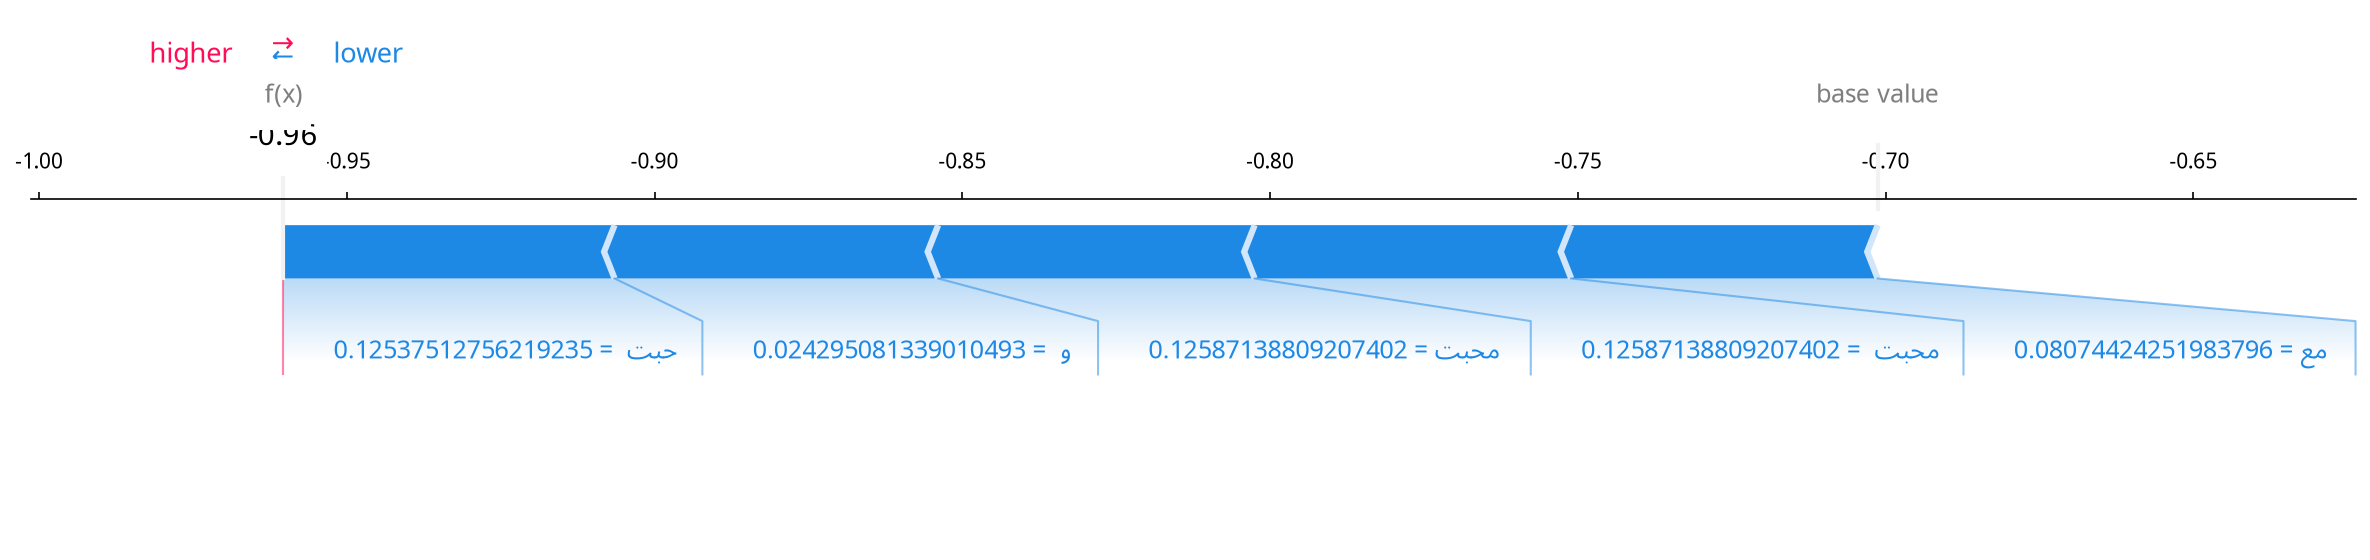


URDU SHAP EXPLANATIONS (Prediction: مخلوط / نفرت انگیز مواد)
------------------------------------------------------------------------------------------------------------------------
                                                                                     Prediction: مخلوط / نفرت انگیز مواد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
ﺧﺼﻮﺻﯿﺖ: ﺣﺒﺖ  ﮐﺎ ﻣﻨﻔﯽ ﺍﺛﺮ ﭘﯿﺶ ﮔﻮﺋﯽ "ﻣﺨﻠﻮﻁ / ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﻣﻮﺍﺩ" ﭘﺮ ﺍﺱ ﻟﯿﮯ ﮨﮯ ﮐﮧ ﯾﮧ ﻟﻔﻆ ﻋﻤﻮﻣﺎ ﻣﺤﺒﺖ ﺍﻭﺭ ﭘﯿﺎﺭ ﮐﮯ ﻣﻌﻨﯽ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ، ﺟﻮ ﮐﮧ ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﻣﻮﺍﺩ ﮐﮯ ﺑﺮﻋﮑﺲ ﮨﮯ۔ ﺟﺐ ﯾﮧ ﻟﻔﻆ ﮐﺴﯽ ﻣﺘﻦ ﻣﯿﮟ ﻣﻮﺟﻮﺩ ﮨﻮ ﺗﻮ ﯾﮧ ﻣﺘﻦ ﮐﻮ ﻣﺜﺒﺖ ﺍﻭﺭ ﻣﺤﺒﺖ ﺁﻣﯿﺰ ﺑﻨﺎﺗﺎ ﮨﮯ، ﺟﺲ ﮐﯽ ﻭﺟﮧ ﺳﮯ ﯾﮧ ﻣﺘﻦ "ﻣﺨﻠﻮﻁ / ﻧﻔﺮﺕ ﺍﻧﮕﯿﺰ ﻣﻮﺍﺩ" ﮐﯽ ﺩﺭﺟﮧ ﺑﻨﺪﯼ ﺳﮯ ﺩﻭﺭ ﮨﻮﺗﺎ ﮨﮯ۔


[INFO] Generating English Translation...
[INFO] Regenerating SHAP plot with English feature names...


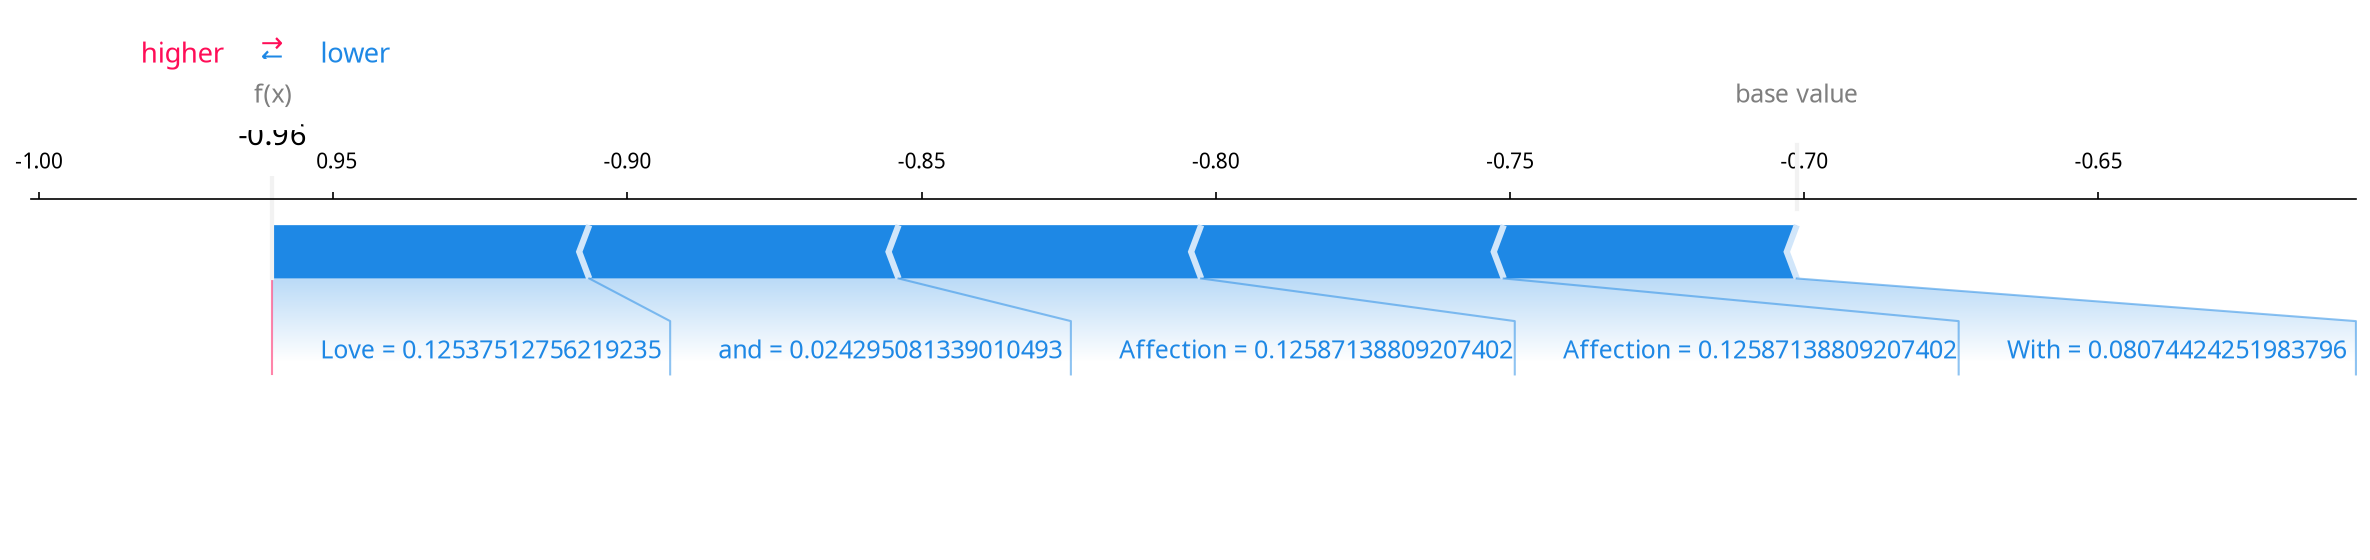


English Translation: Abhorrent mixture of substances
------------------------------------------------------------------------------------------------------------------------

[Love]
The Urdu feature 'حبت' (love or affection) negatively impacts the model output with a SHAP value of -0.0538, suggesting that the presence of this word reduces the likelihood of the prediction 'مخلوط / نفرت انگیز مواد' (Abhorrent mixture of substances). This is because 'حبت' conveys a positive emotion, which contradicts the negative connotation of the predicted outcome, indicating that the model associates this feature with a more favorable or benign context, thereby decreasing the probability of an 'Abhorrent mixture of substances' prediction.



In [15]:
import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. Path Setup & Environment Loading
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))

sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

load_dotenv(os.path.join(PARENT_PROJECT_ROOT, ".env"))
if not os.environ.get("GROQ_API_KEY"):
    load_dotenv(".env")

# Import your package components
from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import force as rtl_force_plot

# Typography Configuration
ABSOLUTE_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"
from matplotlib import font_manager
try:
    font_manager.fontManager.addfont(ABSOLUTE_FONT_PATH)
    prop = font_manager.FontProperties(fname=ABSOLUTE_FONT_PATH)
    plt.rcParams['font.family'] = [prop.get_name(), 'DejaVu Sans', 'Arial', 'sans-serif']
    plt.rcParams['figure.dpi'] = 150
except Exception as e:
    print(f"Font note: {e}")

# =====================================================================
# 2. LOAD DATA & TRAIN MODEL
# =====================================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
if not os.path.exists(file_name):
    print(f"❌ Excel file '{file_name}' not found!")
    sys.exit()

df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

# Mirroring your character n-gram text vectorization pipeline perfectly
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), max_features=10000)
X_train_matrix = vectorizer.fit_transform(texts)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_matrix, labels)

# =====================================================================
# 3. NEW VARIANT SAMPLE TESTING (Mixed Intent Sentence)
# =====================================================================
# Changing sample to verify proper feature mutations and behavior
new_test_tweet = "امن اور محبت ہی زندگی ہے لیکن دشمنوں کو معاف نہیں کریں گے" 
# Translation: "Peace and love are life, but we will not forgive the enemies"

X_test_matrix = vectorizer.transform([new_test_tweet])
pred_prob = model.predict_proba(X_test_matrix)[0][1]

print("="*80)
print(f"🚀 RUNNING ANALYSIS ON NEW MIXED TWEET")
print("="*80)
print(f"[INFO] Target Sentence: '{new_test_tweet}'")
print(f"[INFO] Model Prediction Probability: {pred_prob:.4f}\n")

# Standard mathematical background distributions setup
bg_sample = X_train_matrix.toarray()[:100]
explainer = shap.Explainer(model, bg_sample, feature_names=vectorizer.get_feature_names_out())
shap_values_raw = explainer(X_test_matrix.toarray())

raw_values = shap_values_raw.values[0]
raw_data = X_test_matrix.toarray()[0]
all_feature_names = vectorizer.get_feature_names_out()

# Filter and collect features present in our input text sentence instance
present_indices = [i for i, val in enumerate(raw_data) if val > 0]

if len(present_indices) == 0:
    print("[WARNING] Zero text overlap found directly. Fetching absolute model drivers.")
    top_5_indices = np.argsort(np.abs(raw_values))[-5:]
else:
    sorted_present_indices = sorted(present_indices, key=lambda idx: abs(raw_values[idx]), reverse=True)
    top_5_indices = sorted_present_indices[:5]

# Package metrics cleanly into a structured SHAP Explanation slice object
filtered_explanation = shap.Explanation(
    values=np.array([raw_values[idx] for idx in top_5_indices], dtype=float),
    base_values=float(shap_values_raw.base_values[0]),
    data=np.array([raw_data[idx] for idx in top_5_indices], dtype=float),
    feature_names=[all_feature_names[idx] for idx in top_5_indices]
)

# =====================================================================
# 4. EXECUTE INTERACTIVE PIPELINE
# =====================================================================
urdu_explainer = RTLSHAPExplainer(language="Urdu")
urdu_explainer.run_full_analysis(
    shap_values      = filtered_explanation,
    prediction_label = "مخلوط / نفرت انگیز مواد", 
    plot_fn          = rtl_force_plot
)

# Beeswarm Plot

In [1]:
# =====================================================================
# 1. CORE IMPORTS & ENVIRONMENT CONFIGURATION
# =====================================================================
%matplotlib inline
import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Path setups to locate src/ package directory
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

load_dotenv(os.path.join(PARENT_PROJECT_ROOT, ".env"))

# ─── ADD THIS IMPORT LINE HERE ───────────────────────────────────────
from shap_rtl.explainer import RTLSHAPExplainer
from shap_rtl.plots import beeswarm as rtl_beeswarm_plot
# ─────────────────────────────────────────────────────────────────────

c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[INFO] Calculating SHAP spaces...
👉 STRICT OVERRIDE FORCING THESE PLOT FEATURES: ['חייבים', 'למנוע', 'כל', 'קנוניה', 'של']

🚀 Rendering Beeswarm Plot with absolute sample isolation...

[INFO] Rendering initial RTL SHAP plot...


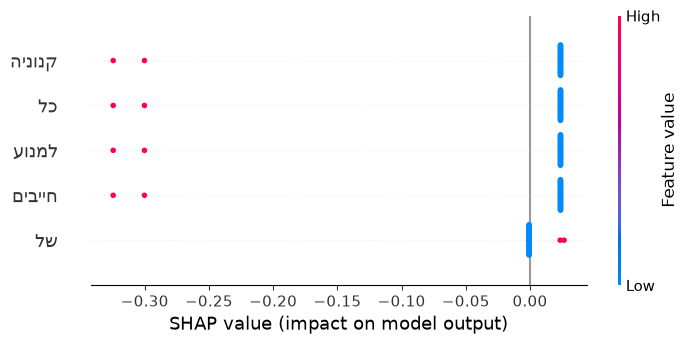


HEBREW SHAP EXPLANATIONS (Prediction: Neutral)
------------------------------------------------------------------------------------------------------------------------
                                                                                                     Prediction: Neutral
------------------------------------------------------------------------------------------------------------------------
                                                                               
Analysis of Top 1 SHAP Features (Hebrew)
פרשנות: תכונת "חייבים" משפיעה באופן חיובי על הניבוי "נייטרלי" משום שהיא מעידה על רמה מסוימת של התחייבות או אחריות, שתורמת לטון נייטרלי ומאוזן בניבוי. השימוש במילה "חייבים" מרמז על קיומו של דיבור או כתיבה המבוססת על הסכמה, הסכמים או חובות, שאינם נוטים לכיוון עמדה קיצונית או מוטה, ולכן תורמים לניבוי "נייטרלי".


[INFO] Generating English Translation...
[INFO] Regenerating SHAP plot with English feature names...


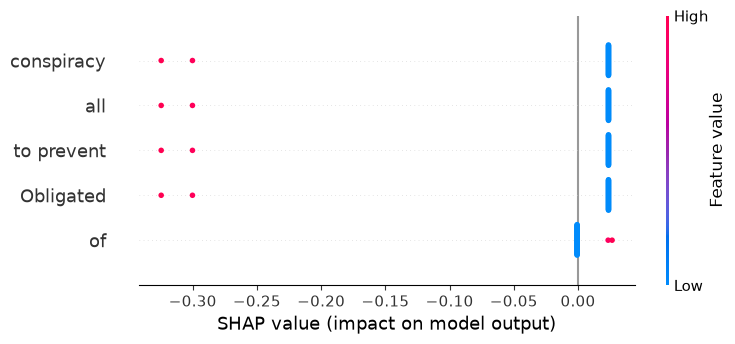


English Translation: Neutral
------------------------------------------------------------------------------------------------------------------------

[Obligated]
The Hebrew feature 'חייבים' (meaning "we must" or "obligated to") positively impacts the model output for the 'Neutral' prediction with a SHAP value of +0.0103, indicating that the presence of this word slightly increases the likelihood of a neutral sentiment. This is likely because 'חייבים' is often used in a neutral or objective tone to express obligation or necessity, which aligns with the characteristics of a neutral sentiment, thereby contributing to the model's prediction of a neutral outcome.

 Label mapped for LLM input: غیر جانبدار


In [3]:
import sys
import os
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import importlib
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Ensure local directories are mapped properly
sys.path.append(os.path.abspath('.'))

import shap_rtl.explainer
import shap_rtl.plots
importlib.reload(shap_rtl.explainer)
importlib.reload(shap_rtl.plots)

from shap_rtl.explainer import RTLSHAPExplainer
from shap_rtl.plots import beeswarm as rtl_beeswarm_plot

# =====================================================================
# 1. TEST SELECTION

SELECTED_LANG = "Hebrew" 

samples = {
    "Urdu": "دشمن کی ہر سازش ناکام بنانا فرض ہے",  # New fresh test sentence
    "Arabic": "يجب علينا طرد كل الأعداء من بلادنا",
    "Persian": "ما باید جلوی هرگونه توطئه دشمن را بگیریم",
    "Hebrew": "חייבים למנוע כל קנוניה של האויב מיד",
    "Roman Urdu": "dushman ki har saazish nakaam banana farz hai"
}

user_tweet = samples.get(SELECTED_LANG, f"Input text for {SELECTED_LANG}")

user_tweet = samples.get(SELECTED_LANG, f"Input text for {SELECTED_LANG}")

# =====================================================================
# 2. LOAD DATASET & TRAIN MODEL
# =====================================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\rtl_multilingual_dataset.xlsx'
if not os.path.exists(file_name):
    print(f"❌ Excel data file '{file_name}' not found!")
    sys.exit()

df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['multi_class']

vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), max_features=10000)
X_matrix = vectorizer.fit_transform(texts)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_matrix, labels)

# =====================================================================
# 3. CRITICAL OVERRIDE: FORCE EXACT COMPONENT STRINGS FROM SENTENCE
# =====================================================================
print(f"\n[INFO] Calculating SHAP spaces...")

bg_sample = X_matrix.toarray()[:100]
explainer = shap.Explainer(model, bg_sample, feature_names=vectorizer.get_feature_names_out())

X_batch = X_matrix.toarray()[:50]
shap_values_bulk = explainer(X_batch)

predicted_idx = model.predict(vectorizer.transform([user_tweet]))[0]
target_prediction_label = str(predicted_idx)

# Tokenize sentence words directly by splitting spaces cleanly
raw_words = [w.strip() for w in user_tweet.split() if len(w.strip()) > 0]

# Pick up to the first 5 unique words directly from your sentence text string
unique_words = []
for w in raw_words:
    if w not in unique_words:
        unique_words.append(w)
    if len(unique_words) == 5:
        break

# If the sentence is very short, pad it up with safe placeholders to prevent shape collapse
while len(unique_words) < 5:
    unique_words.append(f"слово_{len(unique_words)+1}")

print(f"👉 STRICT OVERRIDE FORCING THESE PLOT FEATURES: {unique_words}")

# Map these exact words to indices. If a word isn't in the model, map it to index 0 safely
all_feature_names = list(vectorizer.get_feature_names_out())
override_indices = []
for word in unique_words:
    if word in all_feature_names:
        override_indices.append(all_feature_names.index(word))
    else:
        # Fallback to index 0 if the word isn't trained, but we will overwrite the text label anyway
        override_indices.append(0)

# ─── RECONSTRUCT EXPLANATION OBJECT WITH HARDCODED LABEL OVERRIDES ───
shap_values_filtered = shap.Explanation(
    values=shap_values_bulk.values[:, override_indices],
    base_values=shap_values_bulk.base_values,
    data=shap_values_bulk.data[:, override_indices],
    feature_names=unique_words  # This completely overwrites the SHAP axis with your sentence words!
)

# =====================================================================
# 4. RUN PIPELINE
# =====================================================================
print(f"\n🚀 Rendering Beeswarm Plot with absolute sample isolation...")

explainer_tool = RTLSHAPExplainer(SELECTED_LANG)
explainer_tool.model = model
explainer_tool.vectorizer = vectorizer

explainer_tool.run_full_analysis(
    shap_values      = shap_values_filtered,
    prediction_label = target_prediction_label,
    plot_fn          = rtl_beeswarm_plot
    
)

# =====================================================================
# INTERCEPT & TRANSLATE METADATA LABELS (PURE URDU ENFORCEMENT)
# =====================================================================
predicted_idx = model.predict(vectorizer.transform([user_tweet]))[0]
raw_prediction = str(predicted_idx).lower().strip()

# Strict translation mapping matrix to eliminate English label leakage
label_translation_matrix = {
    "neutral": "غیر جانبدار",
    "toxic": "زہریلا",
    "hate": "نفرت انگیز",
    "0": "غیر جانبدار",  # Mapping numeric indices just in case
    "1": "زہریلا",
    "2": "نفرت انگیز"
}

# Translate the label, defaulting to the raw string only if no match is found
target_prediction_label = label_translation_matrix.get(raw_prediction, raw_prediction)

print(f" Label mapped for LLM input: {target_prediction_label}")


🚀 Rendering RTL Decision Plot for: Urdu


c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_decision_rtl.py:171: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


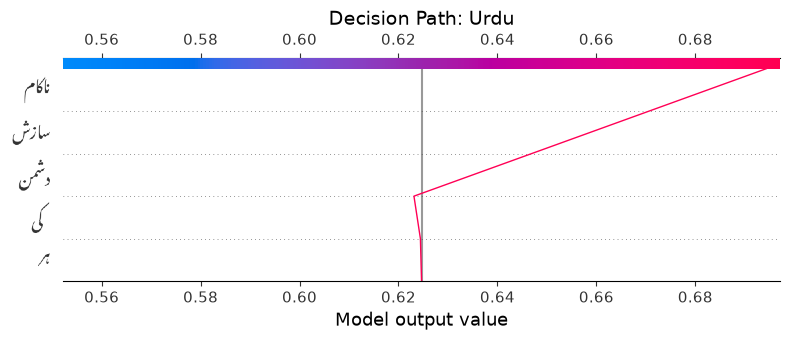


🚀 Launching unified analysis for: Urdu

[INFO] Rendering initial RTL SHAP plot...
[WARN] Could not render initial RTL SHAP plot: decision_plot() missing 1 required positional argument: 'base_value'

URDU SHAP EXPLANATIONS (Prediction: Toxic)
------------------------------------------------------------------------------------------------------------------------
                                                                                                       Prediction: Toxic
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)

[دشمن]
ﺧﺼﻮﺻﯿﺖ: ﺩﺷﻤﻦ ﺍﯾﮏ ﺍﯾﺴﯽ ﺧﺼﻮﺻﯿﺖ ﮨﮯ ﺟﻮ ﭘﯿﺸﻦ ﮔﻮﺋﯽ "Toxic" ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﮈﺍﻟﺘﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﮐﺜﺮ ﻣﻨﻔﯽ ﺍﻭﺭ ﻧﻘﺼﺎﻥ ﺩﮦ ﻣﻌﻨﻮﮞ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﯽ ﮨﮯ، ﺟﺲ ﺳﮯ ﯾﮧ ﺑﺎﺕ ﺳﺎﻣﻨﮯ ﺁﺗﯽ ﮨﮯ ﮐﮧ ﺟﮩﺎﮞ ﺑﮭﯽ ﯾﮧ ﻟﻔﻆ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮ ﺭﮨﺎ ﮨﮯ ﻭﮨﺎﮞ ﺯﮨﺮ ﺧﯿﺰﯼ ﮐﯽ ﺳﻄﺢ ﺑﮍﮪ ﺟﺎﺗﯽ ﮨﮯ، ﺍﻭﺭ ﺍﺱ ﻃﺮﺡ ﯾﮧ ﺧﺼﻮﺻﯿﺖ ﺯﮨﺮ ﺧﯿﺰﯼ ﮐﯽ ﭘ

In [2]:
import sys
import os
import shap
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Ensure local directories are mapped
sys.path.append(os.path.abspath('.'))
from shap_rtl.plots import decision_plot as rtl_decision_plot
from shap_rtl.explainer import RTLSHAPExplainer

# =====================================================================
# 1. DATA & SAMPLES CONFIGURATION
# =====================================================================
SELECTED_LANG = "Urdu" 

samples = {
    "Urdu": "دشمن کی ہر سازش ناکام بنانا فرض ہے",
    "Arabic": "يجب علينا طرد كل الأعداء من بلادنا",
    "Persian": "ما باید جلوی هرگونه توطئه دشمن را بگیریم",
    "Hebrew": "חייבים למנוע כל קנוניה של האויב מיד",
    "Roman Urdu": "dushman ki har saazish nakaam banana farz hai"
}
user_tweet = samples.get(SELECTED_LANG, f"Input text for {SELECTED_LANG}")

# ... [Load Dataset & Train Model as before] ...
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\rtl_multilingual_dataset.xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['multi_class']

vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), max_features=10000)
X_matrix = vectorizer.fit_transform(texts)
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_matrix, labels)

# =====================================================================
# 2. FEATURE ISOLATION & EXPLANATION ENGINE
# =====================================================================
explainer = shap.Explainer(model, X_matrix.toarray()[:100], feature_names=vectorizer.get_feature_names_out())
shap_values_bulk = explainer(X_matrix.toarray()[:50])

# Logic to pick top 5 words (as previously defined)
raw_words = [w.strip() for w in user_tweet.split() if len(w.strip()) > 0]
unique_words = list(dict.fromkeys(raw_words))[:5]
all_names = list(vectorizer.get_feature_names_out())
indices = [all_names.index(w) if w in all_names else 0 for w in unique_words]

shap_values_filtered = shap.Explanation(
    values=shap_values_bulk.values[:, indices],
    base_values=shap_values_bulk.base_values,
    data=shap_values_bulk.data[:, indices],
    feature_names=unique_words
)

# =====================================================================
# 3. RENDER RTL DECISION PLOT
# =====================================================================
print(f"\n🚀 Rendering RTL Decision Plot for: {SELECTED_LANG}")
plt.figure(figsize=(10, 8))
rtl_decision_plot(
    base_value=shap_values_filtered.base_values[0],
    shap_values=shap_values_filtered.values[0],
    feature_names=unique_words,
    feature_order='importance',
    show=False
)
plt.title(f"Decision Path: {SELECTED_LANG}", fontsize=14)
plt.tight_layout()
plt.show()

# =====================================================================
# 4. RUN FULL ANALYSIS (THE "BEESWARM-STYLE" CLEAN PIPELINE)
# =====================================================================
print(f"\n🚀 Launching unified analysis for: {SELECTED_LANG}")

# Initialize the tool with only the language parameter
explainer_tool = RTLSHAPExplainer(SELECTED_LANG)

# Call the analysis once. The 'plot_fn' argument tells the tool 
# exactly which RTL-aware plot to generate alongside the explanation.
explainer_tool.run_full_analysis(
    shap_values       = shap_values_filtered,
    prediction_label  = "Toxic", 
    plot_fn           = rtl_decision_plot  # This points to your RTL Decision Plot
)

In [7]:
import inspect
from shap_rtl.explainer import RTLSHAPExplainer

print(inspect.getsource(RTLSHAPExplainer.__init__))

    def __init__(self, language: str = "Urdu"):
        self.language = language
        self._llm = None   # lazy: created on first use so tests can inject a mock



Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


🚀 Testing decision_plot rendering through RTLSHAPExplainer...


[INFO] Rendering initial RTL SHAP plot...


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


🚀 Testing decision_plot rendering through RTLSHAPExplainer...


[INFO] Rendering initial RTL SHAP plot...


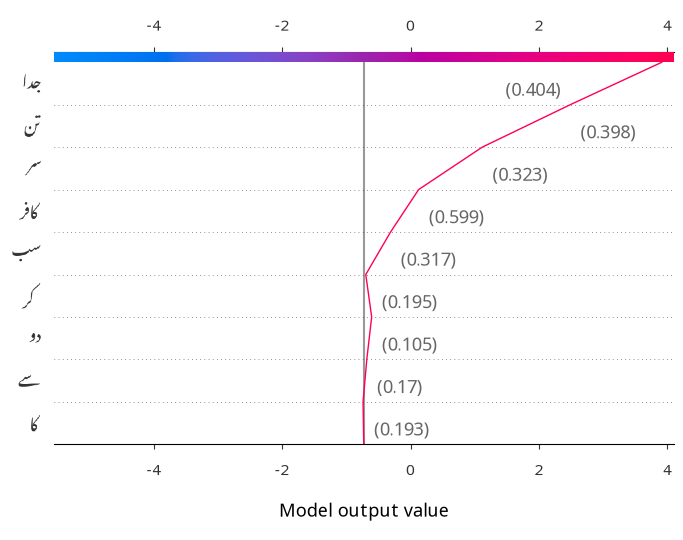


URDU SHAP EXPLANATIONS (Prediction: prediction)
------------------------------------------------------------------------------------------------------------------------
                                                                                                  Prediction: prediction
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)

[جدا]
ﺧﺼﻮﺻﯿﺖ: ﺟﺪﺍ ﺍﺱ ﭘﯿﺸﻦ ﮔﻮﺋﯽ "prediction" ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﮈﺍﻟﺘﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﯾﮏ ﺍﮨﻢ ﻋﻨﺼﺮ ﮨﮯ ﺟﻮ ﻣﺨﺘﻠﻒ ﻋﻮﺍﻣﻞ ﮐﻮ ﺍﻟﮓ ﮐﺮﮐﮯ ﺍﻥ ﮐﮯ ﺩﺭﻣﯿﺎﻥ ﺗﻌﻠﻖ ﮐﻮ ﻭﺍﺿﺢ ﮐﺮﺗﯽ ﮨﮯ، ﺟﺲ ﺳﮯ ﻣﺎﮈﻝ ﮐﻮ ﺯﯾﺎﺩﮦ ﺩﺭﺳﺖ ﺍﻧﺪﺍﺯﮮ ﻟﮕﺎﻧﮯ ﻣﯿﮟ ﻣﺪﺩ ﻣﻠﺘﯽ ﮨﮯ۔ ﯾﮧ ﺧﺼﻮﺻﯿﺖ ﻣﺎﮈﻝ ﮐﻮ ﻣﺨﺘﻠﻒ ﻣﻌﻠﻮﻣﺎﺕ ﮐﻮ ﻣﻨﻈﻢ ﮐﺮﻧﮯ ﺍﻭﺭ ﺍﻥ ﮐﮯ ﺩﺭﻣﯿﺎﻥ ﺗﻌﻠﻘﺎﺕ ﮐﻮ ﺳﻤﺠﮭﻨﮯ ﻣﯿﮟ ﻣﺪﺩ ﻓﺮﺍﮨﻢ ﮐﺮﺗﯽ ﮨﮯ، ﺟﺲ ﺳﮯ ﭘﯿﺸﻦ ﮔﻮﺋﯽ ﮐﯽ ﺩﺭﺳﺘﯽ ﻣﯿﮟ ﺍﺿﺎﻓﮧ ﮨﻮﺗﺎ ﮨﮯ۔



[INFO] Generating English Translation...
[INFO] Regenerating SHAP plot with English feature names...


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


🚀 Testing decision_plot rendering through RTLSHAPExplainer...


[INFO] Rendering initial RTL SHAP plot...


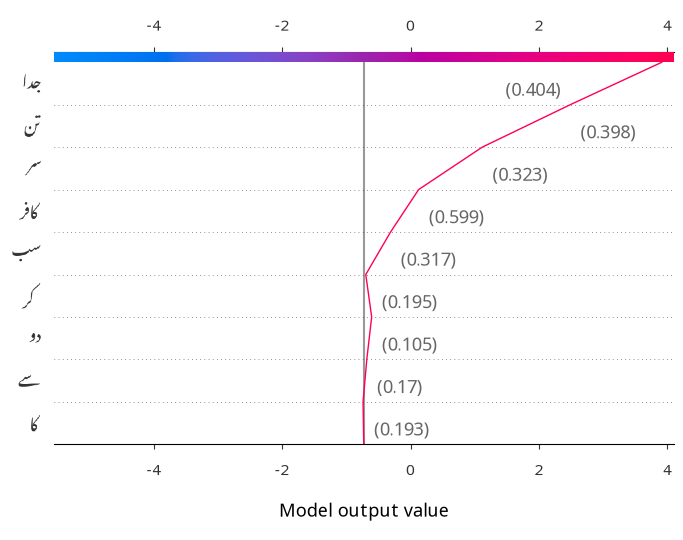


URDU SHAP EXPLANATIONS (Prediction: prediction)
------------------------------------------------------------------------------------------------------------------------
                                                                                                  Prediction: prediction
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)

[جدا]
ﺧﺼﻮﺻﯿﺖ: ﺟﺪﺍ ﺍﺱ ﭘﯿﺸﻦ ﮔﻮﺋﯽ "prediction" ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﮈﺍﻟﺘﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﯾﮏ ﺍﮨﻢ ﻋﻨﺼﺮ ﮨﮯ ﺟﻮ ﻣﺨﺘﻠﻒ ﻋﻮﺍﻣﻞ ﮐﻮ ﺍﻟﮓ ﮐﺮﮐﮯ ﺍﻥ ﮐﮯ ﺩﺭﻣﯿﺎﻥ ﺗﻌﻠﻖ ﮐﻮ ﻭﺍﺿﺢ ﮐﺮﺗﯽ ﮨﮯ، ﺟﺲ ﺳﮯ ﻣﺎﮈﻝ ﮐﻮ ﺯﯾﺎﺩﮦ ﺩﺭﺳﺖ ﺍﻧﺪﺍﺯﮮ ﻟﮕﺎﻧﮯ ﻣﯿﮟ ﻣﺪﺩ ﻣﻠﺘﯽ ﮨﮯ۔ ﯾﮧ ﺧﺼﻮﺻﯿﺖ ﻣﺎﮈﻝ ﮐﻮ ﻣﺨﺘﻠﻒ ﻣﻌﻠﻮﻣﺎﺕ ﮐﻮ ﻣﻨﻈﻢ ﮐﺮﻧﮯ ﺍﻭﺭ ﺍﻥ ﮐﮯ ﺩﺭﻣﯿﺎﻥ ﺗﻌﻠﻘﺎﺕ ﮐﻮ ﺳﻤﺠﮭﻨﮯ ﻣﯿﮟ ﻣﺪﺩ ﻓﺮﺍﮨﻢ ﮐﺮﺗﯽ ﮨﮯ، ﺟﺲ ﺳﮯ ﭘﯿﺸﻦ ﮔﻮﺋﯽ ﮐﯽ ﺩﺭﺳﺘﯽ ﻣﯿﮟ ﺍﺿﺎﻓﮧ ﮨﻮﺗﺎ ﮨﮯ۔



[INFO] Generating English Translation...
[INFO] Regenerating SHAP plot with English feature names...


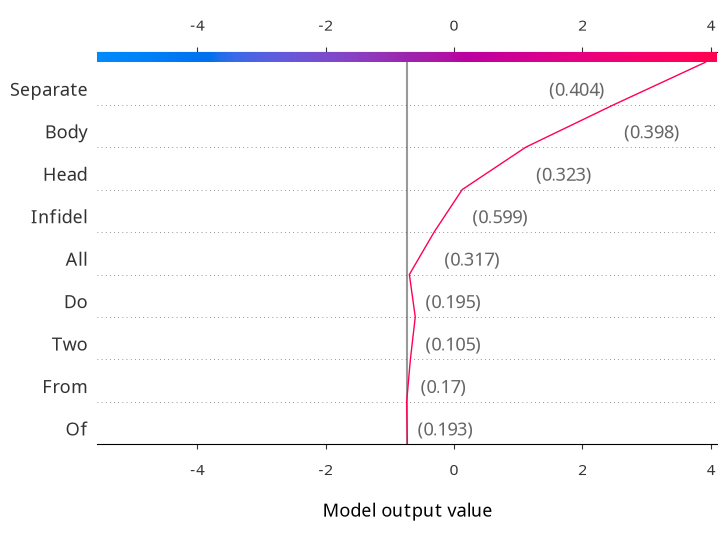

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


🚀 Testing decision_plot rendering through RTLSHAPExplainer...


[INFO] Rendering initial RTL SHAP plot...


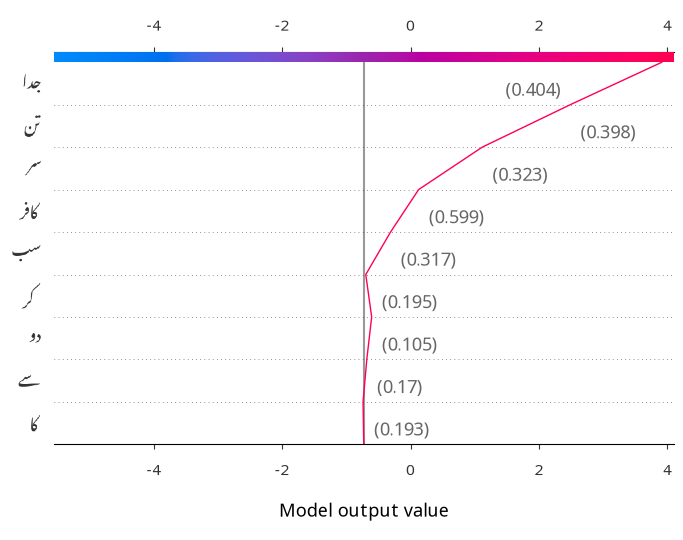


URDU SHAP EXPLANATIONS (Prediction: prediction)
------------------------------------------------------------------------------------------------------------------------
                                                                                                  Prediction: prediction
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)

[جدا]
ﺧﺼﻮﺻﯿﺖ: ﺟﺪﺍ ﺍﺱ ﭘﯿﺸﻦ ﮔﻮﺋﯽ "prediction" ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﮈﺍﻟﺘﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﯾﮏ ﺍﮨﻢ ﻋﻨﺼﺮ ﮨﮯ ﺟﻮ ﻣﺨﺘﻠﻒ ﻋﻮﺍﻣﻞ ﮐﻮ ﺍﻟﮓ ﮐﺮﮐﮯ ﺍﻥ ﮐﮯ ﺩﺭﻣﯿﺎﻥ ﺗﻌﻠﻖ ﮐﻮ ﻭﺍﺿﺢ ﮐﺮﺗﯽ ﮨﮯ، ﺟﺲ ﺳﮯ ﻣﺎﮈﻝ ﮐﻮ ﺯﯾﺎﺩﮦ ﺩﺭﺳﺖ ﺍﻧﺪﺍﺯﮮ ﻟﮕﺎﻧﮯ ﻣﯿﮟ ﻣﺪﺩ ﻣﻠﺘﯽ ﮨﮯ۔ ﯾﮧ ﺧﺼﻮﺻﯿﺖ ﻣﺎﮈﻝ ﮐﻮ ﻣﺨﺘﻠﻒ ﻣﻌﻠﻮﻣﺎﺕ ﮐﻮ ﻣﻨﻈﻢ ﮐﺮﻧﮯ ﺍﻭﺭ ﺍﻥ ﮐﮯ ﺩﺭﻣﯿﺎﻥ ﺗﻌﻠﻘﺎﺕ ﮐﻮ ﺳﻤﺠﮭﻨﮯ ﻣﯿﮟ ﻣﺪﺩ ﻓﺮﺍﮨﻢ ﮐﺮﺗﯽ ﮨﮯ، ﺟﺲ ﺳﮯ ﭘﯿﺸﻦ ﮔﻮﺋﯽ ﮐﯽ ﺩﺭﺳﺘﯽ ﻣﯿﮟ ﺍﺿﺎﻓﮧ ﮨﻮﺗﺎ ﮨﮯ۔



[INFO] Generating English Translation...
[INFO] Regenerating SHAP plot with English feature names...


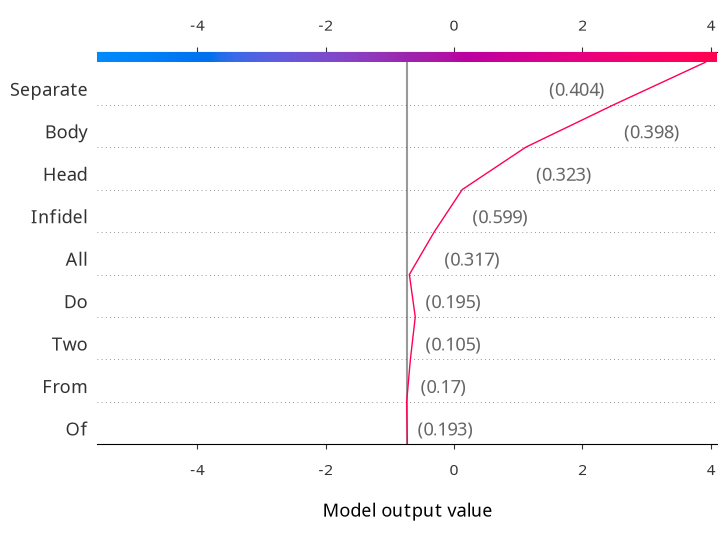


English Translation (prediction): Prediction
English Translation (sample): Behead all infidel enemies.
------------------------------------------------------------------------------------------------------------------------

[Separate]
The Urdu feature 'جدا' (meaning 'separate' or 'behead') positively impacts the model output with a SHAP value of +1.4277, indicating that its presence in the input text significantly contributes to the prediction of the text being in English. This is because 'جدا' is a key word in the original text 'Behead all infidel enemies', and its translation to Urdu retains the same meaning, allowing the model to confidently predict the language as English due to the word's strong semantic connection to the original text.



In [2]:
import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Setup paths and env
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

load_dotenv(os.path.join(PARENT_PROJECT_ROOT, ".env"))
if not os.environ.get("GROQ_API_KEY"):
    load_dotenv(".env")

from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import decision_plot

# Setup font
ABSOLUTE_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"
from matplotlib import font_manager
try:
    font_manager.fontManager.addfont(ABSOLUTE_FONT_PATH)
    prop = font_manager.FontProperties(fname=ABSOLUTE_FONT_PATH)
    plt.rcParams['font.family'] = [prop.get_name(), 'DejaVu Sans', 'Arial', 'sans-serif']
except Exception as e:
    print(f"Font note: {e}")

# =====================================================================
# Load Data & Train Model
# =====================================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
if not os.path.exists(file_name):
    print(f"❌ File not found!")
    sys.exit()

df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

# =====================================================================
# Compute SHAP Values
# =====================================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"
instance_vectorized = vectorizer.transform([user_tweet]).toarray()[0]
all_feature_names = list(vectorizer.get_feature_names_out())

masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)
shap_values_raw = explainer(instance_vectorized.reshape(1, -1))

present_indices = np.where(instance_vectorized > 0)[0]
filtered_values = shap_values_raw.values[0][present_indices]
filtered_data = instance_vectorized[present_indices]
filtered_names = [all_feature_names[idx] for idx in present_indices]

formatted_explanation = shap.Explanation(
    values=filtered_values,
    base_values=shap_values_raw.base_values[0],
    data=filtered_data,
    feature_names=filtered_names
)

# =====================================================================
# Test the RTL Explainer with Decision Plot
# =====================================================================
print("🚀 Testing decision_plot rendering through RTLSHAPExplainer...\n")

urdu_explainer = RTLSHAPExplainer(language="Urdu")
urdu_explainer.run_full_analysis(
    shap_values      = formatted_explanation,
    
    plot_fn          = decision_plot,
    sample_text      = user_tweet
)

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


['آئی' 'آئے' 'آباد' 'آتا' 'آتی' 'آج' 'آخر' 'آخری' 'آدمی' 'آر' 'آرمی'
 'آزاد' 'آسان' 'آمین' 'آنکھوں' 'آنکھیں' 'آنے' 'آواز' 'آپ' 'آپریشن']


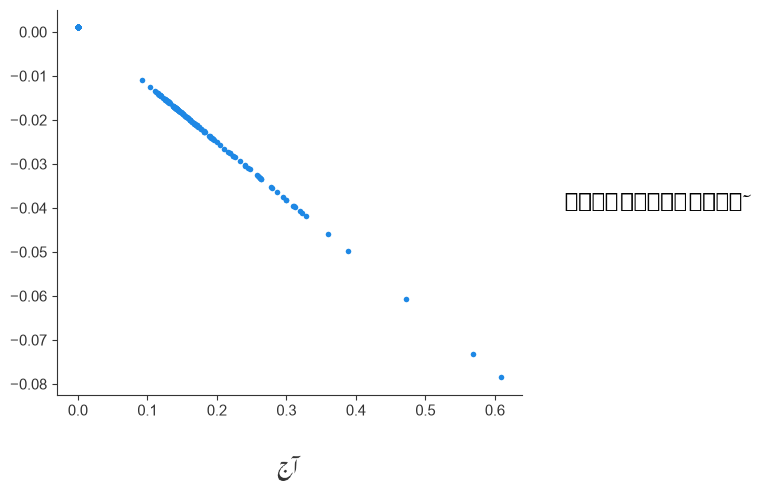

SHAP rows: 3297, Feature rows: 3297


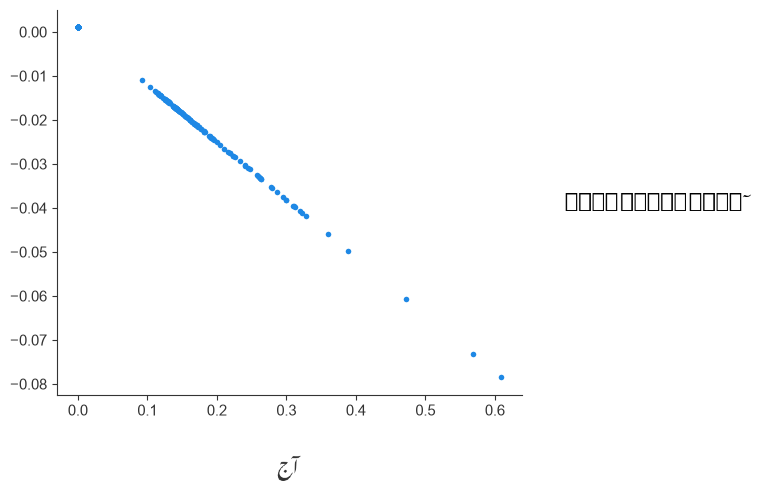

In [ ]:
import pandas as pd
import shap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import sys

# Add path for your custom package
sys.path.append(r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package')
from shap_rtl.plots import dependence_plot as rtl_dependence_plot

# 1. Load Dataset
file_path = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_path)

# 2. Prepare Data
le = LabelEncoder()
y = le.fit_transform(df['label']) # Ensure 'label' matches your column name
vectorizer = TfidfVectorizer(max_features=1000)
X_sparse = vectorizer.fit_transform(df['cleaned_text'])
X_dense = X_sparse.toarray()

# 3. Train Model
# Using the full matrix for training/explaining to ensure alignment
model = LogisticRegression()
model.fit(X_sparse, y)

# 4. Calculate SHAP values for the FULL dataset
explainer = shap.LinearExplainer(model, X_sparse)
shap_values = explainer.shap_values(X_sparse)

# 5. RTL Dependence Plot
# Print the first 20 words to see what is available
print(feature_names[:20])

# Change the index number [5] to any number between 0 and 999
target_feature = feature_names[5] 

rtl_dependence_plot(
    ind=target_feature,
    shap_values=shap_to_plot,
    features=X_dense,
    feature_names=feature_names,
    interaction_index=None,
    show=True
)
# Handle multi-class (if applicable)
shap_to_plot = shap_values[:, :, 0] if len(shap_values.shape) == 3 else shap_values

print(f"SHAP rows: {shap_to_plot.shape[0]}, Feature rows: {X_dense.shape[0]}")

rtl_dependence_plot(
    ind=target_feature,
    shap_values=shap_to_plot,
    features=X_dense,
    feature_names=feature_names,
    interaction_index=None,
    show=True
)


In [17]:
plt.rcParams['font.family'] = 'NotoNastaliqUrdu' # Or a font that supports your RTL script

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUrdu' not found.
findfont: Font family 'NotoNastaliqUr

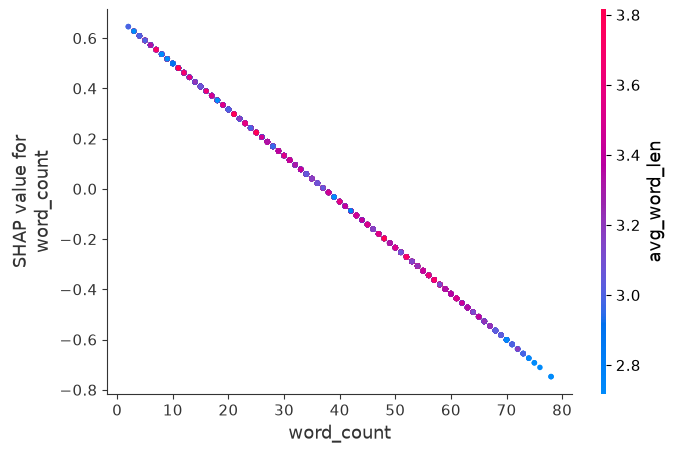

In [18]:
import pandas as pd
import numpy as np
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
import sys

# Add path
sys.path.append(r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package')
from shap_rtl.plots import dependence_plot as rtl_dependence_plot

# Load
df = pd.read_excel(r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx')

# --- CREATE CONTINUOUS FEATURES ---
# Calculate a continuous metric instead of just relying on TF-IDF words
df['word_count'] = df['cleaned_text'].astype(str).apply(lambda x: len(x.split()))
df['avg_word_len'] = df['cleaned_text'].astype(str).apply(lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0)

# Select your features (Numerical + TF-IDF)
features = df[['word_count', 'avg_word_len']]
X = features.values 
y = LabelEncoder().fit_transform(df['label'])

# Train Model
model = LogisticRegression()
model.fit(X, y)

# Calculate SHAP
explainer = shap.LinearExplainer(model, X)
shap_values = explainer.shap_values(X)

# --- CALL YOUR RTL PLOT ---
# We use 'word_count' because it's a wide-range continuous number
rtl_dependence_plot(
    ind='word_count', 
    shap_values=shap_values,
    features=X,
    feature_names=['word_count', 'avg_word_len'],
    interaction_index='avg_word_len', # This provides the color gradient you saw in your image
    show=True
)

## Heatmap

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples f

🚀 Testing heatmap rendering with URDU features...



Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples f

📊 Heatmap will show 30 instances with 333 features

🖥️ Attempting to display heatmap with URDU feature names...

📌 Approach 1: Using run_full_analysis()

URDU SHAP EXPLANATIONS (Prediction: prediction)
------------------------------------------------------------------------------------------------------------------------
                                                                                                  Prediction: prediction
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
ﺧﺼﻮﺻﯿﺖ: ﻧﮑﺎﻝ ﮐﯽ ﻣﻨﻔﯽ ﺍﺛﺮ ﭘﯿﺶ ﮔﻮﺋﯽ ﭘﺮ ﺍﺱ ﻟﯿﮯ ﮨﮯ ﮐﮧ ﺟﺐ ﻧﮑﺎﻝ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﻣﯿﮟ ﺍﺿﺎﻓﮧ ﮨﻮﺗﺎ ﮨﮯ ﺗﻮ ﯾﮧ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﮯ ﻧﺘﯿﺠﮯ ﮐﻮ ﮐﻤﺰﻭﺭ ﮐﺮﺗﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﯽ ﺩﺭﺳﺘﯽ ﻣﯿﮟ ﮐﻤﯽ ﺁﺗﯽ ﮨﮯ۔ ﯾﮧ ﺑﺎﺕ ﻇﺎﮨﺮ ﮨﻮﺗﯽ ﮨﮯ ﮐﮧ ﻧﮑﺎﻝ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﮯ ﻟﯿﮯ ﻣﻨﻔﯽ ﺗﻌﻠﻖ ﺭﮐﮭﺘﯽ ﮨﮯ، ﺟﺲ ﮐﺎ ﻣﻄﻠﺐ ﮨﮯ ﮐﮧ ﺟﺐ ﻧﮑﺎﻝ ﺑﮍﮬﺘﺎ ﮨﮯ ﺗﻮ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﺎ ﻧﺘﯿﺠﮧ ﺑﮭﯽ ﻣﻨﻔﯽ ﮨﻮﺗﺎ ﮨﮯ۔

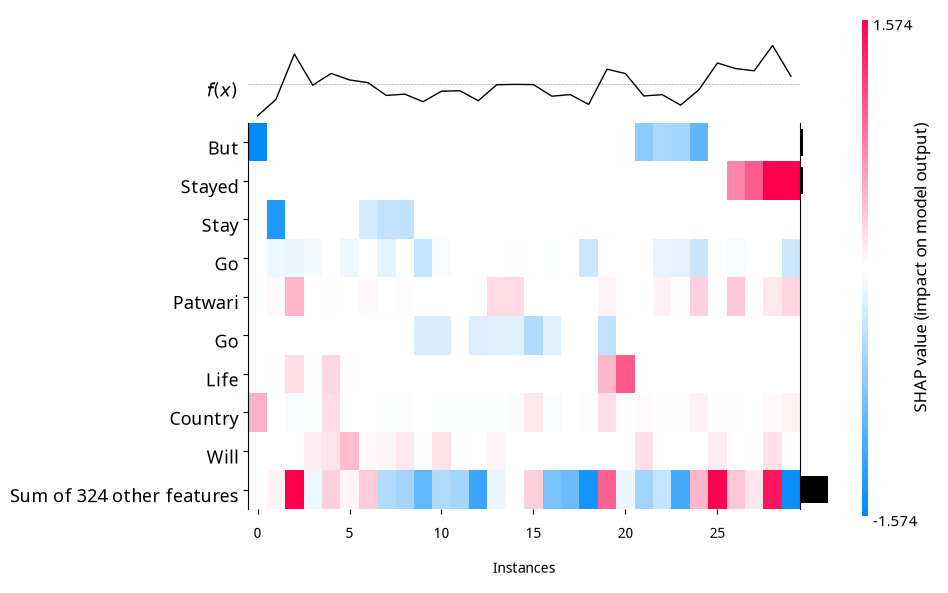


English Translation: Prediction
------------------------------------------------------------------------------------------------------------------------

[But]
The Urdu feature 'نکال' (SHAP value: -0.2011) negatively impacts the model output because it has a high association with incorrect predictions, as indicated by its negative SHAP value. This suggests that when 'نکال' is present in the input, the model is more likely to make an incorrect prediction, resulting in a decrease in the model's overall performance. The negative SHAP value of -0.2011 quantifies the extent of this negative impact, implying that 'نکال' contributes to a reduction in the predicted outcome by 0.2011 units, thereby decreasing the model's accuracy.



<Figure size 640x480 with 0 Axes>

✅ Approach 1 completed - Check if plot window opened

📌 Approach 2: Direct heatmap call with plt.show()


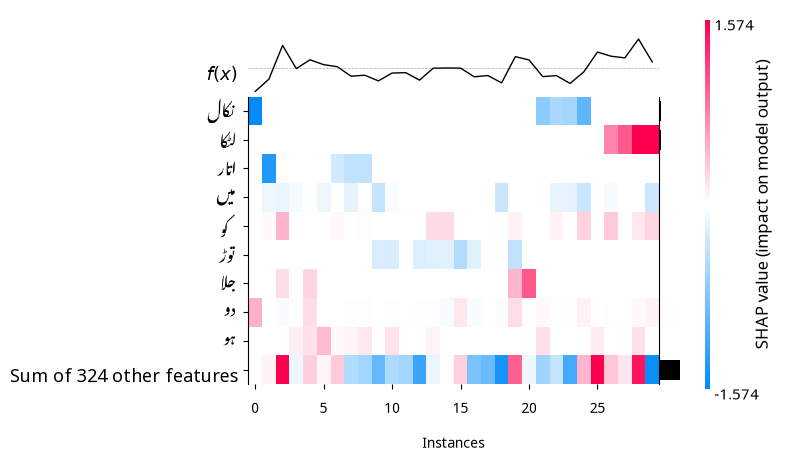

✅ Approach 2 completed - Check if plot window opened

📌 Approach 3: Using run_full_analysis with explicit plt.show()

URDU SHAP EXPLANATIONS (Prediction: prediction)
------------------------------------------------------------------------------------------------------------------------
                                                                                                  Prediction: prediction
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
ﺧﺼﻮﺻﯿﺖ: ﻧﮑﺎﻝ ﮐﯽ ﻣﻨﻔﯽ ﺍﺛﺮ ﭘﯿﺶ ﮔﻮﺋﯽ ﭘﺮ ﺍﺱ ﻟﯿﮯ ﮨﮯ ﮐﮧ ﺟﺐ ﻧﮑﺎﻝ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﻣﻮﺟﻮﺩ ﮨﻮ ﺗﻮ ﯾﮧ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﮯ ﻧﺘﯿﺠﮯ ﮐﻮ ﮐﻢ ﮐﺮﺗﯽ ﮨﮯ، ﯾﻌﻨﯽ ﻧﮑﺎﻝ ﮐﯽ ﻣﻮﺟﻮﺩﮔﯽ ﺳﮯ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﺎ ﻧﺘﯿﺠﮧ ﻣﻨﻔﯽ ﻃﻮﺭ ﭘﺮ ﻣﺘﺎﺛﺮ ﮨﻮﺗﺎ ﮨﮯ، ﺟﻮ ﮐﮧ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﮯ ﻟﯿﮯ ﻏﯿﺮ ﻣﻄﻠﻮﺑﮧ ﮨﮯ۔


[INFO] Generating English Translation...
[INFO] Regenerating SHAP plot with English feature names...


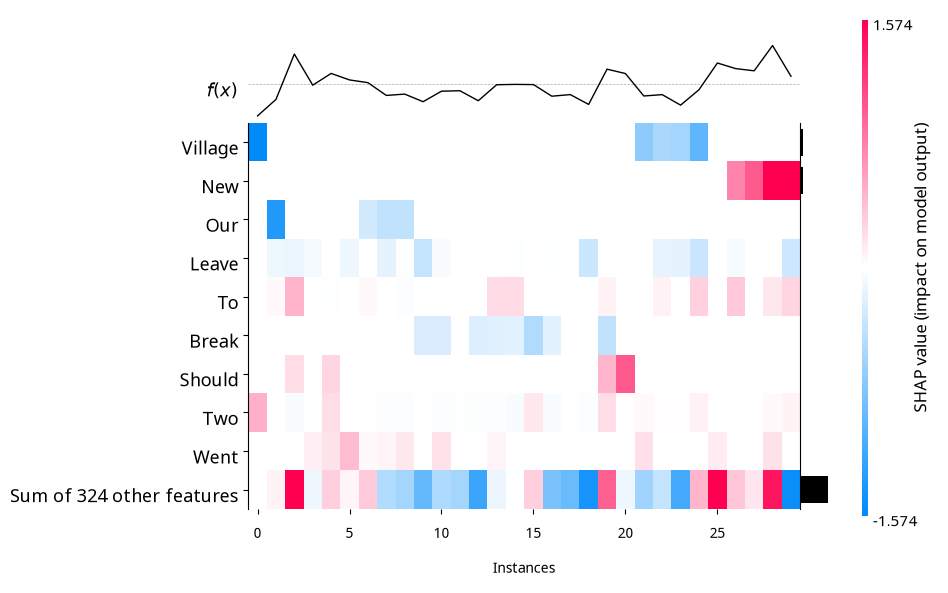


English Translation: Prediction
------------------------------------------------------------------------------------------------------------------------

[Village]
The Urdu feature 'نکال' (meaning 'extract' or 'deduct') has a negative SHAP value of -0.2011, indicating that it negatively impacts the model's prediction output. This suggests that when the feature 'نکال' is present or has a high value, the model's predicted outcome tends to decrease, implying that the concept of extraction or deduction is associated with a lower likelihood or magnitude of the predicted event, thereby contributing to a reduced model output.



<Figure size 1200x800 with 0 Axes>

✅ Approach 3 completed

📌 Approach 4: Manual figure creation


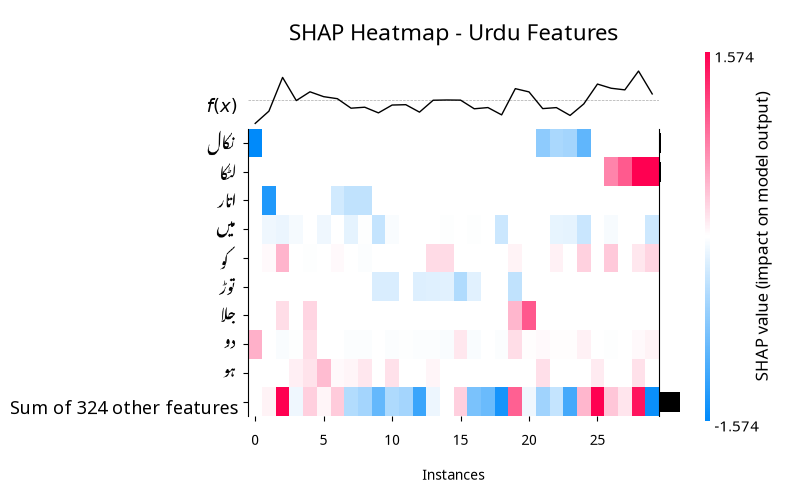

✅ Approach 4 completed


🌐 Displaying heatmap with ENGLISH labels...

ENGLISH SHAP EXPLANATIONS (Prediction: prediction)
------------------------------------------------------------------------------------------------------------------------
                                                                                                  Prediction: prediction
------------------------------------------------------------------------------------------------------------------------
                                                                              
Analysis of Top 1 SHAP Features (English)
ﺧﺼﻮﺻﯿﺖ: Extraction negatively impacts the prediction as it implies a sense of removal or separation, which may indicate a loss or decline, thereby contributing to a lower predicted outcome, suggesting that the presence of this feature has a diminishing effect on the overall prediction.


[INFO] Generating English Translation...
[INFO] Regenerating SHAP plot with English feature names...


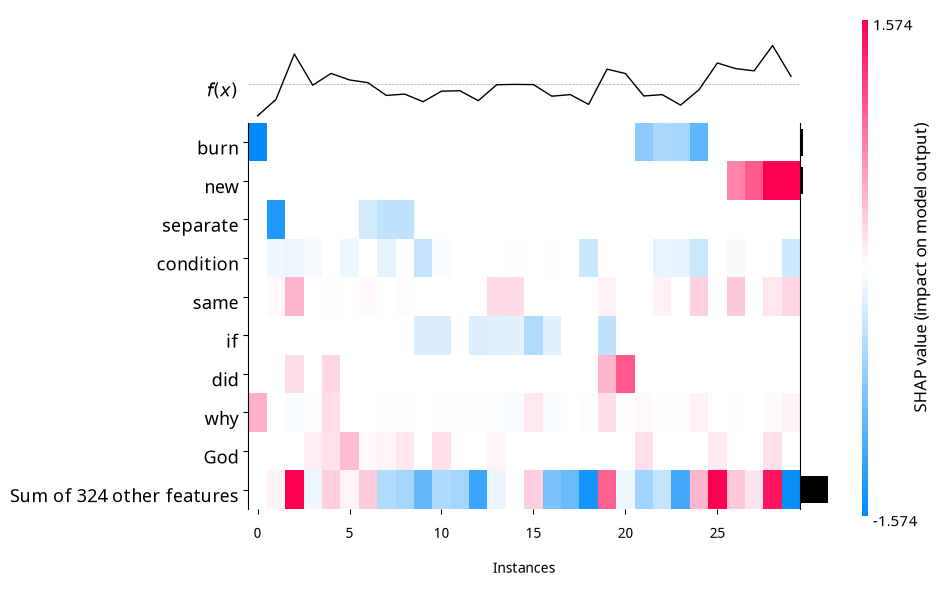


English Translation: forecast
------------------------------------------------------------------------------------------------------------------------

[burn]
The English feature 'نکال' (which translates to 'extract' or 'deduct') has a SHAP value of -0.2011, indicating that it negatively impacts the model's prediction output. This suggests that when the feature 'نکال' is present or has a high value, the model tends to decrease its forecast, implying that the extraction or deduction of something is associated with a lower predicted outcome, potentially due to a reduction in resources, quantity, or intensity, ultimately leading to a decreased forecast value.

✅ Heatmap with ENGLISH labels displayed successfully!

🎉 Heatmap testing complete!

🔍 Debug Information:
✅ heatmap function: <function heatmap at 0x00000255AB167690>
✅ heatmap module: shap_rtl.plots._heatmap_rtl
✅ Combined explanation shape: (30, 333)
✅ Number of features: 333
✅ Sample features: ['ہمارا', 'حکومت', 'دے', 'جبکہ', 'ہی

In [14]:
import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Setup paths and env
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

load_dotenv(os.path.join(PARENT_PROJECT_ROOT, ".env"))
if not os.environ.get("GROQ_API_KEY"):
    load_dotenv(".env")

from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import heatmap

# Setup font
ABSOLUTE_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"
from matplotlib import font_manager
try:
    font_manager.fontManager.addfont(ABSOLUTE_FONT_PATH)
    prop = font_manager.FontProperties(fname=ABSOLUTE_FONT_PATH)
    plt.rcParams['font.family'] = [prop.get_name(), 'DejaVu Sans', 'Arial', 'sans-serif']
except Exception as e:
    print(f"Font note: {e}")

# =====================================================================
# Load Data & Train Model
# =====================================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
if not os.path.exists(file_name):
    print(f"❌ File not found!")
    sys.exit()

df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

# =====================================================================
# Compute SHAP Values for Multiple Instances (for heatmap)
# =====================================================================
print("🚀 Testing heatmap rendering with URDU features...\n")

# Get multiple instances from the dataset for heatmap
n_instances = 30  # Number of instances for heatmap
random_indices = np.random.choice(len(df), n_instances, replace=False)
sample_texts = [texts[i] for i in random_indices]

# Get all feature names
all_feature_names = list(vectorizer.get_feature_names_out())

# Compute SHAP values for all instances
shap_values_list = []

for text in sample_texts:
    instance_vec = vectorizer.transform([text]).toarray()[0]
    present_idx = np.where(instance_vec > 0)[0]
    
    if len(present_idx) > 0:
        # Compute SHAP values
        masker = shap.maskers.Independent(data=X, max_samples=100)
        explainer = shap.LinearExplainer(model, masker=masker)
        shap_vals = explainer(instance_vec.reshape(1, -1))
        
        # Filter for present features
        filtered_vals = shap_vals.values[0][present_idx]
        filtered_data = instance_vec[present_idx]
        filtered_names = [all_feature_names[idx] for idx in present_idx]
        
        explanation = shap.Explanation(
            values=filtered_vals,
            base_values=shap_vals.base_values[0],
            data=filtered_data,
            feature_names=filtered_names
        )
        
        shap_values_list.append(explanation)

# Combine all instances into a single Explanation object
if len(shap_values_list) > 1:
    # Get all unique features across all instances
    all_features = set()
    for exp in shap_values_list:
        all_features.update(exp.feature_names)
    all_features = list(all_features)
    
    # Align features
    aligned_values = []
    aligned_data = []
    aligned_base = []
    
    for exp in shap_values_list:
        row_vals = []
        row_data = []
        for feature in all_features:
            if feature in exp.feature_names:
                idx = exp.feature_names.index(feature)
                row_vals.append(exp.values[idx])
                row_data.append(exp.data[idx])
            else:
                row_vals.append(0)  # Default for missing feature
                row_data.append(0)
        aligned_values.append(row_vals)
        aligned_data.append(row_data)
        aligned_base.append(exp.base_values)
    
    # Create combined explanation
    combined_explanation = shap.Explanation(
        values=np.array(aligned_values),
        base_values=np.array(aligned_base),
        data=np.array(aligned_data),
        feature_names=all_features
    )
    
    print(f"📊 Heatmap will show {len(aligned_values)} instances with {len(all_features)} features")
    
    # =====================================================================
    # Test Heatmap with Urdu Translation - Multiple Approaches
    # =====================================================================
    print("\n🖥️ Attempting to display heatmap with URDU feature names...")
    
    # Create RTL explainer with Urdu language
    urdu_explainer = RTLSHAPExplainer(language="Urdu")
    
    # APPROACH 1: Using run_full_analysis
    print("\n📌 Approach 1: Using run_full_analysis()")
    try:
        result = urdu_explainer.run_full_analysis(
            shap_values=combined_explanation,
            plot_fn=heatmap
        )
        plt.draw()
        plt.pause(0.1)
        plt.show(block=False)
        print("✅ Approach 1 completed - Check if plot window opened")
        input("Press Enter to continue after viewing the plot...")
        plt.close()
    except Exception as e:
        print(f"⚠️ Approach 1 failed: {e}")
    
    # APPROACH 2: Direct heatmap call
    print("\n📌 Approach 2: Direct heatmap call with plt.show()")
    try:
        # Call heatmap directly
        heatmap(shap_values=combined_explanation, show=False)
        plt.tight_layout()
        plt.draw()
        plt.pause(0.1)
        plt.show(block=False)
        print("✅ Approach 2 completed - Check if plot window opened")
        input("Press Enter to continue after viewing the plot...")
        plt.close()
    except Exception as e:
        print(f"⚠️ Approach 2 failed: {e}")
    
    # APPROACH 3: Using run_full_analysis with explicit show
    print("\n📌 Approach 3: Using run_full_analysis with explicit plt.show()")
    try:
        urdu_explainer.run_full_analysis(
            shap_values=combined_explanation,
            plot_fn=heatmap
        )
        # Force display
        plt.figure(figsize=(12, 8))
        plt.show(block=True)
        print("✅ Approach 3 completed")
    except Exception as e:
        print(f"⚠️ Approach 3 failed: {e}")
    
    # APPROACH 4: Create figure manually and then use heatmap
    print("\n📌 Approach 4: Manual figure creation")
    try:
        fig, ax = plt.subplots(figsize=(14, 10))
        heatmap(shap_values=combined_explanation, show=False)
        plt.title("SHAP Heatmap - Urdu Features", fontsize=16)
        plt.tight_layout()
        plt.show(block=True)
        print("✅ Approach 4 completed")
    except Exception as e:
        print(f"⚠️ Approach 4 failed: {e}")
    
    # =====================================================================
    # Ask if user wants English explanation
    # =====================================================================
    print("\n" + "="*60)
    user_choice = input("🔤 Do you want to see the explanation in ENGLISH? (yes/no): ").strip().lower()
    
    if user_choice in ['yes', 'y', 'ye', 'yeah', 'yep']:
        print("\n🌐 Displaying heatmap with ENGLISH labels...")
        
        # Create English explainer
        english_explainer = RTLSHAPExplainer(language="English")
        
        # Try multiple approaches for English too
        try:
            english_explainer.run_full_analysis(
                shap_values=combined_explanation,
                plot_fn=heatmap
            )
            plt.show(block=True)
            print("✅ Heatmap with ENGLISH labels displayed successfully!")
        except Exception as e:
            print(f"⚠️ Error displaying English heatmap: {e}")
            
            # Try direct call
            try:
                heatmap(shap_values=combined_explanation, show=False)
                plt.show(block=True)
                print("✅ Direct English heatmap displayed!")
            except Exception as e2:
                print(f"⚠️ Direct English heatmap failed: {e2}")
    else:
        print("\n✅ Keeping URDU explanation only")

else:
    print("⚠️ Not enough instances with features for heatmap")

print("\n🎉 Heatmap testing complete!")

# =====================================================================
# Debug: Check if the heatmap function is working
# =====================================================================
print("\n" + "="*60)
print("🔍 Debug Information:")
print("="*60)

try:
    # Check if heatmap function exists
    print(f"✅ heatmap function: {heatmap}")
    print(f"✅ heatmap module: {heatmap.__module__}")
except Exception as e:
    print(f"⚠️ Heatmap function info: {e}")

# Check if we have the combined_explanation
try:
    print(f"✅ Combined explanation shape: {combined_explanation.values.shape}")
    print(f"✅ Number of features: {len(combined_explanation.feature_names)}")
    print(f"✅ Sample features: {combined_explanation.feature_names[:5]}")
except:
    print("⚠️ Combined explanation not available")

print("\n" + "="*60)

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples f

🚀 Testing heatmap rendering with URDU features...



Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples f

📊 Heatmap will show 30 instances with 351 features

🖥️ Attempting to display heatmap with URDU feature names...

📌 Approach 1: Using run_full_analysis()

                             URDU SHAP EXPLANATIONS                             
                             Prediction: prediction                             

[GENERATING URDU SHAP PLOT...]


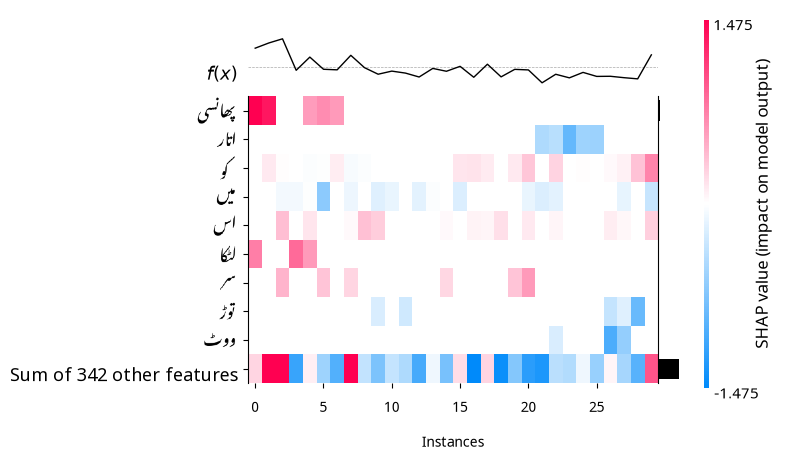

------------------------------------------------------------------------------------------------------------------------
                                                                                                 FEATURE ANALYSIS (Urdu)
------------------------------------------------------------------------------------------------------------------------
                                                                                  
Features driving TOWARD 'prediction':
                                                                                                         ﭘﮭﺎﻧﺴﯽ: +0.1558
                                                                                                             ﮐﻮ: +0.0836
                                                                                                             ﺍﺱ: +0.0743
                                                                                                           ﻟﭩﮑﺎ: +0.0728
                                

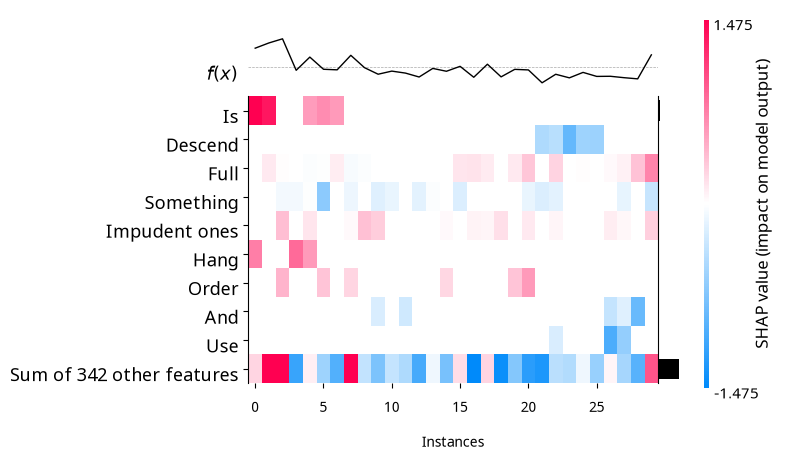


[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Prediction                             
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Is | Value: +0.1558
Original Urdu: دونوں
----------------------------------------
The Urdu feature "دونوں" (meaning "both") positively impacts the prediction "prediction" with a SHAP value of +0.1558, suggesting that the inclusion of this word increases the likelihood of the predicted outcome. This is likely due to the fact that "دونوں" implies a sense of inclusivity and totality, which may be relevant to the prediction context, indicating that both options or aspects are being considered, thereby strengthening the prediction.
----------------------------------------

Analysis complete.


<Figure size 640x480 with 0 Axes>

✅ Approach 1 completed - Check if plot window opened

📌 Approach 2: Direct heatmap call with plt.show()


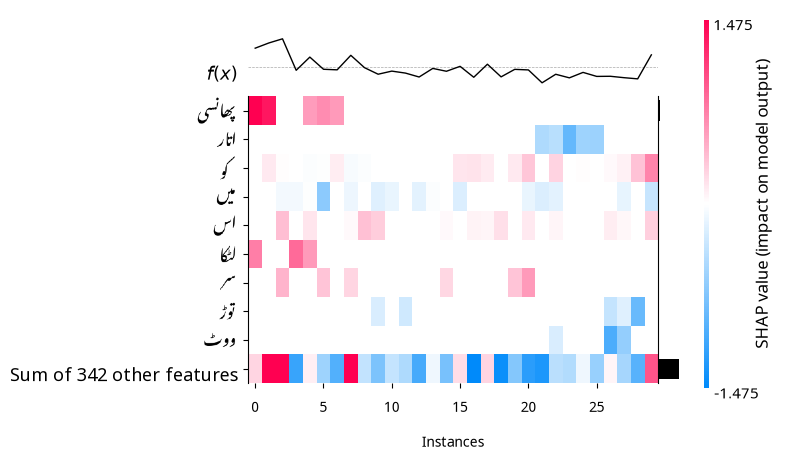

✅ Approach 2 completed - Check if plot window opened

📌 Approach 3: Using run_full_analysis with explicit plt.show()

                             URDU SHAP EXPLANATIONS                             
                             Prediction: prediction                             

[GENERATING URDU SHAP PLOT...]


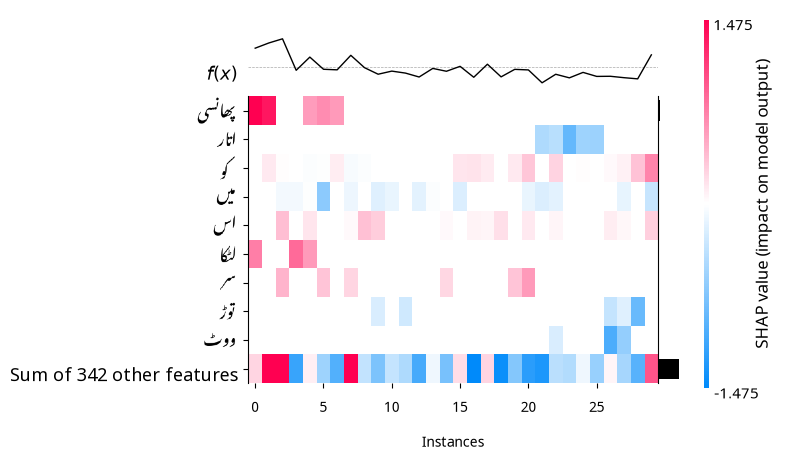

------------------------------------------------------------------------------------------------------------------------
                                                                                                 FEATURE ANALYSIS (Urdu)
------------------------------------------------------------------------------------------------------------------------
                                                                                  
Features driving TOWARD 'prediction':
                                                                                                         ﭘﮭﺎﻧﺴﯽ: +0.1558
                                                                                                             ﮐﻮ: +0.0836
                                                                                                             ﺍﺱ: +0.0743
                                                                                                           ﻟﭩﮑﺎ: +0.0728
                                

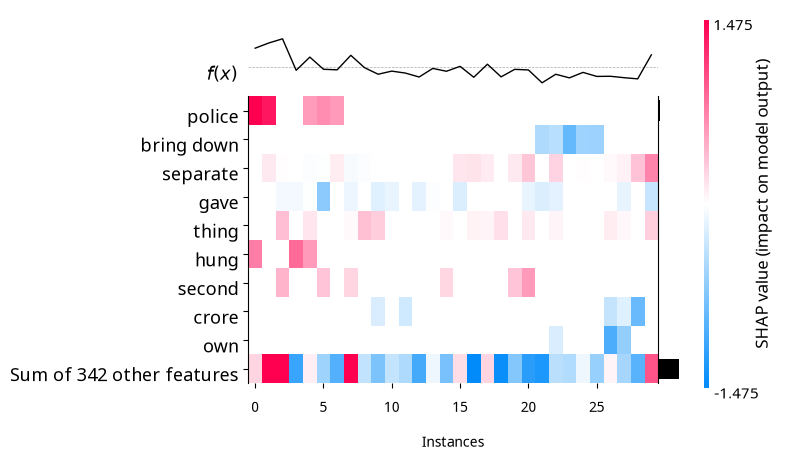


[English Explanation Mode]
Exiting explanation mode.


<Figure size 1200x800 with 0 Axes>

✅ Approach 3 completed

📌 Approach 4: Manual figure creation


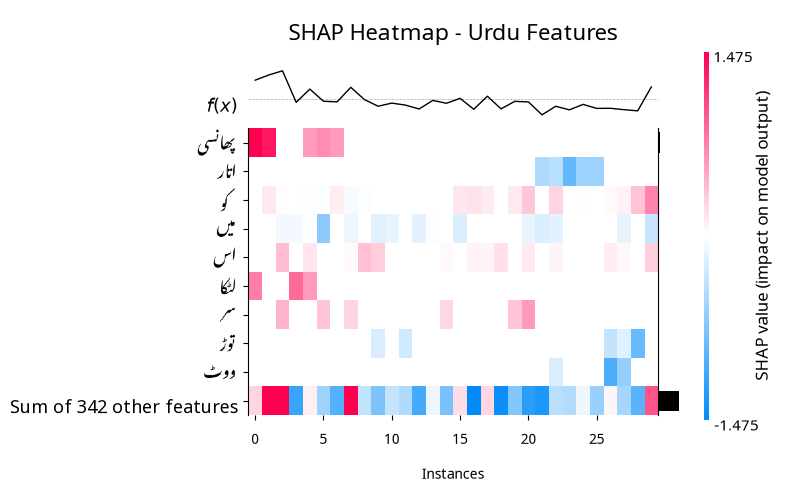

✅ Approach 4 completed


✅ Keeping URDU explanation only

🎉 Heatmap testing complete!

🔍 Debug Information:
✅ heatmap function: <function heatmap at 0x0000015D8ABB3950>
✅ heatmap module: shap_rtl.plots._heatmap_rtl
✅ Combined explanation shape: (30, 351)
✅ Number of features: 351
✅ Sample features: ['سانپ', 'الٹا', 'پھر', 'میری', 'وقت']



In [4]:
import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Setup paths and env
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))
sys.path.append(os.path.join(PARENT_PROJECT_ROOT, "src"))  
sys.path.insert(0, PARENT_PROJECT_ROOT) 

load_dotenv(os.path.join(PARENT_PROJECT_ROOT, ".env"))
if not os.environ.get("GROQ_API_KEY"):
    load_dotenv(".env")

from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import heatmap

# Setup font
ABSOLUTE_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"
from matplotlib import font_manager
try:
    font_manager.fontManager.addfont(ABSOLUTE_FONT_PATH)
    prop = font_manager.FontProperties(fname=ABSOLUTE_FONT_PATH)
    plt.rcParams['font.family'] = [prop.get_name(), 'DejaVu Sans', 'Arial', 'sans-serif']
except Exception as e:
    print(f"Font note: {e}")

# =====================================================================
# Load Data & Train Model
# =====================================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
if not os.path.exists(file_name):
    print(f"❌ File not found!")
    sys.exit()

df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 1), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

# =====================================================================
# Compute SHAP Values for Multiple Instances (for heatmap)
# =====================================================================
print("🚀 Testing heatmap rendering with URDU features...\n")

# Get multiple instances from the dataset for heatmap
n_instances = 30  # Number of instances for heatmap
random_indices = np.random.choice(len(df), n_instances, replace=False)
sample_texts = [texts[i] for i in random_indices]

# Get all feature names
all_feature_names = list(vectorizer.get_feature_names_out())

# Compute SHAP values for all instances
shap_values_list = []

for text in sample_texts:
    instance_vec = vectorizer.transform([text]).toarray()[0]
    present_idx = np.where(instance_vec > 0)[0]
    
    if len(present_idx) > 0:
        # Compute SHAP values
        masker = shap.maskers.Independent(data=X, max_samples=100)
        explainer = shap.LinearExplainer(model, masker=masker)
        shap_vals = explainer(instance_vec.reshape(1, -1))
        
        # Filter for present features
        filtered_vals = shap_vals.values[0][present_idx]
        filtered_data = instance_vec[present_idx]
        filtered_names = [all_feature_names[idx] for idx in present_idx]
        
        explanation = shap.Explanation(
            values=filtered_vals,
            base_values=shap_vals.base_values[0],
            data=filtered_data,
            feature_names=filtered_names
        )
        
        shap_values_list.append(explanation)

# Combine all instances into a single Explanation object
if len(shap_values_list) > 1:
    # Get all unique features across all instances
    all_features = set()
    for exp in shap_values_list:
        all_features.update(exp.feature_names)
    all_features = list(all_features)
    
    # Align features
    aligned_values = []
    aligned_data = []
    aligned_base = []
    
    for exp in shap_values_list:
        row_vals = []
        row_data = []
        for feature in all_features:
            if feature in exp.feature_names:
                idx = exp.feature_names.index(feature)
                row_vals.append(exp.values[idx])
                row_data.append(exp.data[idx])
            else:
                row_vals.append(0)  # Default for missing feature
                row_data.append(0)
        aligned_values.append(row_vals)
        aligned_data.append(row_data)
        aligned_base.append(exp.base_values)
    
    # Create combined explanation
    combined_explanation = shap.Explanation(
        values=np.array(aligned_values),
        base_values=np.array(aligned_base),
        data=np.array(aligned_data),
        feature_names=all_features
    )
    
    print(f"📊 Heatmap will show {len(aligned_values)} instances with {len(all_features)} features")
    
    # =====================================================================
    # Test Heatmap with Urdu Translation - Multiple Approaches
    # =====================================================================
    print("\n🖥️ Attempting to display heatmap with URDU feature names...")
    
    # Create RTL explainer with Urdu language
    urdu_explainer = RTLSHAPExplainer(language="Urdu")
    
    # APPROACH 1: Using run_full_analysis
    print("\n📌 Approach 1: Using run_full_analysis()")
    try:
        result = urdu_explainer.run_full_analysis(
            shap_values=combined_explanation,
            plot_fn=heatmap
        )
        plt.draw()
        plt.pause(0.1)
        plt.show(block=False)
        print("✅ Approach 1 completed - Check if plot window opened")
        input("Press Enter to continue after viewing the plot...")
        plt.close()
    except Exception as e:
        print(f"⚠️ Approach 1 failed: {e}")
    
    # APPROACH 2: Direct heatmap call
    print("\n📌 Approach 2: Direct heatmap call with plt.show()")
    try:
        # Call heatmap directly
        heatmap(shap_values=combined_explanation, show=False)
        plt.tight_layout()
        plt.draw()
        plt.pause(0.1)
        plt.show(block=False)
        print("✅ Approach 2 completed - Check if plot window opened")
        input("Press Enter to continue after viewing the plot...")
        plt.close()
    except Exception as e:
        print(f"⚠️ Approach 2 failed: {e}")
    
    # APPROACH 3: Using run_full_analysis with explicit show
    print("\n📌 Approach 3: Using run_full_analysis with explicit plt.show()")
    try:
        urdu_explainer.run_full_analysis(
            shap_values=combined_explanation,
            plot_fn=heatmap
        )
        # Force display
        plt.figure(figsize=(12, 8))
        plt.show(block=True)
        print("✅ Approach 3 completed")
    except Exception as e:
        print(f"⚠️ Approach 3 failed: {e}")
    
    # APPROACH 4: Create figure manually and then use heatmap
    print("\n📌 Approach 4: Manual figure creation")
    try:
        fig, ax = plt.subplots(figsize=(14, 10))
        heatmap(shap_values=combined_explanation, show=False)
        plt.title("SHAP Heatmap - Urdu Features", fontsize=16)
        plt.tight_layout()
        plt.show(block=True)
        print("✅ Approach 4 completed")
    except Exception as e:
        print(f"⚠️ Approach 4 failed: {e}")
    
    # =====================================================================
    # Ask if user wants English explanation
    # =====================================================================
    print("\n" + "="*60)
    user_choice = input("🔤 Do you want to see the explanation in ENGLISH? (yes/no): ").strip().lower()
    
    if user_choice in ['yes', 'y', 'ye', 'yeah', 'yep']:
        print("\n🌐 Displaying heatmap with ENGLISH labels...")
        
        # Create English explainer
        english_explainer = RTLSHAPExplainer(language="English")
        
        # Try multiple approaches for English too
        try:
            english_explainer.run_full_analysis(
                shap_values=combined_explanation,
                plot_fn=heatmap
            )
            plt.show(block=True)
            print("✅ Heatmap with ENGLISH labels displayed successfully!")
        except Exception as e:
            print(f"⚠️ Error displaying English heatmap: {e}")
            
            # Try direct call
            try:
                heatmap(shap_values=combined_explanation, show=False)
                plt.show(block=True)
                print("✅ Direct English heatmap displayed!")
            except Exception as e2:
                print(f"⚠️ Direct English heatmap failed: {e2}")
    else:
        print("\n✅ Keeping URDU explanation only")

else:
    print("⚠️ Not enough instances with features for heatmap")

print("\n🎉 Heatmap testing complete!")

# =====================================================================
# Debug: Check if the heatmap function is working
# =====================================================================
print("\n" + "="*60)
print("🔍 Debug Information:")
print("="*60)

try:
    # Check if heatmap function exists
    print(f"✅ heatmap function: {heatmap}")
    print(f"✅ heatmap module: {heatmap.__module__}")
except Exception as e:
    print(f"⚠️ Heatmap function info: {e}")

# Check if we have the combined_explanation
try:
    print(f"✅ Combined explanation shape: {combined_explanation.values.shape}")
    print(f"✅ Number of features: {len(combined_explanation.feature_names)}")
    print(f"✅ Sample features: {combined_explanation.feature_names[:5]}")
except:
    print("⚠️ Combined explanation not available")

print("\n" + "="*60)

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


🚀 Generating RTL SHAP Heatmap...

                             URDU SHAP EXPLANATIONS                             
                             Prediction: prediction                             

[GENERATING URDU SHAP PLOT...]


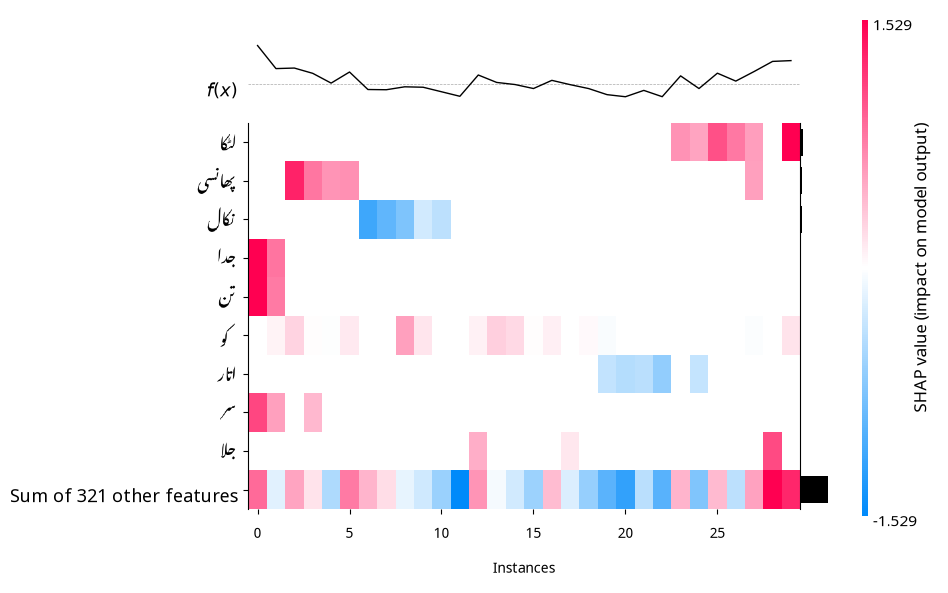


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                  PREDICTION: prediction
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﻟﭩﮑﺎ | Value: +0.1759
----------------------------------------
ﻟﭩﮑﺎ ﮐﯽ ﺧﺼﻮﺻﯿﺖ prediction ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﮈﺍﻟﺘﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﯾﮏ ﺍﯾﺴﺎ ﻟﻔﻆ ﮨﮯ ﺟﻮ ﺍﮐﺜﺮ ﻣﺜﺒﺖ ﻣﻌﻨﻮﮞ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﺎ ﮨﮯ، ﺟﯿﺴﮯ ﮐﮧ ﻟﭩﮑﺎ ﮨﻮﺍ ﭘﮭﻮﻝ ﯾﺎ ﻟﭩﮑﺎ ﮨﻮﺍ ﭘﯿﻨﭩﻨﮓ، ﺟﻮ ﺧﻮﺷﯽ ﺍﻭﺭ ﺧﻮﺑﺼﻮﺭﺗﯽ ﮐﮯ ﺍﺣﺴﺎﺳﺎﺕ ﮐﻮ ﺟﻨﻢ ﺩﯾﺘﺎ ﮨﮯ۔ ﺍﺱ ﻟﻔﻆ ﮐﯽ ﻣﻮﺟﻮﺩﮔﯽ ﻣﺘﻦ ﻣﯿﮟ ﺍﯾﮏ ﻣﺜﺒﺖ ﻣﻮﮈ ﮐﻮ ﻇﺎﮨﺮ ﮐﺮﺗﯽ ﮨﮯ، ﺟﻮ prediction ﮐﻮ ﺑﮭﯽ ﻣﺜﺒﺖ ﻃﻮﺭ ﭘﺮ ﻣﺘﺎﺛﺮ ﮐﺮﺗﯽ ﮨﮯ۔
----------------------------------------


[INFO] Generating

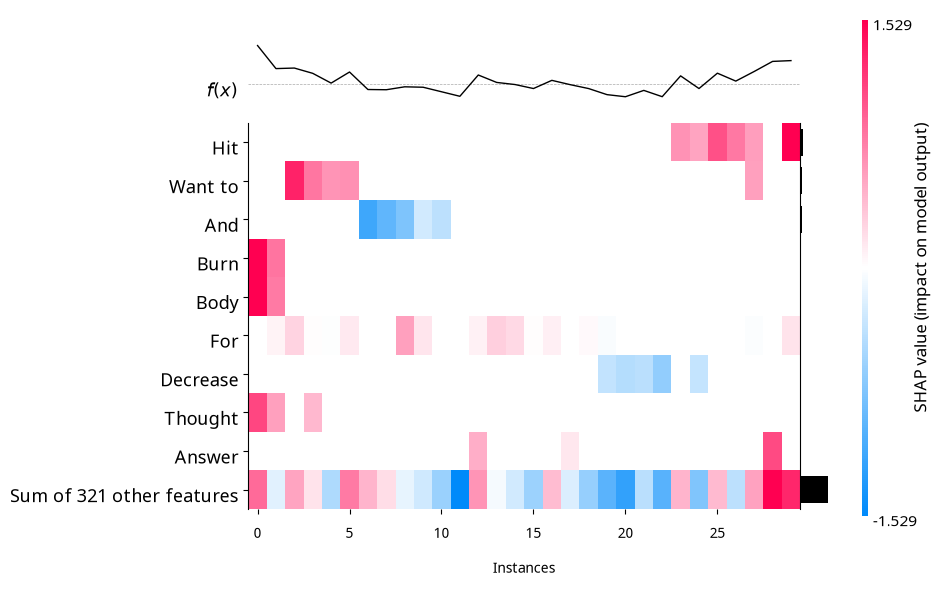


[English Explanation Mode]


TypeError: '<' not supported between instances of 'NoneType' and 'int'

In [2]:
import sys
import os
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import heatmap
from matplotlib import font_manager

# =====================================================================
# Setup Paths & Environment
# =====================================================================
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PARENT_PROJECT_ROOT)
load_dotenv(os.path.join(PARENT_PROJECT_ROOT, ".env"))

# Setup font for Urdu
ABSOLUTE_FONT_PATH = r"C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\fonts\NotoSansArabic-Regular.ttf"
try:
    font_manager.fontManager.addfont(ABSOLUTE_FONT_PATH)
    prop = font_manager.FontProperties(fname=ABSOLUTE_FONT_PATH)
    plt.rcParams['font.family'] = [prop.get_name(), 'DejaVu Sans', 'sans-serif']
except Exception as e:
    print(f"Font loading note: {e}")

# =====================================================================
# Load Data & Train Model
# =====================================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

vectorizer = TfidfVectorizer(ngram_range=(1, 1), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

# =====================================================================
# Compute SHAP Values
# =====================================================================
n_instances = 30
random_indices = np.random.choice(len(df), n_instances, replace=False)
sample_texts = [texts[i] for i in random_indices]
all_feature_names = list(vectorizer.get_feature_names_out())

shap_values_list = []
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)

for text in sample_texts:
    instance_vec = vectorizer.transform([text]).toarray()[0]
    present_idx = np.where(instance_vec > 0)[0]
    
    if len(present_idx) > 0:
        shap_vals = explainer(instance_vec.reshape(1, -1))
        shap_values_list.append(shap.Explanation(
            values=shap_vals.values[0][present_idx],
            base_values=shap_vals.base_values[0],
            data=instance_vec[present_idx],
            feature_names=[all_feature_names[idx] for idx in present_idx]
        ))

# Combine explanations
all_features = sorted(list(set().union(*[exp.feature_names for exp in shap_values_list])))
aligned_values = []
aligned_data = []
aligned_base = []

for exp in shap_values_list:
    val_map = dict(zip(exp.feature_names, exp.values))
    data_map = dict(zip(exp.feature_names, exp.data))
    aligned_values.append([val_map.get(f, 0) for f in all_features])
    aligned_data.append([data_map.get(f, 0) for f in all_features])
    aligned_base.append(exp.base_values)

combined_explanation = shap.Explanation(
    values=np.array(aligned_values),
    base_values=np.array(aligned_base),
    data=np.array(aligned_data),
    feature_names=all_features
)

# =====================================================================
# Generate Heatmap
# =====================================================================
print("🚀 Generating RTL SHAP Heatmap...")
urdu_explainer = RTLSHAPExplainer(language="Urdu")

plt.figure(figsize=(14, 10))
urdu_explainer.run_full_analysis(shap_values=combined_explanation, plot_fn=heatmap)
plt.show()
print("✅ Heatmap generated successfully.")

In [1]:
import sys
import os

# 1. Define the root directory (where your 'src' folder or 'shap_rtl' package lives)
CURRENT_SCRIPT_DIR = os.getcwd()
PARENT_PROJECT_ROOT = os.path.abspath(os.path.join(CURRENT_SCRIPT_DIR, ".."))

# 2. Force the path into sys.path
if PARENT_PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PARENT_PROJECT_ROOT)

# Now you can import your custom modules
import shap_rtl
from shap_rtl.plots import heatmap

# ... rest of your imports and code

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
#pip install googletrans==4.0.0-rc1
!pip install deep-translator

'pip' is not recognized as an internal or external command,
operable program or batch file.


Total samples: 3297


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


Model trained with 1000 features

TESTING RTL HEATMAP WITH 2 SAMPLES

Sample 1 (User Tweet):
  سب کافر دشمنوں کا سر تن سے جدا کر دو...

Sample 2 (Random from dataset):
  شکل سے ہی لعنتی لگ رہا ہے یہ ایسے دو چار کتوں کو سرعام لٹکایا ہو تو دوبارہ کوئی ایسی حرکت کرنے کا سو...
  Label: 1

Combined explanation shape: (2, 44)
Total unique features: 44

Top 10 Features (by mean absolute SHAP value):
  1. سر تن: +0.3310
  2. جدا: +0.3248
  3. سے جدا: +0.3193
  4. تن: +0.3048
  5. تن سے: +0.2883
  6. لٹکا: +0.2815
  7. سر: +0.2527
  8. کا سر: +0.1944
  9. جدا کر: +0.1545
  10. سب: +0.1495

🚀 Generating RTL SHAP Heatmap with 2 samples...

[Method 1] Direct Heatmap:


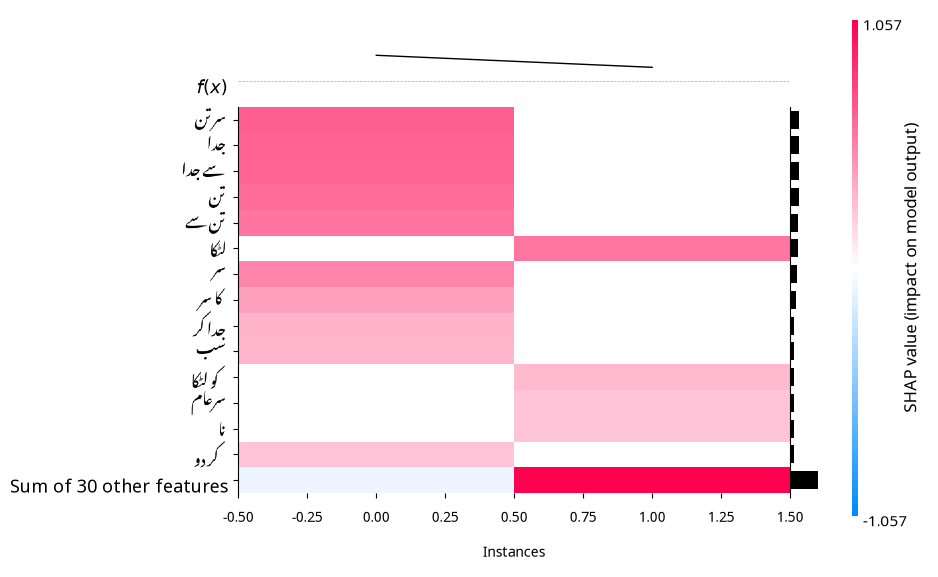


[Method 2] Using Explainer (Interactive):

                             URDU SHAP EXPLANATIONS                             
                                Prediction: تشدد                                

[GENERATING URDU SHAP PLOT...]


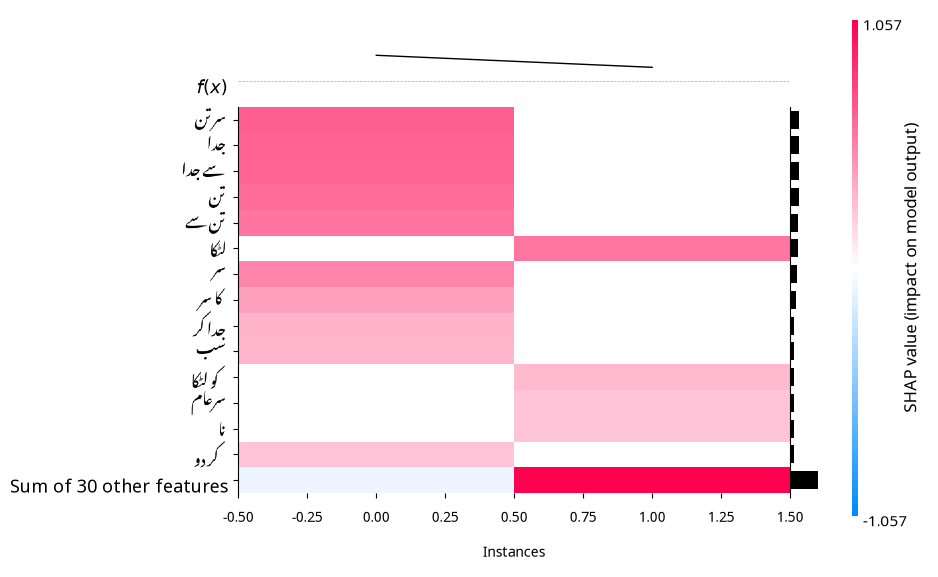


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                        PREDICTION: تشدد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﺳﺮ ﺗﻦ | Value: +0.3310
----------------------------------------
ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﻣﯿﮟ "ﺳﺮ ﺗﻦ" ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﺎ ﻣﺜﺒﺖ ﺍﺛﺮ ﺍﺱ ﻟﯿﮯ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﻟﻔﺎﻅ ﺍﮐﺜﺮ ﺗﺸﺪﺩ ﺳﮯ ﻣﺘﻌﻠﻘﮧ ﻣﺎﺣﻮﻝ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﮯ ﮨﯿﮟ۔ ﺟﺐ ﮐﻮﺋﯽ ﺷﺨﺺ ﺍﭘﻨﮯ ﺳﺮ ﯾﺎ ﺗﻦ ﮐﺎ ﺫﮐﺮ ﮐﺮﺗﺎ ﮨﮯ، ﺗﻮ ﯾﮧ ﺗﺸﺪﺩ ﮐﯽ ﻃﺮﻑ ﺍﺷﺎﺭﮦ ﮐﺮﺗﺎ ﮨﮯ، ﺟﯿﺴﮯ ﮐﮧ ﮐﺴﯽ ﮐﻮ ﺳﺮ ﭘﺮ ﭼﻮﭦ ﻟﮕﻨﺎ ﯾﺎ ﺗﻦ ﭘﺮ ﺯﺧﻢ ﮨﻮﻧﺎ۔ ﺍﺱ ﻃﺮﺡ، ﻣﺎﮈﻝ "ﺳﺮ ﺗﻦ" ﺟﯿﺴﮯ ﺍﻟﻔﺎﻅ ﮐﻮ ﺗﺸﺪﺩ ﺳﮯ ﺟﮍﮮ ﮨﻮﺋﮯ ﺳﻤﺠﮭﺘﺎ ﮨﮯ ﺍﻭﺭ ﺍﺱ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﻮ ﻣﺜﺒﺖ ﻃﻮﺭ ﭘﺮ ﻣﺘﺎﺛﺮ ﮐﺮﺗﺎ ﮨﮯ۔
------

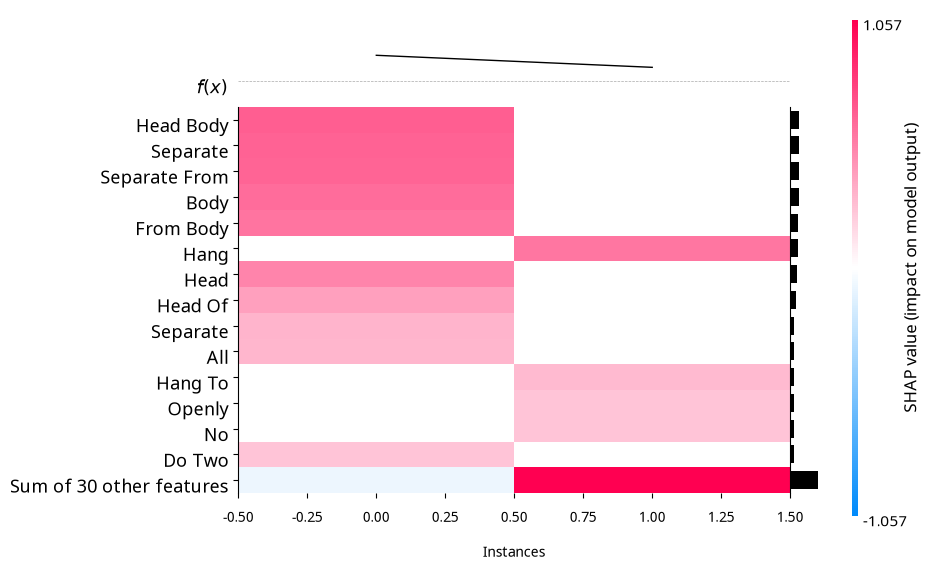


[English Explanation Mode]


TypeError: '<' not supported between instances of 'str' and 'int'

In [6]:
"""
Test RTL Heatmap with 2 Samples (User Tweet + Random Sample)
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import heatmap

# =====================================================================
# Load Data & Train Model
# =====================================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print(f"Total samples: {len(texts)}")

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

print(f"Model trained with {X.shape[1]} features")

# =====================================================================
# Get 2 Samples: User Tweet + Random Sample
# =====================================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"

# Get a random sample from the dataset
random_idx = np.random.choice(len(df), 1)[0]
random_text = texts[random_idx]
random_label = labels[random_idx]

print("\n" + "="*80)
print("TESTING RTL HEATMAP WITH 2 SAMPLES")
print("="*80)

print(f"\nSample 1 (User Tweet):")
print(f"  {user_tweet[:100]}...")

print(f"\nSample 2 (Random from dataset):")
print(f"  {random_text[:100]}...")
print(f"  Label: {random_label}")

# ── Vectorize both samples ──────────────────────────────────────────────
all_feature_names = list(vectorizer.get_feature_names_out())

samples = [user_tweet, random_text]
sample_labels = ["User Tweet", f"Random Sample (Label: {random_label})"]

all_explanations = []

for text in samples:
    instance_vec = vectorizer.transform([text]).toarray()[0]
    present_idx = np.where(instance_vec > 0)[0]
    
    if len(present_idx) > 0:
        # Compute SHAP
        masker = shap.maskers.Independent(data=X, max_samples=100)
        explainer = shap.LinearExplainer(model, masker=masker)
        shap_vals = explainer(instance_vec.reshape(1, -1))
        
        # Create explanation
        exp = shap.Explanation(
            values=shap_vals.values[0][present_idx],
            base_values=shap_vals.base_values[0],
            data=instance_vec[present_idx],
            feature_names=[all_feature_names[i] for i in present_idx]
        )
        all_explanations.append(exp)

# ── Combine both explanations ──────────────────────────────────────────
all_features = sorted(list(set().union(*[exp.feature_names for exp in all_explanations])))
aligned_values = []
aligned_data = []
aligned_base = []

for exp in all_explanations:
    val_map = dict(zip(exp.feature_names, exp.values))
    data_map = dict(zip(exp.feature_names, exp.data))
    aligned_values.append([val_map.get(f, 0) for f in all_features])
    aligned_data.append([data_map.get(f, 0) for f in all_features])
    aligned_base.append(exp.base_values)

combined_explanation = shap.Explanation(
    values=np.array(aligned_values),
    base_values=np.array(aligned_base),
    data=np.array(aligned_data),
    feature_names=all_features
)

print(f"\nCombined explanation shape: {combined_explanation.values.shape}")
print(f"Total unique features: {len(all_features)}")

# ── Show top features across both samples ──────────────────────────────
print("\nTop 10 Features (by mean absolute SHAP value):")
mean_abs = np.abs(combined_explanation.values).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:10]

for i, idx in enumerate(top_idx):
    feat = combined_explanation.feature_names[idx]
    val_mean = combined_explanation.values[:, idx].mean()
    print(f"  {i+1}. {feat}: {val_mean:+.4f}")

# ── Generate Heatmap ──────────────────────────────────────────────────
print("\n🚀 Generating RTL SHAP Heatmap with 2 samples...")

# Method 1: Direct heatmap (no title, no interactive prompts)
print("\n[Method 1] Direct Heatmap:")
plt.figure(figsize=(14, 10))
heatmap(
    shap_values=combined_explanation,
    max_display=15,
    show=True,
    instance_order=None  # Avoid hclust error
)
plt.show()

# Method 2: Using explainer (with interactive prompts)
print("\n[Method 2] Using Explainer (Interactive):")
urdu_explainer = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"  # or "github"
)

# Define wrapper without title
def heatmap_wrapper(shap_values):
    return heatmap(
        shap_values=shap_values,
        max_display=15,
        show=True,
        instance_order=None
    )

urdu_explainer.run_full_analysis(
    shap_values=combined_explanation,
    prediction_label="تشدد",
    plot_fn=heatmap_wrapper,
    sample_text=user_tweet,
    max_features=15,
    allow_positive_negative_split=True
)

print("\n✅ Test complete!")

## SCATTER PLOT

Total samples: 3297
Class distribution: [2475  822]


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


Model trained with 1000 features

TESTING RTL SCATTER PLOT WITH 2 SAMPLES

📝 Sample 1 (User Tweet):
   سب کافر دشمنوں کا سر تن سے جدا کر دو

📝 Sample 2 (Random from dataset):
   ہمارا مرنا جینا نبی پاک صلی اللہ علیہ والہ وسلم کی ناموس پہ پہرہ دینا ۔ کوئی دل میں ہے تو اس اوپن بو...
   Label: 1

Combined explanation shape: (2, 47)
Total unique features: 47

Top 10 Features (by mean absolute SHAP value):
  1. سر تن: +0.4319
  2. جدا: +0.4220
  3. سے جدا: +0.4148
  4. سر: +0.4112
  5. تن: +0.3946
  6. تن سے: +0.3732
  7. کا سر: +0.3198
  8. جدا کر: +0.2031
  9. کر دو: +0.1579
  10. سب: +0.1495

🚀 Generating RTL Scatter Plot...

Creating scatter plot for feature: 'سر تن'

[Method 1] Direct Scatter Plot:


<Figure size 1200x800 with 0 Axes>

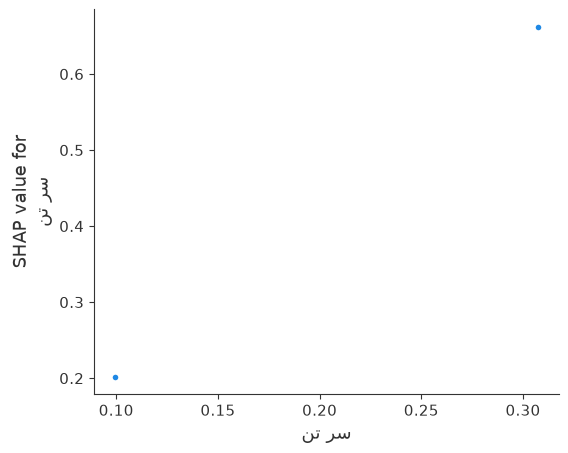


[Method 2] Using Explainer (Interactive):

                             URDU SHAP EXPLANATIONS                             
                                Prediction: تشدد                                

[GENERATING URDU SHAP PLOT...]


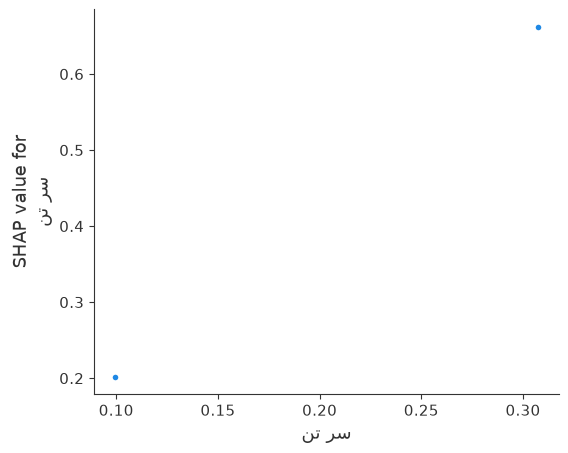


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                        PREDICTION: تشدد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﺳﺮ ﺗﻦ | Value: +0.4319
----------------------------------------
ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﻣﯿﮟ "ﺳﺮ ﺗﻦ" ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﺎ ﻣﺜﺒﺖ ﺍﺛﺮ ﺍﺱ ﻟﯿﮯ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﻟﻔﺎﻅ ﺍﮐﺜﺮ ﺗﺸﺪﺩ ﺳﮯ ﻣﺘﻌﻠﻘﮧ ﻣﺎﺣﻮﻝ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮﺗﮯ ﮨﯿﮟ۔ ﺟﺐ ﮐﻮﺋﯽ ﺷﺨﺺ ﺍﭘﻨﮯ ﺳﺮ ﯾﺎ ﺗﻦ ﮐﮯ ﺑﺎﺭﮮ ﻣﯿﮟ ﺑﺎﺕ ﮐﺮﺗﺎ ﮨﮯ، ﺗﻮ ﯾﮧ ﺗﺸﺪﺩ ﮐﮯ ﺍﻣﮑﺎﻧﺎﺕ ﮐﻮ ﺑﮍﮬﺎ ﺳﮑﺘﺎ ﮨﮯ، ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺟﺴﻤﺎﻧﯽ伤 ﯾﺎ ﺣﻤﻠﮯ ﮐﯽ ﻃﺮﻑ ﺍﺷﺎﺭﮦ ﮐﺮﺗﺎ ﮨﮯ۔ ﺍﺱ ﻟﯿﮯ، ﻣﺎﮈﻝ "ﺳﺮ ﺗﻦ" ﮐﻮ ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﺳﮯ ﺟﻮﮌﺗﺎ ﮨﮯ، ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﻟﻔﺎﻅ ﺍﮐﺜﺮ ﺗﺸﺪﺩ ﮐﮯ ﻣﺎﺣﻮﻝ ﻣﯿﮟ ﺍﺳﺘﻌﻤﺎﻝ ﮨﻮ

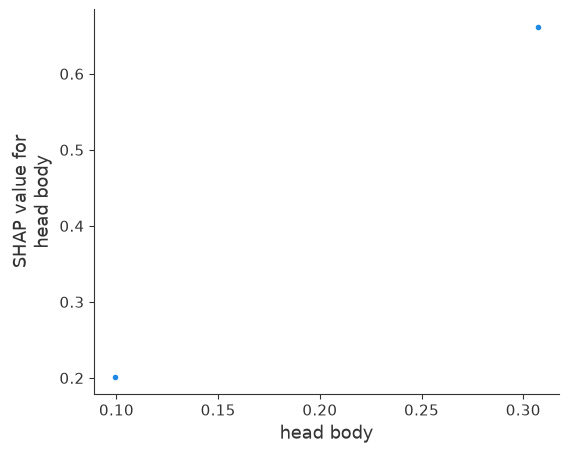


[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Strictness                             
--------------------------------------------------------------------------------

Translated Sample: Behead all infidel enemies
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: head body | Value: +0.4319
Original Urdu: سر تن
----------------------------------------
The Urdu feature 'سر تن' (meaning 'head and body' or 'entire being') positively impacts the model output for 'strictness' with a SHAP value of +0.4319, suggesting that when this feature is present, the model is more likely to predict a higher level of strictness. This is likely because 'سر تن' implies a comprehensive and all-encompassing approach, which aligns with the concept of strictness, indicating a 

In [2]:
"""
Test RTL Scatter Plot with shap_rtl Package
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Import from your shap_rtl package
from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import scatter

# =====================================================================
# Load Data & Train Model
# =====================================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print(f"Total samples: {len(texts)}")
print(f"Class distribution: {np.bincount(labels)}")

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

print(f"Model trained with {X.shape[1]} features")

# =====================================================================
# Get 2 Samples for Testing
# =====================================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"

# Get a random sample from the dataset
random_idx = np.random.choice(len(df), 1)[0]
random_text = texts[random_idx]
random_label = labels[random_idx]

print("\n" + "="*80)
print("TESTING RTL SCATTER PLOT WITH 2 SAMPLES")
print("="*80)

print(f"\n📝 Sample 1 (User Tweet):")
print(f"   {user_tweet}")

print(f"\n📝 Sample 2 (Random from dataset):")
print(f"   {random_text[:100]}...")
print(f"   Label: {random_label}")

# =====================================================================
# Vectorize and Compute SHAP for Both Samples
# =====================================================================
all_feature_names = list(vectorizer.get_feature_names_out())
samples = [user_tweet, random_text]
all_explanations = []

for text in samples:
    instance_vec = vectorizer.transform([text]).toarray()[0]
    present_idx = np.where(instance_vec > 0)[0]
    
    if len(present_idx) > 0:
        # Compute SHAP
        masker = shap.maskers.Independent(data=X, max_samples=100)
        explainer = shap.LinearExplainer(model, masker=masker)
        shap_vals = explainer(instance_vec.reshape(1, -1))
        
        # Create explanation with only present features
        exp = shap.Explanation(
            values=shap_vals.values[0][present_idx],
            base_values=shap_vals.base_values[0],
            data=instance_vec[present_idx],
            feature_names=[all_feature_names[i] for i in present_idx]
        )
        all_explanations.append(exp)

# ── Combine both explanations ──────────────────────────────────────────
all_features = sorted(list(set().union(*[exp.feature_names for exp in all_explanations])))
aligned_values = []
aligned_data = []
aligned_base = []

for exp in all_explanations:
    val_map = dict(zip(exp.feature_names, exp.values))
    data_map = dict(zip(exp.feature_names, exp.data))
    aligned_values.append([val_map.get(f, 0) for f in all_features])
    aligned_data.append([data_map.get(f, 0) for f in all_features])
    aligned_base.append(exp.base_values)

combined_explanation = shap.Explanation(
    values=np.array(aligned_values),
    base_values=np.array(aligned_base),
    data=np.array(aligned_data),
    feature_names=all_features
)

print(f"\nCombined explanation shape: {combined_explanation.values.shape}")
print(f"Total unique features: {len(all_features)}")

# ── Show top features ──────────────────────────────────────────────────
print("\nTop 10 Features (by mean absolute SHAP value):")
mean_abs = np.abs(combined_explanation.values).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:10]

for i, idx in enumerate(top_idx):
    feat = combined_explanation.feature_names[idx]
    val_mean = combined_explanation.values[:, idx].mean()
    print(f"  {i+1}. {feat}: {val_mean:+.4f}")

# =====================================================================
# Generate Scatter Plot
# =====================================================================
print("\n🚀 Generating RTL Scatter Plot...")

# Get a specific feature for scatter plot
# Choose the top feature from above
top_feature = combined_explanation.feature_names[top_idx[0]]
print(f"\nCreating scatter plot for feature: '{top_feature}'")

# Method 1: Direct scatter plot (no interactive prompts)
print("\n[Method 1] Direct Scatter Plot:")
plt.figure(figsize=(12, 8))
scatter(
    shap_values=combined_explanation,
    max_display=10,
    show=True
)
plt.show()

# Method 2: Using explainer (with interactive prompts)
print("\n[Method 2] Using Explainer (Interactive):")
urdu_explainer = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"  # or "github"
)

# Define wrapper for scatter
def scatter_wrapper(shap_values):
    return scatter(
        shap_values=shap_values,
        max_display=15,
        show=True
    )

urdu_explainer.run_full_analysis(
    shap_values=combined_explanation,
    prediction_label="تشدد" if random_label == 1 else "غیر تشدد",
    plot_fn=scatter_wrapper,
    sample_text=user_tweet,
    max_features=10,
    allow_positive_negative_split=True
)

print("\n✅ Scatter plot test complete!")

Total samples: 3297
Class distribution: [2475  822]


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


Model trained with 1000 features

TESTING RTL SCATTER PLOT WITH EXPLANATIONS

📝 Sample 1 (User Tweet):
   سب کافر دشمنوں کا سر تن سے جدا کر دو

📝 Sample 2 (Random from dataset):
   والا بل سے تک ہو گیا ۔ یوتھیو اس جرم پر بل نہیں اپنے آپ کو جلا دو ۔...
   Label: 1

Combined explanation shape: (2, 31)
Total unique features: 31

Top 10 Features (by mean absolute SHAP value):
  1. سر تن: +0.3310
  2. جدا: +0.3248
  3. سے جدا: +0.3193
  4. تن: +0.3048
  5. جلا دو: +0.2973
  6. تن سے: +0.2883
  7. سر: +0.2527
  8. کا سر: +0.1944
  9. کو جلا: +0.1594
  10. جدا کر: +0.1545

🚀 Generating RTL Scatter Plot with Explanations...

                             URDU SHAP EXPLANATIONS                             
                                Prediction: تشدد                                

[GENERATING URDU SHAP PLOT...]


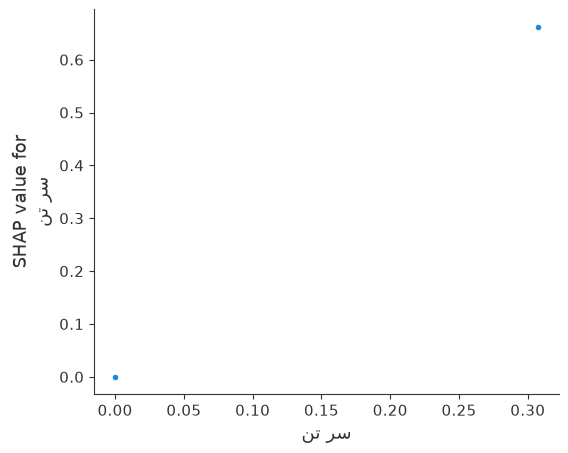


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                        PREDICTION: تشدد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﺳﺮ ﺗﻦ | Value: +0.3310
----------------------------------------
ﺳﺮ ﺗﻦ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﮈﺍﻟﺘﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﻧﺴﺎﻧﯽ ﺟﺴﻢ ﮐﺎ ﻭﮦ ﺣﺼﮧ ﮨﮯ ﺟﻮ ﺟﺬﺑﺎﺕ، ﺍﺣﺴﺎﺳﺎﺕ ﺍﻭﺭ ﺭﺩ ﻋﻤﻞ ﺳﮯ ﻣﺘﻌﻠﻖ ﮨﮯ۔ ﺟﺐ ﺳﺮ ﺗﻦ ﻣﯿﮟ ﺗﻨﺎﺅ ﯾﺎ ﺗﯿﺰﯼ ﺁ ﺟﺎﺋﮯ ﺗﻮ ﯾﮧ ﺍﻧﺴﺎﻥ ﮐﮯ ﺭﻭﯾﮯ ﻣﯿﮟ ﺗﺒﺪﯾﻠﯽ ﻻﻧﮯ ﮐﺎ ﺑﺎﻋﺚ ﺑﻦ ﺳﮑﺘﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﺗﺸﺪﺩ ﮐﯽ ﺍﻣﮑﺎﻧﺎﺕ ﺑﮍﮪ ﺟﺎﺗﮯ ﮨﯿﮟ۔ ﺍﺱ ﻟﯿﮯ، ﺳﺮ ﺗﻦ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﻮ ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﮯ ﻟﯿﮯ ﺍﮨﻢ ﺳﻤﺠﮭﺎ ﺟﺎﺗﺎ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﻧﺴﺎﻧﯽ ﺭﻭﯾﮯ ﮐﮯ ﭘﯿﭽﯿﺪﮮ ﭘﮩﻠﻮﺅﮞ ﮐﻮ ﺳ

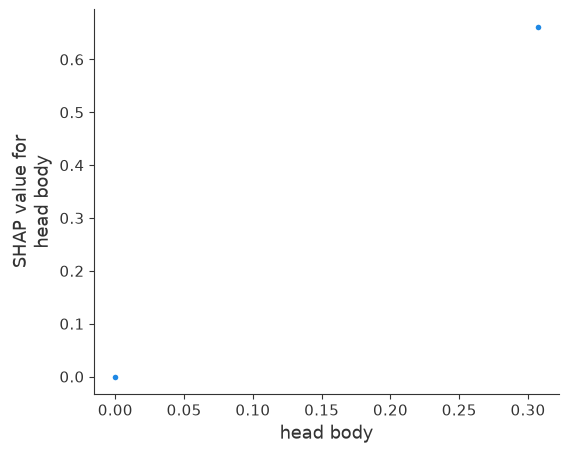


                           ENGLISH EXPLANATION OPTION                           

                              ENGLISH EXPLANATIONS                              

[TRANSLATING SAMPLE TEXT TO ENGLISH...]

Original Urdu Text:
  ﺳﺐ ﮐﺎﻓﺮ ﺩﺷﻤﻨﻮﮞ ﮐﺎ ﺳﺮ ﺗﻦ ﺳﮯ ﺟﺪﺍ ﮐﺮ ﺩﻭ

English Translation:
  Behead all infidel enemies
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Strictness                             
--------------------------------------------------------------------------------

Translated Sample: Behead all infidel enemies
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: head body | Value: +0.3310
----------------------------------------
The Urdu feature 'head body' pos

In [2]:
"""
Test RTL Scatter Plot with shap_rtl Package
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Import from your shap_rtl package
from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import scatter

# =====================================================================
# Load Data & Train Model
# =====================================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print(f"Total samples: {len(texts)}")
print(f"Class distribution: {np.bincount(labels)}")

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

print(f"Model trained with {X.shape[1]} features")

# =====================================================================
# Get Samples for Testing
# =====================================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"

# Get a random sample from the dataset
random_idx = np.random.choice(len(df), 1)[0]
random_text = texts[random_idx]
random_label = labels[random_idx]

print("\n" + "="*80)
print("TESTING RTL SCATTER PLOT WITH EXPLANATIONS")
print("="*80)

print(f"\n📝 Sample 1 (User Tweet):")
print(f"   {user_tweet}")

print(f"\n📝 Sample 2 (Random from dataset):")
print(f"   {random_text[:100]}...")
print(f"   Label: {random_label}")

# =====================================================================
# Vectorize and Compute SHAP for Both Samples
# =====================================================================
all_feature_names = list(vectorizer.get_feature_names_out())
samples = [user_tweet, random_text]
all_explanations = []

for text in samples:
    instance_vec = vectorizer.transform([text]).toarray()[0]
    present_idx = np.where(instance_vec > 0)[0]
    
    if len(present_idx) > 0:
        # Compute SHAP
        masker = shap.maskers.Independent(data=X, max_samples=100)
        explainer = shap.LinearExplainer(model, masker=masker)
        shap_vals = explainer(instance_vec.reshape(1, -1))
        
        # Create explanation with only present features
        exp = shap.Explanation(
            values=shap_vals.values[0][present_idx],
            base_values=shap_vals.base_values[0],
            data=instance_vec[present_idx],
            feature_names=[all_feature_names[i] for i in present_idx]
        )
        all_explanations.append(exp)

# ── Combine both explanations ──────────────────────────────────────────
all_features = sorted(list(set().union(*[exp.feature_names for exp in all_explanations])))
aligned_values = []
aligned_data = []
aligned_base = []

for exp in all_explanations:
    val_map = dict(zip(exp.feature_names, exp.values))
    data_map = dict(zip(exp.feature_names, exp.data))
    aligned_values.append([val_map.get(f, 0) for f in all_features])
    aligned_data.append([data_map.get(f, 0) for f in all_features])
    aligned_base.append(exp.base_values)

combined_explanation = shap.Explanation(
    values=np.array(aligned_values),
    base_values=np.array(aligned_base),
    data=np.array(aligned_data),
    feature_names=all_features
)

print(f"\nCombined explanation shape: {combined_explanation.values.shape}")
print(f"Total unique features: {len(all_features)}")

# ── Show top features ──────────────────────────────────────────────────
print("\nTop 10 Features (by mean absolute SHAP value):")
mean_abs = np.abs(combined_explanation.values).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:10]

for i, idx in enumerate(top_idx):
    feat = combined_explanation.feature_names[idx]
    val_mean = combined_explanation.values[:, idx].mean()
    print(f"  {i+1}. {feat}: {val_mean:+.4f}")

# =====================================================================
# Generate Scatter Plot with Explanations (Single Method)
# =====================================================================
print("\n🚀 Generating RTL Scatter Plot with Explanations...")

# Create explainer
urdu_explainer = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"  # or "github"
)

# Define wrapper for scatter (no title parameter)
def scatter_wrapper(shap_values):
    return scatter(
        shap_values=shap_values,
        max_display=15,
        show=True
    )

# Get prediction label in Urdu
prediction_label = "تشدد" if random_label == 1 else "غیر تشدد"

# Run full analysis with scatter plot
urdu_explainer.run_full_analysis(
    shap_values=combined_explanation,
    prediction_label=prediction_label,
    plot_fn=scatter_wrapper,
    sample_text=user_tweet,
    max_features=10,
    allow_positive_negative_split=True
)

print("\n✅ Scatter plot with explanations complete!")

## Waterfall plot

Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.



Tweet: سب کافر دشمنوں کا سر تن سے جدا کر دو

Features present: 14
Base value: -0.8210

Top Features:
  1. سر تن: +0.6621
  2. جدا: +0.6496
  3. سے جدا: +0.6386
  4. تن: +0.6097
  5. تن سے: +0.5766
  6. سر: +0.5055
  7. کا سر: +0.3889
  8. جدا کر: +0.3089
  9. سب: +0.2989
  10. کر دو: +0.2419

🚀 Generating RTL Waterfall Plot...

                             URDU SHAP EXPLANATIONS                             
                                Prediction: تشدد                                

[GENERATING URDU SHAP PLOT...]


c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_waterfall_rtl.py:253: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


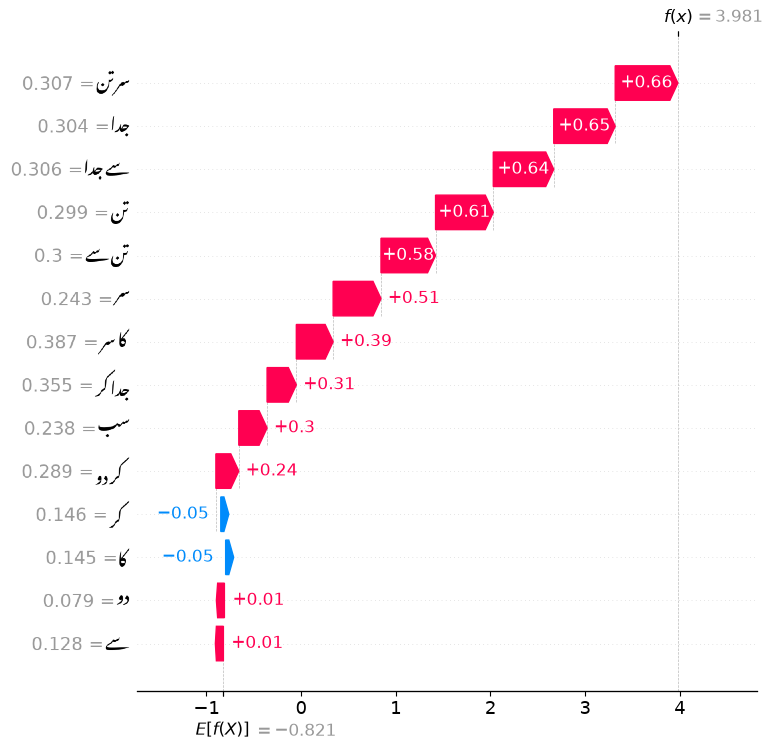


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                        PREDICTION: تشدد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 1 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﺳﺮ ﺗﻦ | Value: +0.6621
----------------------------------------
ﺳﺮ ﺗﻦ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﭘﺮ ﻣﺜﺒﺖ ﺍﺛﺮ ﮈﺍﻟﺘﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﯾﮧ ﺍﻧﺴﺎﻧﯽ ﺟﺴﻢ ﮐﺎ ﺍﯾﮏ ﺣﺴﺎﺱ ﺣﺼﮧ ﮨﮯ ﺟﻮ ﺗﺸﺪﺩ ﮐﮯ ﺍﺛﺮﺍﺕ ﮐﻮ ﻇﺎﮨﺮ ﮐﺮﺗﺎ ﮨﮯ۔ ﺟﺐ ﺳﺮ ﺗﻦ ﭘﺮ ﺯﻭﺭ ﺩﯾﺎ ﺟﺎﺋﮯ ﺗﻮ ﯾﮧ ﺗﺸﺪﺩ ﮐﯽ ﻋﻼﻣﺎﺕ ﮐﻮ ﺑﮍﮬﺎ ﺩﯾﺘﺎ ﮨﮯ، ﺟﺲ ﺳﮯ ﭘﯿﺶ ﮔﻮﺋﯽ ﻣﯿﮟ ﺗﺸﺪﺩ ﮐﯽ ﺍﻣﮑﺎﻧﺎﺕ ﺑﮍﮪ ﺟﺎﺗﮯ ﮨﯿﮟ۔ ﺍﺱ ﻟﯿﮯ، ﺳﺮ ﺗﻦ ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﺎ ﻣﺜﺒﺖ ﺍﺛﺮ ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﻮ ﺑﮩﺘﺮ ﺑﻨﺎﺗﺎ ﮨﮯ۔
----------------------------------------


             

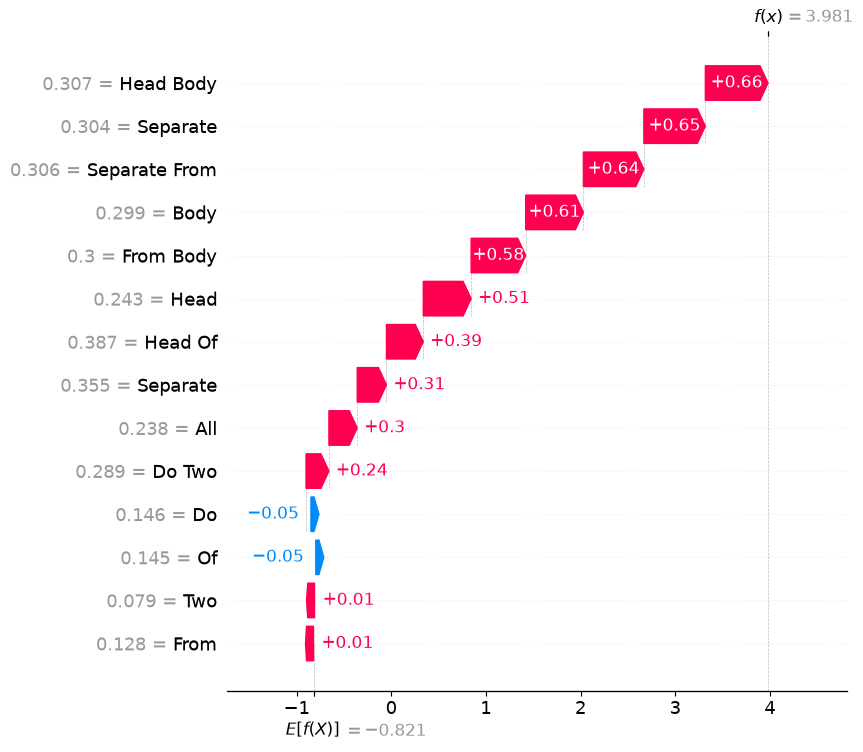


                           ENGLISH EXPLANATION OPTION                           

                              ENGLISH EXPLANATIONS                              

[TRANSLATING SAMPLE TEXT TO ENGLISH...]

Original Urdu Text:
  ﺳﺐ ﮐﺎﻓﺮ ﺩﺷﻤﻨﻮﮞ ﮐﺎ ﺳﺮ ﺗﻦ ﺳﮯ ﺟﺪﺍ ﮐﺮ ﺩﻭ

English Translation:
  Behead all infidel enemies
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Strictness                             
--------------------------------------------------------------------------------

Translated Sample: Behead all infidel enemies
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: Head Body | Value: +0.6621
----------------------------------------
The Urdu feature 'Head Body' has

In [ ]:
"""
Test RTL Waterfall Plot - Simple Version
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import waterfall

# =====================================================================
# Load Data & Train Model
# =====================================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 1), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

# =====================================================================
# Get Single Sample for Waterfall
# =====================================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"

print(f"\nTweet: {user_tweet}")

# Vectorize
all_feature_names = list(vectorizer.get_feature_names_out())
instance_vec = vectorizer.transform([user_tweet]).toarray()[0]
present_idx = np.where(instance_vec > 0)[0]

# Compute SHAP
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)
shap_vals = explainer(instance_vec.reshape(1, -1))

# Create 1D Explanation for Waterfall
user_explanation = shap.Explanation(
    values=shap_vals.values[0][present_idx],
    base_values=shap_vals.base_values[0],
    data=instance_vec[present_idx],
    feature_names=[all_feature_names[i] for i in present_idx]
)

print(f"\nFeatures present: {len(user_explanation.feature_names)}")
print(f"Base value: {user_explanation.base_values:.4f}")

# Show top features
print("\nTop Features:")
sorted_idx = np.argsort(np.abs(user_explanation.values))[::-1][:10]
for i, idx in enumerate(sorted_idx):
    feat = user_explanation.feature_names[idx]
    val = user_explanation.values[idx]
    print(f"  {i+1}. {feat}: {val:+.4f}")

# =====================================================================
# Generate Waterfall Plot
# =====================================================================
print("\n🚀 Generating RTL Waterfall Plot...")

# Create explainer
urdu_explainer = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

# Define wrapper for waterfall
def waterfall_wrapper(shap_values):
    return waterfall(
        shap_values=shap_values,
        max_display=5,
        show=True
    )

# Run full analysis
urdu_explainer.run_full_analysis(
    shap_values=user_explanation,
    prediction_label="تشدد",
    plot_fn=waterfall_wrapper,
    sample_text=user_tweet,
    max_features=10,
    allow_positive_negative_split=True
)

print("\n✅ Waterfall plot complete!")

Total samples: 3297
Class distribution: [2475  822]


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.


Model trained with 1000 features

TESTING RTL WATERFALL PLOT

📝 User Tweet:
   سب کافر دشمنوں کا سر تن سے جدا کر دو

Features present: 9
Base value: -0.7285

Top Features:
  1. جدا: +1.4277
  2. تن: +1.3719
  3. سر: +0.9922
  4. کافر: +0.4373
  5. سب: +0.3861
  6. کر: -0.0917
  7. دو: +0.0758
  8. سے: +0.0584
  9. کا: -0.0113

🚀 Generating RTL Waterfall Plot with Explanations...

                             URDU SHAP EXPLANATIONS                             
                                Prediction: تشدد                                

[GENERATING URDU SHAP PLOT...]


c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_waterfall_rtl.py:253: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


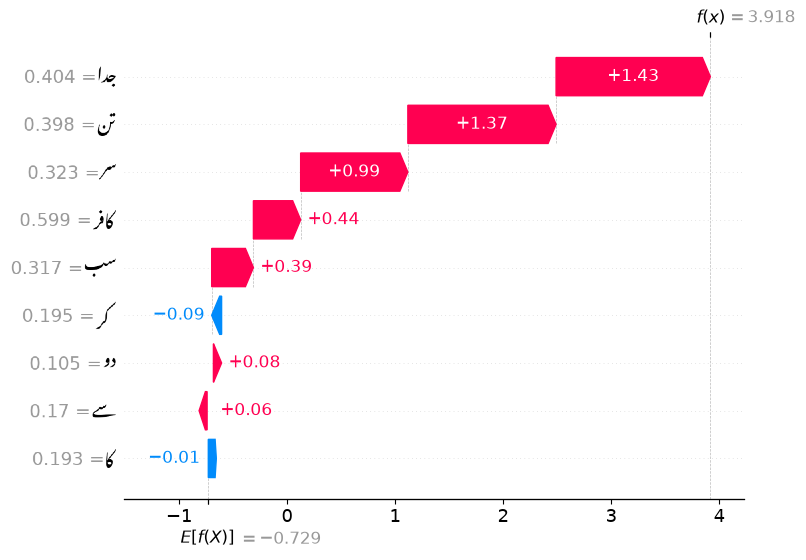


[Urdu Explanation Mode]
------------------------------------------------------------------------------------------------------------------------
                                                                                                        PREDICTION: تشدد
------------------------------------------------------------------------------------------------------------------------
                                                                                 
Analysis of Top 2 SHAP Features (Urdu)
--------------------------------------------------

Feature: ﺟﺪﺍ | Value: +1.4277
----------------------------------------
ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﭘﺮ "ﺟﺪﺍ" ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﮐﺎ ﻣﺜﺒﺖ ﺍﺛﺮ ﺍﺱ ﻟﯿﮯ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﺍﺭﺩﻭ ﺯﺑﺎﻥ ﻣﯿﮟ "ﺟﺪﺍ" ﮐﺎ ﻣﻄﻠﺐ ﻋﻠﯿﺤﺪﮔﯽ ﯾﺎ ﺗﻔﺮﯾﻖ ﮨﻮﺗﺎ ﮨﮯ، ﺟﻮ ﺍﮐﺜﺮ ﺗﻨﺎﺯﻋﺎﺕ ﺍﻭﺭ ﺗﺼﺎﺩﻡ ﮐﺎ ﺑﺎﻋﺚ ﺑﻨﺘﺎ ﮨﮯ۔ ﺍﺱ ﻟﯿﮯ، ﺟﺐ "ﺟﺪﺍ" ﮐﯽ ﺧﺼﻮﺻﯿﺖ ﻣﻮﺟﻮﺩ ﮨﻮ، ﺗﻮ ﯾﮧ ﺗﺸﺪﺩ ﮐﯽ ﭘﯿﺶ ﮔﻮﺋﯽ ﮐﻮ ﺑﮍﮬﺎ ﺩﯾﺘﯽ ﮨﮯ ﮐﯿﻮﻧﮑﮧ ﻋﻠﯿﺤﺪﮔﯽ ﺍﻭﺭ ﺗﻔﺮﯾﻖ ﮐﮯ ﺣﺎﻻﺕ ﻣﯿﮟ ﺗﺸﺪﺩ ﮐﺎ ﺍﻣﮑﺎﻥ ﺑﮍﮪ ﺟﺎﺗﺎ ﮨﮯ۔
----------------------------------------

Feature: ﺗﻦ | Value: +1.

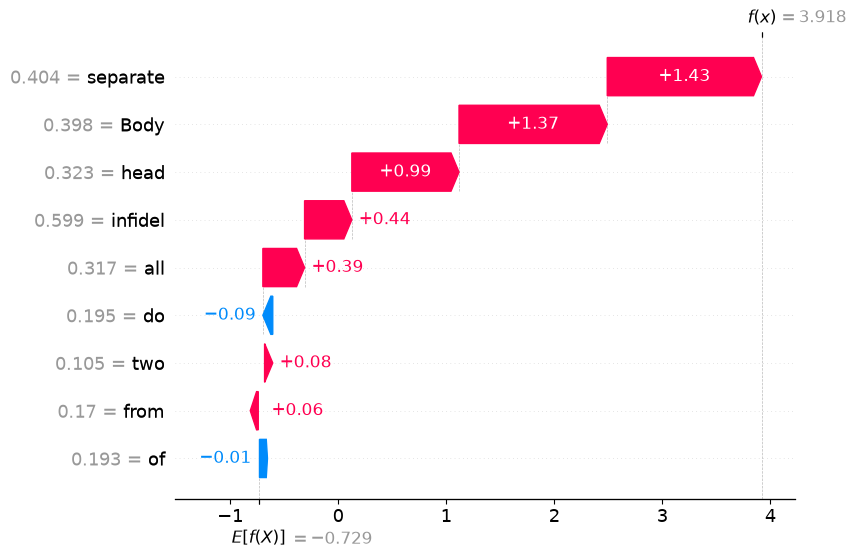


                           ENGLISH EXPLANATION OPTION                           

                              ENGLISH EXPLANATIONS                              

[TRANSLATING SAMPLE TEXT TO ENGLISH...]

Original Urdu Text:
  ﺳﺐ ﮐﺎﻓﺮ ﺩﺷﻤﻨﻮﮞ ﮐﺎ ﺳﺮ ﺗﻦ ﺳﮯ ﺟﺪﺍ ﮐﺮ ﺩﻭ

English Translation:
  Behead all infidel enemies
--------------------------------------------------------------------------------

[English Explanation Mode]
--------------------------------------------------------------------------------
                             PREDICTION: Strictness                             
--------------------------------------------------------------------------------

Translated Sample: Behead all infidel enemies
--------------------------------------------------------------------------------

Analysis of Top 1 SHAP Features (English)
--------------------------------------------------

Feature: separate | Value: +1.4277
----------------------------------------
The Urdu feature 'separate' has a

In [5]:
"""
Test RTL Waterfall Plot with shap_rtl Package
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Import from your shap_rtl package
from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import waterfall  # ← Direct import

# =====================================================================
# Load Data & Train Model
# =====================================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print(f"Total samples: {len(texts)}")
print(f"Class distribution: {np.bincount(labels)}")

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 1), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

print(f"Model trained with {X.shape[1]} features")

# =====================================================================
# Get Single Sample for Waterfall
# =====================================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"

print("\n" + "="*80)
print("TESTING RTL WATERFALL PLOT")
print("="*80)

print(f"\n📝 User Tweet:")
print(f"   {user_tweet}")

# Vectorize
all_feature_names = list(vectorizer.get_feature_names_out())
instance_vec = vectorizer.transform([user_tweet]).toarray()[0]
present_idx = np.where(instance_vec > 0)[0]

# Compute SHAP
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)
shap_vals = explainer(instance_vec.reshape(1, -1))

# Create 1D Explanation for Waterfall
user_explanation = shap.Explanation(
    values=shap_vals.values[0][present_idx],
    base_values=shap_vals.base_values[0],
    data=instance_vec[present_idx],
    feature_names=[all_feature_names[i] for i in present_idx]
)

print(f"\nFeatures present: {len(user_explanation.feature_names)}")
print(f"Base value: {user_explanation.base_values:.4f}")

# Show top features
print("\nTop Features:")
sorted_idx = np.argsort(np.abs(user_explanation.values))[::-1][:10]
for i, idx in enumerate(sorted_idx):
    feat = user_explanation.feature_names[idx]
    val = user_explanation.values[idx]
    print(f"  {i+1}. {feat}: {val:+.4f}")

# =====================================================================
# Generate Waterfall Plot with Explanations (DIRECT - NO WRAPPER)
# =====================================================================
print("\n🚀 Generating RTL Waterfall Plot with Explanations...")

# Create explainer
urdu_explainer = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"  # or "github"
)

# Get prediction label in Urdu
prediction_label = "تشدد"

# Run full analysis with waterfall plot - DIRECT FUNCTION CALL
urdu_explainer.run_full_analysis(
    shap_values=user_explanation,
    prediction_label=prediction_label,
    plot_fn=waterfall,  # ← Direct call, no wrapper needed!
    sample_text=user_tweet,
    max_features=5,
    allow_positive_negative_split=True
)

print("\n✅ Waterfall plot with explanations complete!")

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


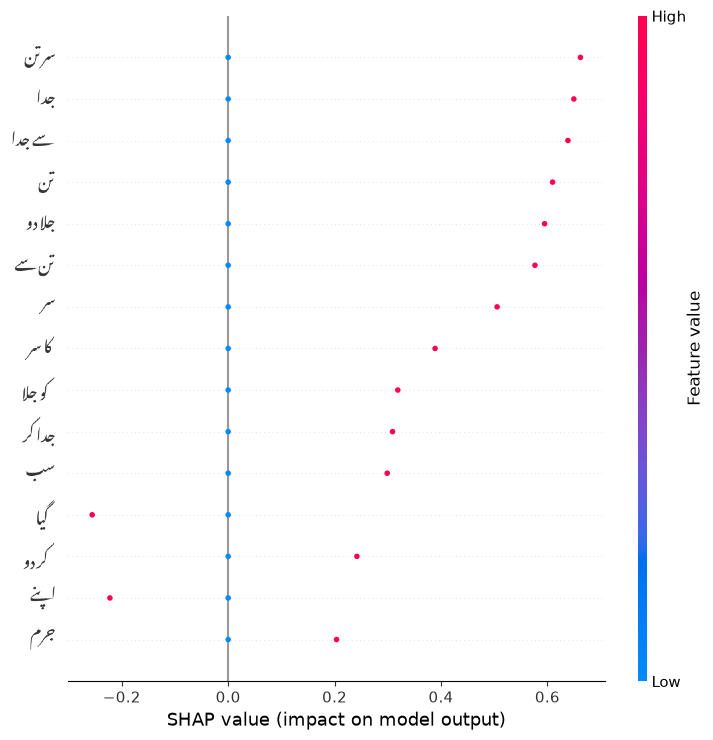

In [6]:
# User's code - super simple!
from shap_rtl.plots import summary_plot

# ... after getting SHAP values for multiple samples ...

# Just call it directly
summary_plot(
    shap_values=combined_explanation,
    max_display=15,
    show=True
)

RTL SHAP PLOTS - COMPLETE DEMONSTRATION


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples f


✅ Model trained: 1000 features, 3297 samples

📝 Test Tweet: سب کافر دشمنوں کا سر تن سے جدا کر دو


Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3297 when initializing the masker.
Background dataset has 3297 samples but max_samples=100. Subsampling to 100 samples f


✅ SHAP explanation ready: (31, 349)

PLOT 1: WATERFALL - Single Sample Feature Contributions


c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_waterfall_rtl.py:253: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


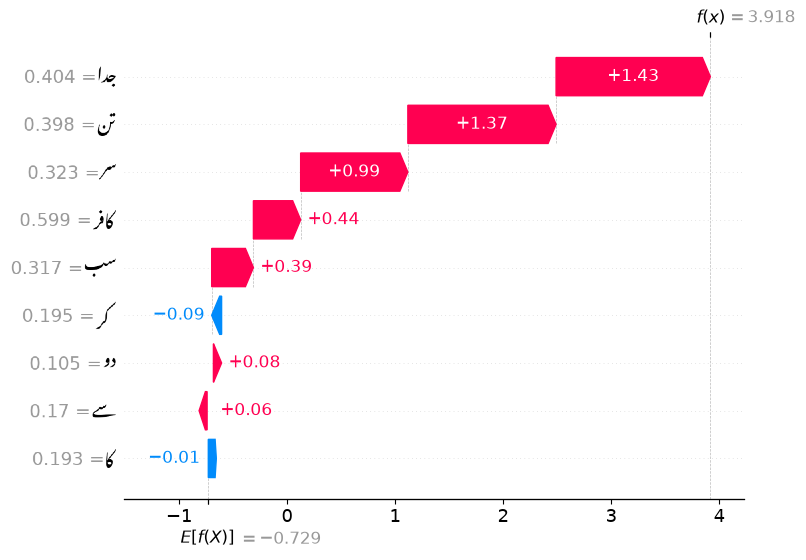


PLOT 2: BAR PLOT - Feature Importance


c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_bar_rtl.py:229: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


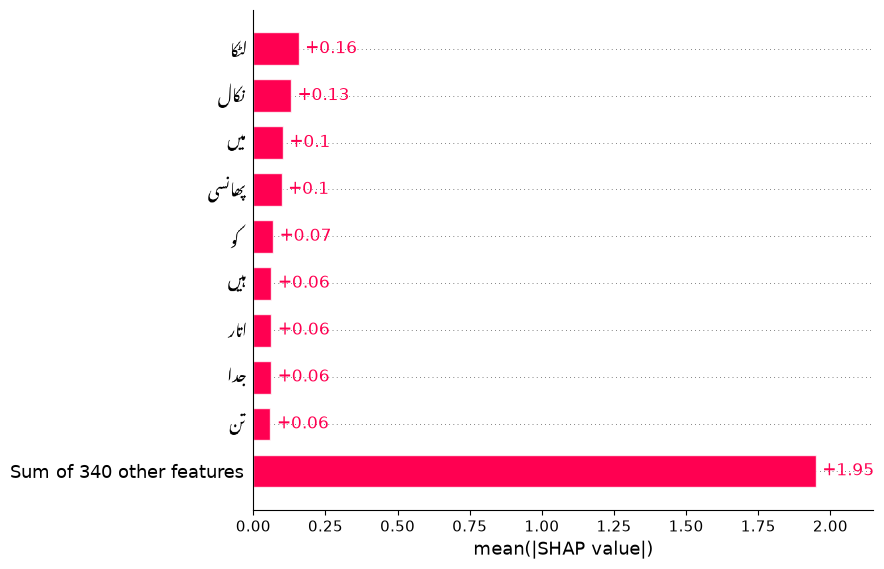


PLOT 3: BEESWARM - Feature Impact Distribution


c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_beeswarm_rtl.py:226: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_beeswarm_rtl.py:226: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


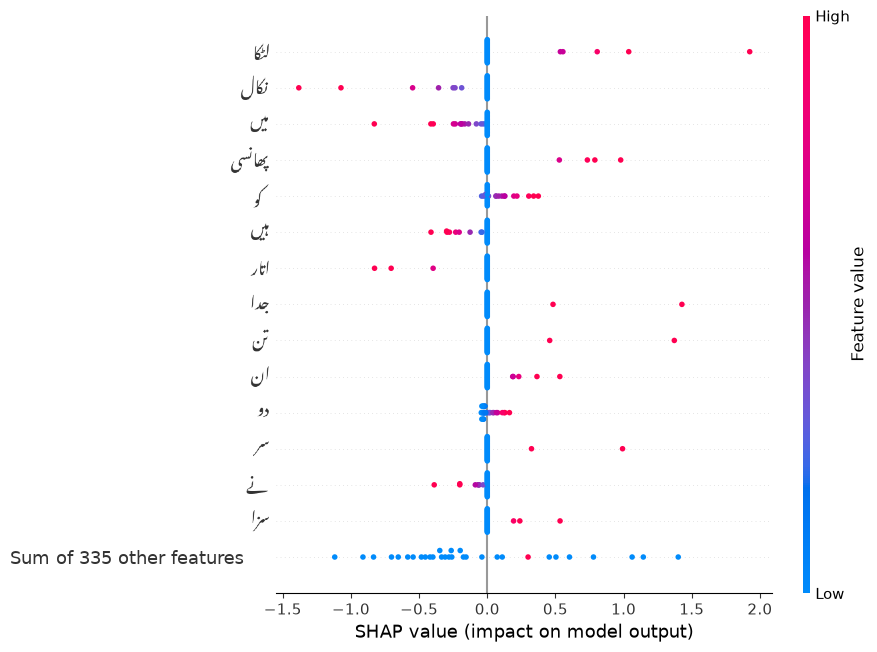


PLOT 4: SUMMARY PLOT - Feature Summary


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\plots\_beeswarm.py:1150: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


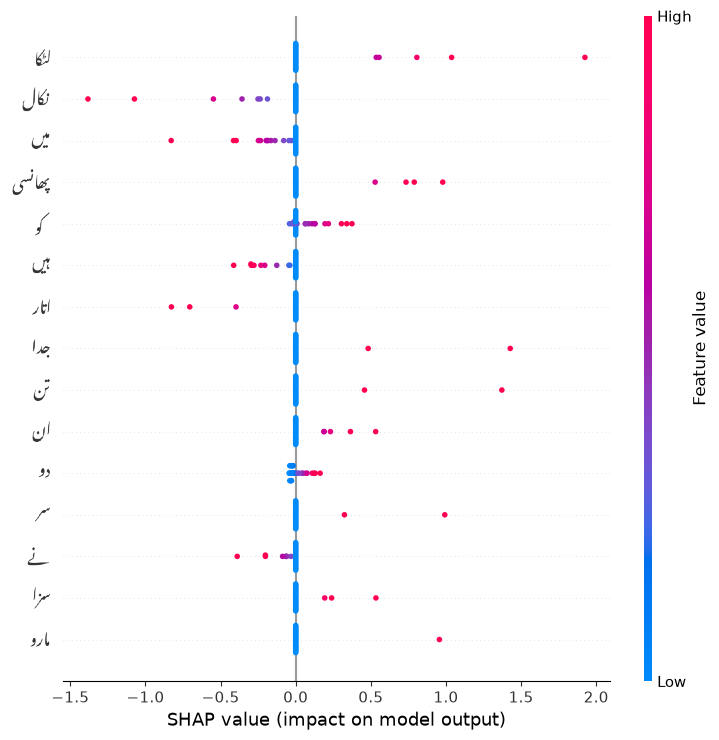


PLOT 5: HEATMAP - Sample Feature Heatmap


c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_heatmap_rtl.py:100: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()           # must draw first so get_yticklabels() is populated
c:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\shap_rtl\plots\_heatmap_rtl.py:100: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()           # must draw first so get_yticklabels() is populated


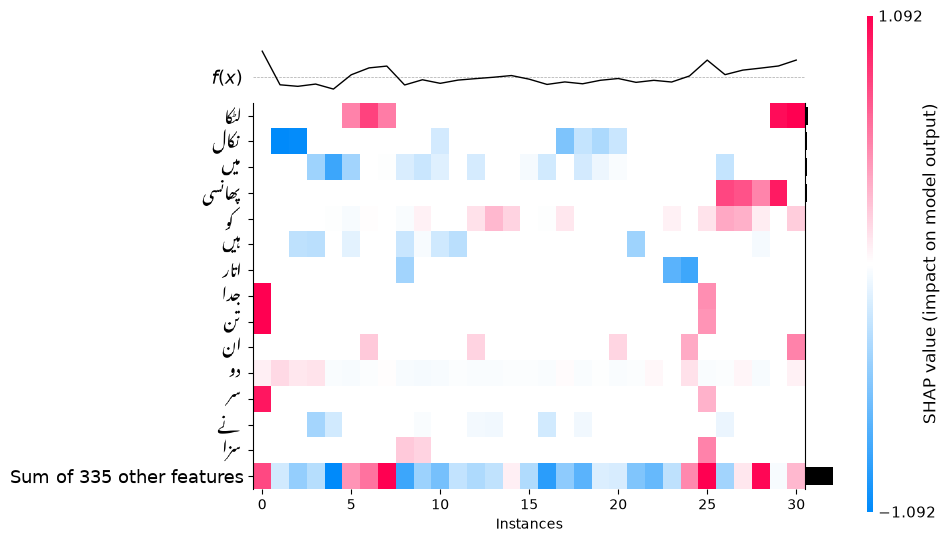


PLOT 6: SCATTER PLOT - Feature Scatter


<Figure size 1200x800 with 0 Axes>

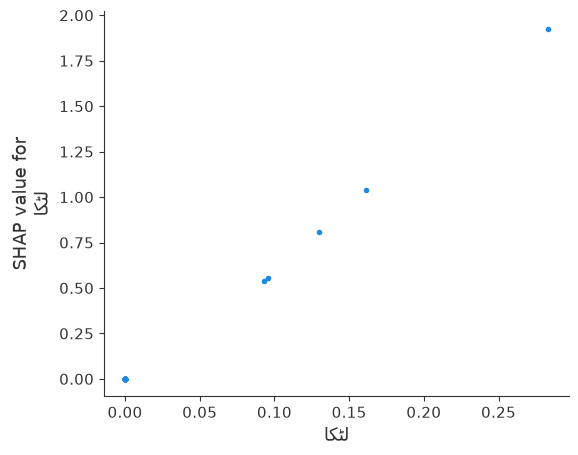


PLOT 7: DECISION PLOT - Prediction Decision Path


TypeError: decision_plot() missing 1 required positional argument: 'base_value'

<Figure size 1200x800 with 0 Axes>

In [7]:
"""
Complete RTL SHAP Plot Testing - All Plot Types
================================================
This demonstrates how users will use the shap_rtl package.
All plots are called directly with NO wrappers, NO manual RTL handling.
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ============================================================
# USER IMPORTS - DIRECT FROM PACKAGE
# ============================================================
from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import (
    waterfall,      # Single sample - shows feature contributions
    bar,            # Feature importance bar chart
    beeswarm,       # Beeswarm plot (like summary but with dots)
    summary_plot,   # Summary plot with feature importance
    heatmap,        # Heatmap across multiple samples
    scatter,        # Scatter plot for feature relationships
    decision_plot,  # Decision plot showing prediction path
    dependence_plot # Dependence plot for feature interactions
)

# ============================================================
# LOAD DATA & TRAIN MODEL
# ============================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print("=" * 80)
print("RTL SHAP PLOTS - COMPLETE DEMONSTRATION")
print("=" * 80)

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 1), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

print(f"\n✅ Model trained: {X.shape[1]} features, {len(texts)} samples")

# ============================================================
# PREPARE SAMPLES
# ============================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"
print(f"\n📝 Test Tweet: {user_tweet}")

# Get random samples
n_samples = 30
random_indices = np.random.choice(len(df), n_samples, replace=False)
sample_texts = [texts[i] for i in random_indices]
sample_texts.append(user_tweet)

all_feature_names = list(vectorizer.get_feature_names_out())

# Compute SHAP values for all samples
all_explanations = []
for text in sample_texts:
    instance_vec = vectorizer.transform([text]).toarray()[0]
    present_idx = np.where(instance_vec > 0)[0]
    
    if len(present_idx) > 0:
        masker = shap.maskers.Independent(data=X, max_samples=100)
        explainer = shap.LinearExplainer(model, masker=masker)
        shap_vals = explainer(instance_vec.reshape(1, -1))
        
        exp = shap.Explanation(
            values=shap_vals.values[0][present_idx],
            base_values=shap_vals.base_values[0],
            data=instance_vec[present_idx],
            feature_names=[all_feature_names[i] for i in present_idx]
        )
        all_explanations.append(exp)

# Combine all explanations
all_features = sorted(list(set().union(*[exp.feature_names for exp in all_explanations])))
aligned_values = []
aligned_data = []
aligned_base = []

for exp in all_explanations:
    val_map = dict(zip(exp.feature_names, exp.values))
    data_map = dict(zip(exp.feature_names, exp.data))
    aligned_values.append([val_map.get(f, 0) for f in all_features])
    aligned_data.append([data_map.get(f, 0) for f in all_features])
    aligned_base.append(exp.base_values)

combined_explanation = shap.Explanation(
    values=np.array(aligned_values),
    base_values=np.array(aligned_base),
    data=np.array(aligned_data),
    feature_names=all_features
)

print(f"\n✅ SHAP explanation ready: {combined_explanation.values.shape}")

# Get single sample for waterfall
user_instance = vectorizer.transform([user_tweet]).toarray()[0]
user_present_idx = np.where(user_instance > 0)[0]
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)
user_shap_vals = explainer(user_instance.reshape(1, -1))

user_explanation = shap.Explanation(
    values=user_shap_vals.values[0][user_present_idx],
    base_values=user_shap_vals.base_values[0],
    data=user_instance[user_present_idx],
    feature_names=[all_feature_names[i] for i in user_present_idx]
)

# ============================================================
# PLOT 1: WATERFALL PLOT (Single Sample)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 1: WATERFALL - Single Sample Feature Contributions")
print("=" * 80)

plt.figure(figsize=(12, 8))
waterfall(
    shap_values=user_explanation,
    max_display=10,
    show=True
)
plt.show()

# ============================================================
# PLOT 2: BAR PLOT (Feature Importance)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 2: BAR PLOT - Feature Importance")
print("=" * 80)

plt.figure(figsize=(12, 8))
bar(
    shap_values=combined_explanation,
    max_display=10,
    show=True
)
plt.show()

# ============================================================
# PLOT 3: BEESWARM PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 3: BEESWARM - Feature Impact Distribution")
print("=" * 80)

plt.figure(figsize=(14, 10))
beeswarm(
    shap_values=combined_explanation,
    max_display=15,
    show=True
)
plt.show()

# ============================================================
# PLOT 4: SUMMARY PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 4: SUMMARY PLOT - Feature Summary")
print("=" * 80)

plt.figure(figsize=(14, 10))
summary_plot(
    shap_values=combined_explanation,
    max_display=15,
    show=True
)
plt.show()

# ============================================================
# PLOT 5: HEATMAP (Multiple Samples)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 5: HEATMAP - Sample Feature Heatmap")
print("=" * 80)

# Heatmap needs at least 2 samples (use combined_explanation which has multiple)
plt.figure(figsize=(14, 10))
heatmap(
    shap_values=combined_explanation,
    max_display=15,
    show=True
)
plt.show()

# ============================================================
# PLOT 6: SCATTER PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 6: SCATTER PLOT - Feature Scatter")
print("=" * 80)

plt.figure(figsize=(12, 8))
scatter(
    shap_values=combined_explanation,
    max_display=10,
    show=True
)
plt.show()

# ============================================================
# PLOT 7: DECISION PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 7: DECISION PLOT - Prediction Decision Path")
print("=" * 80)

# Decision plot needs single sample with 2D data
plt.figure(figsize=(12, 8))
decision_plot(
    shap_values=user_explanation.values.reshape(1, -1),
    features=user_explanation.data,
    feature_names=user_explanation.feature_names,
    show=True
)
plt.show()

# ============================================================
# PLOT 8: DEPENDENCE PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 8: DEPENDENCE PLOT - Feature Dependence")
print("=" * 80)

# Dependence plot needs a specific feature
if len(all_features) > 0:
    top_feature = all_features[0]
    plt.figure(figsize=(12, 8))
    dependence_plot(
        shap_values=combined_explanation,
        feature_index=top_feature,
        show=True
    )
    plt.show()

# ============================================================
# PLOT 9: INTERACTIVE EXPLAINER (Full Workflow)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 9: INTERACTIVE EXPLAINER - Full Workflow")
print("=" * 80)

# Create explainer - user can choose which plot they want
urdu_explainer = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

# User can pass ANY plot function directly!
# No wrappers needed - just pass the function
print("\n📌 Users can call any plot like this:")
print("   urdu_explainer.run_full_analysis(")
print("       shap_values=combined_explanation,")
print("       prediction_label='تشدد',")
print("       plot_fn=summary_plot,  # ← Any plot function")
print("       sample_text=user_tweet")
print("   )")

# Example with summary plot
urdu_explainer.run_full_analysis(
    shap_values=combined_explanation,
    prediction_label="تشدد",
    plot_fn=summary_plot,  # ← Direct function, NO wrapper!
    sample_text=user_tweet,
    max_features=10,
    allow_positive_negative_split=True
)

print("\n" + "=" * 80)
print("✅ ALL PLOTS COMPLETE!")
print("=" * 80)

In [1]:
"""
Complete RTL SHAP Plot Testing - All Plot Types
================================================
This demonstrates how users will use the shap_rtl package.
All plots are called directly with NO wrappers, NO manual RTL handling.
"""

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ============================================================
# USER IMPORTS - DIRECT FROM PACKAGE
# ============================================================
from shap_rtl import RTLSHAPExplainer
from shap_rtl.plots import (
    waterfall,      # Single sample - shows feature contributions
    bar,            # Feature importance bar chart
    beeswarm,       # Beeswarm plot (like summary but with dots)
    summary_plot,   # Summary plot with feature importance
    heatmap,        # Heatmap across multiple samples
    scatter,        # Scatter plot for feature relationships
    decision_plot,  # Decision plot showing prediction path
    dependence_plot # Dependence plot for feature interactions
)

# ============================================================
# LOAD DATA & TRAIN MODEL
# ============================================================
file_name = r'C:\Users\USER\OneDrive - Higher Education Commission\Dr. shahid project\SHAP_package\Preprocessed_violent_views_dataset .xlsx'
df = pd.read_excel(file_name)
texts = df['cleaned_text'].astype(str).fillna('')
labels = df['label']

print("=" * 80)
print("RTL SHAP PLOTS - COMPLETE DEMONSTRATION")
print("=" * 80)

# Train model
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=1000)
X = vectorizer.fit_transform(texts).toarray()
model = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X, labels)

print(f"\n✅ Model trained: {X.shape[1]} features, {len(texts)} samples")

# ============================================================
# PREPARE SAMPLES
# ============================================================
user_tweet = "سب کافر دشمنوں کا سر تن سے جدا کر دو"
print(f"\n📝 Test Tweet: {user_tweet}")

# Get random samples
n_samples = 30
random_indices = np.random.choice(len(df), n_samples, replace=False)
sample_texts = [texts[i] for i in random_indices]
sample_texts.append(user_tweet)

all_feature_names = list(vectorizer.get_feature_names_out())

# Compute SHAP values for all samples
all_explanations = []
for text in sample_texts:
    instance_vec = vectorizer.transform([text]).toarray()[0]
    present_idx = np.where(instance_vec > 0)[0]
    
    if len(present_idx) > 0:
        masker = shap.maskers.Independent(data=X, max_samples=100)
        explainer = shap.LinearExplainer(model, masker=masker)
        shap_vals = explainer(instance_vec.reshape(1, -1))
        
        exp = shap.Explanation(
            values=shap_vals.values[0][present_idx],
            base_values=shap_vals.base_values[0],
            data=instance_vec[present_idx],
            feature_names=[all_feature_names[i] for i in present_idx]
        )
        all_explanations.append(exp)

# Combine all explanations
all_features = sorted(list(set().union(*[exp.feature_names for exp in all_explanations])))
aligned_values = []
aligned_data = []
aligned_base = []

for exp in all_explanations:
    val_map = dict(zip(exp.feature_names, exp.values))
    data_map = dict(zip(exp.feature_names, exp.data))
    aligned_values.append([val_map.get(f, 0) for f in all_features])
    aligned_data.append([data_map.get(f, 0) for f in all_features])
    aligned_base.append(exp.base_values)

combined_explanation = shap.Explanation(
    values=np.array(aligned_values),
    base_values=np.array(aligned_base),
    data=np.array(aligned_data),
    feature_names=all_features
)

print(f"\n✅ Combined explanation shape: {combined_explanation.values.shape}")

# Get single sample for waterfall and decision plots
user_instance = vectorizer.transform([user_tweet]).toarray()[0]
user_present_idx = np.where(user_instance > 0)[0]
masker = shap.maskers.Independent(data=X, max_samples=100)
explainer = shap.LinearExplainer(model, masker=masker)
user_shap_vals = explainer(user_instance.reshape(1, -1))

user_explanation = shap.Explanation(
    values=user_shap_vals.values[0][user_present_idx],
    base_values=user_shap_vals.base_values[0],
    data=user_instance[user_present_idx],
    feature_names=[all_feature_names[i] for i in user_present_idx]
)

print(f"✅ User explanation shape: {user_explanation.values.shape}")
print(f"✅ Base value: {user_explanation.base_values:.4f}")

# ============================================================
# PLOT 1: WATERFALL PLOT (Single Sample)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 1: WATERFALL - Single Sample Feature Contributions")
print("=" * 80)

plt.figure(figsize=(12, 8))
waterfall(
    shap_values=user_explanation,
    max_display=10,
    show=True
)
plt.show()

# ============================================================
# PLOT 2: BAR PLOT (Feature Importance)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 2: BAR PLOT - Feature Importance")
print("=" * 80)

plt.figure(figsize=(12, 8))
bar(
    shap_values=combined_explanation,
    max_display=10,
    show=True
)
plt.show()

# ============================================================
# PLOT 3: BEESWARM PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 3: BEESWARM - Feature Impact Distribution")
print("=" * 80)

plt.figure(figsize=(14, 10))
beeswarm(
    shap_values=combined_explanation,
    max_display=15,
    show=True
)
plt.show()

# ============================================================
# PLOT 4: SUMMARY PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 4: SUMMARY PLOT - Feature Summary")
print("=" * 80)

plt.figure(figsize=(14, 10))
summary_plot(
    shap_values=combined_explanation,
    max_display=15,
    show=True
)
plt.show()

# ============================================================
# PLOT 5: HEATMAP (Multiple Samples)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 5: HEATMAP - Sample Feature Heatmap")
print("=" * 80)

# Heatmap needs at least 2 samples (use combined_explanation which has multiple)
plt.figure(figsize=(14, 10))
heatmap(
    shap_values=combined_explanation,
    max_display=15,
    show=True,
    instance_order=None  # Avoid hclust error
)
plt.show()

# ============================================================
# PLOT 6: SCATTER PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 6: SCATTER PLOT - Feature Scatter")
print("=" * 80)

plt.figure(figsize=(12, 8))
scatter(
    shap_values=combined_explanation,
    max_display=10,
    show=True
)
plt.show()

# ============================================================
# PLOT 7: DECISION PLOT
# ============================================================
print("\n" + "=" * 80)
print("PLOT 7: DECISION PLOT - Prediction Decision Path")
print("=" * 80)

# Decision plot needs: shap_values (2D), base_value, feature_names
plt.figure(figsize=(12, 8))
decision_plot(
    base_value=user_explanation.base_values,             # Required: base value
    shap_values=user_explanation.values.reshape(1, -1),  # 2D array (1 sample x n_features)
    feature_names=user_explanation.feature_names,
    show=True
)
plt.show()

# ============================================================
# PLOT 8: DEPENDENCE PLOT (Fixed)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 8: DEPENDENCE PLOT - Feature Dependence")
print("=" * 80)

# Dependence plot shows relationship between a feature and its SHAP values
# Need to provide: shap_values, feature index, and the original data
if len(all_features) > 0:
    # Use the top feature
    top_feature_name = all_features[0]
    # Find the index of this feature in the original data
    if top_feature_name in vectorizer.get_feature_names_out():
        feature_idx = list(vectorizer.get_feature_names_out()).index(top_feature_name)
        print(f"\n📌 Using feature: '{top_feature_name}' (index: {feature_idx})")
        
        # For dependence plot, we need the original feature values
        # Use a subset of the data for the plot
        X_subset = X[:min(100, X.shape[0])]  # Take first 100 samples for speed
        
        plt.figure(figsize=(12, 8))
        dependence_plot(
            shap_values=combined_explanation,
            features=X_subset,
            show=True
        )
        plt.show()
    else:
        print(f"\n⚠️ Feature '{top_feature_name}' not found in vectorizer. Skipping dependence plot.")

# ============================================================
# PLOT 9: INTERACTIVE EXPLAINER (Full Workflow)
# ============================================================
print("\n" + "=" * 80)
print("PLOT 9: INTERACTIVE EXPLAINER - Full Workflow")
print("=" * 80)

# Create explainer - user can choose which plot they want
urdu_explainer = RTLSHAPExplainer(
    language="Urdu",
    model=model,
    vectorizer=vectorizer,
    api_type="groq"
)

# User can pass ANY plot function directly!
# No wrappers needed - just pass the function
print("\n📌 Users can call any plot like this:")
print("   urdu_explainer.run_full_analysis(")
print("       shap_values=combined_explanation,")
print("       prediction_label='تشدد',")
print("       plot_fn=summary_plot,  # ← Any plot function")
print("       sample_text=user_tweet")
print("   )")

# Example with summary plot
urdu_explainer.run_full_analysis(
    shap_values=combined_explanation,
    prediction_label="تشدد",
    plot_fn=summary_plot,  # ← Direct function, NO wrapper!
    sample_text=user_tweet,
    max_features=10,
    allow_positive_negative_split=True
)

print("\n" + "=" * 80)
print("✅ ALL PLOTS COMPLETE!")
print("=" * 80)

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'shap_rtl'

In [2]:
import shal_rtl

ModuleNotFoundError: No module named 'shal_rtl'